# 21cm Surveys

# Testing the tolerance in the plots

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the data
data_1 = np.genfromtxt("fR_exact_k_range15.csv", delimiter=',', skip_header=0)
data_2 = np.genfromtxt("fR_exact_k_range15NEW.csv", delimiter=',', skip_header=0)

# Target k value
k_val = 0.001

# 2. Create masks to find rows where column 0 (k) is close to 0.001
# Using atol=1e-5 to account for any tiny floating point rounding errors
mask_1 = np.isclose(data_1[:, 0], k_val, atol=1e-5)
mask_2 = np.isclose(data_2[:, 0], k_val, atol=1e-5)

# Apply the masks to filter the data
filtered_1 = data_1[mask_1]
filtered_2 = data_2[mask_2]

# 3. Extract the columns for the filtered data
# Column indices: 1=z, 2=density contrast, 3=growth index
z_1 = filtered_1[:, 1]
density_1 = filtered_1[:, 2]
growth_1 = filtered_1[:, 3]

z_2 = filtered_2[:, 1]
density_2 = filtered_2[:, 2]
growth_2 = filtered_2[:, 3]

/tmp/ipykernel_98326/4126141570.py:9: RuntimeWarning: invalid value encountered in divide
  rel_growth = (growth_1 - growth_2) / growth_1


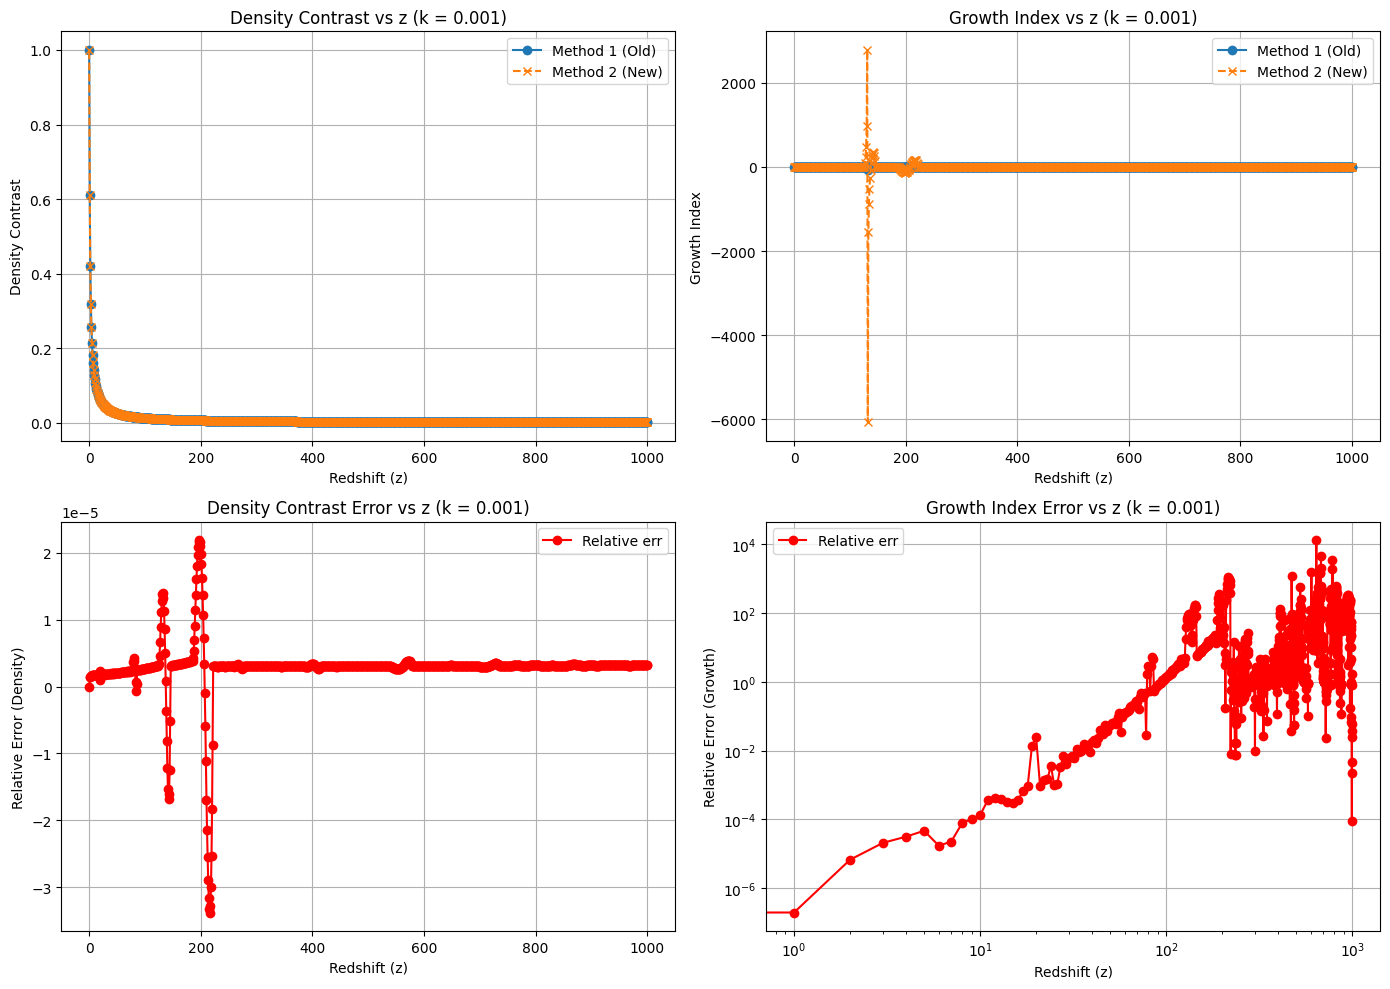

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# (Assuming data loading and filtering from the previous step is done here)

# Calculate relative errors
# Make sure z_1 and z_2 are aligned (they should be if both files have same redshifts for this k)
rel_density = (density_1 - density_2) / density_1
rel_growth = (growth_1 - growth_2) / growth_1

# 4. Plotting the comparison
# Unpack the 2x2 grid properly into 4 axes variables
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

# --- Plot 1: Density Contrast vs Redshift ---
ax1.plot(z_1, density_1, label='Method 1 (Old)', marker='o', linestyle='-')
ax1.plot(z_2, density_2, label='Method 2 (New)', marker='x', linestyle='--')
ax1.set_xlabel('Redshift (z)')
ax1.set_ylabel('Density Contrast')
ax1.set_title(f'Density Contrast vs z (k = {k_val})')
ax1.legend()
ax1.grid(True)

# --- Plot 2: Growth Index vs Redshift ---
ax2.plot(z_1, growth_1, label='Method 1 (Old)', marker='o', linestyle='-')
ax2.plot(z_2, growth_2, label='Method 2 (New)', marker='x', linestyle='--')
ax2.set_xlabel('Redshift (z)')
ax2.set_ylabel('Growth Index')
ax2.set_title(f'Growth Index vs z (k = {k_val})')
ax2.legend()
ax2.grid(True)

# --- Plot 3: Density Contrast Relative Error vs Redshift ---
ax3.plot(z_1, rel_density, label='Relative err', marker='o', color='red', linestyle='-')
ax3.set_xlabel('Redshift (z)')
ax3.set_ylabel('Relative Error (Density)')
ax3.set_title(f'Density Contrast Error vs z (k = {k_val})')
ax3.legend()
ax3.grid(True)

# --- Plot 4: Growth Index Relative Error vs Redshift ---
# FIXED: Plotted rel_growth instead of growth_1
ax4.loglog(z_1, abs(rel_growth), label='Relative err', marker='o', color='red', linestyle='-')
ax4.set_xlabel('Redshift (z)')
ax4.set_ylabel('Relative Error (Growth)')
ax4.set_title(f'Growth Index Error vs z (k = {k_val})')
ax4.legend()
ax4.grid(True)

plt.tight_layout()
plt.show()

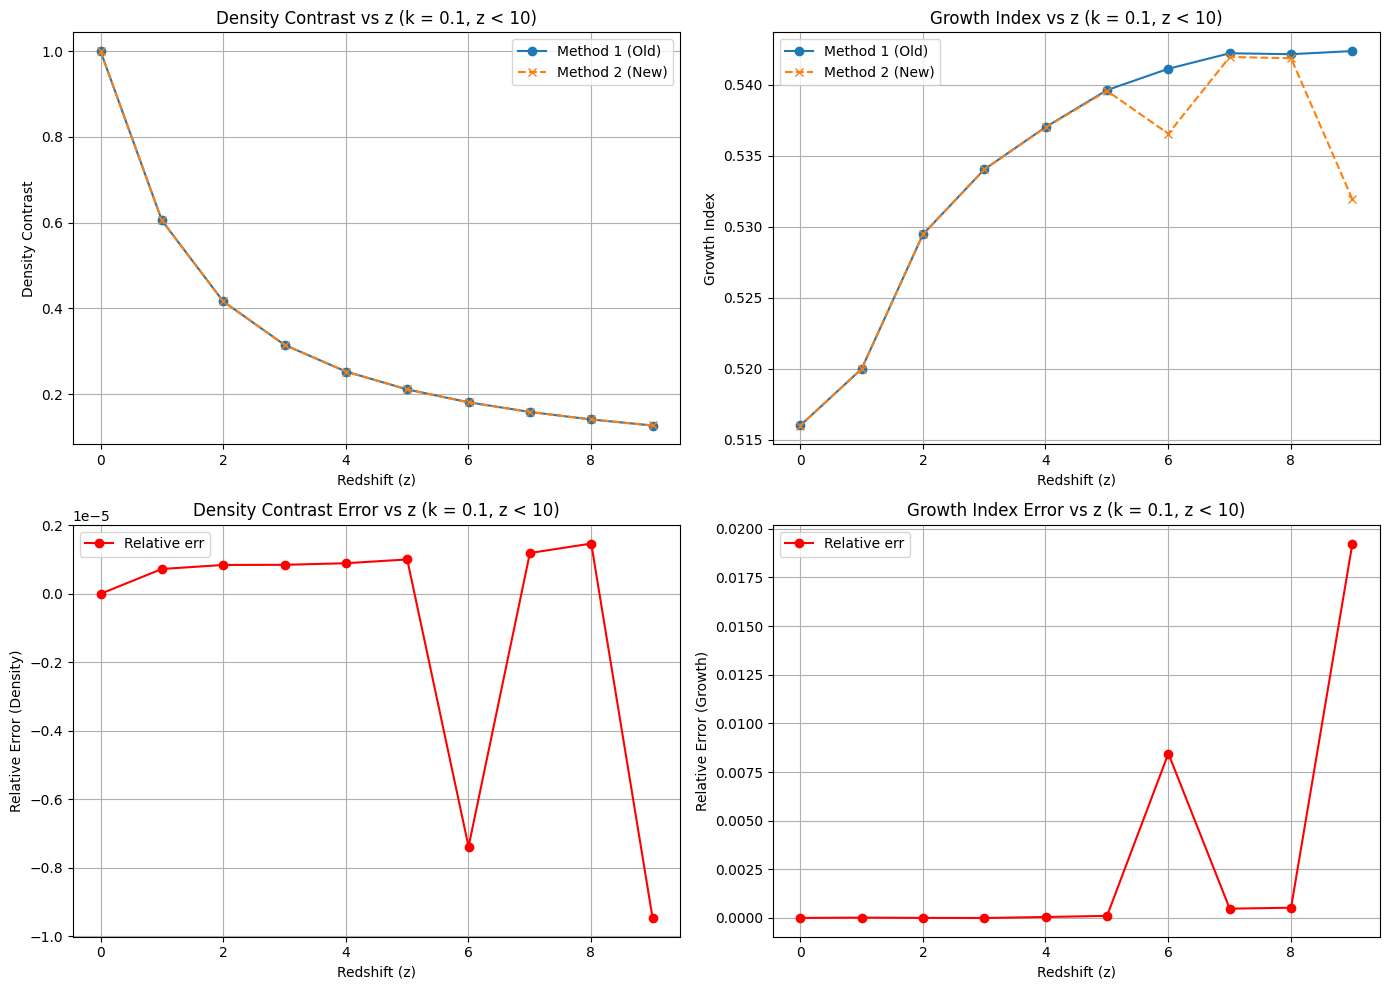

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the data
data_1 = np.genfromtxt("fR_exact_k_range15.csv", delimiter=',', skip_header=0)
data_2 = np.genfromtxt("fR_exact_k_range15NEW.csv", delimiter=',', skip_header=0)

# Target k value
k_val = 0.1

# 2. Create combined masks 
# Condition 1: Column 0 (k) is close to 0.001
# Condition 2: Column 1 (z) is less than 10
# Note the parentheses around each condition!
mask_1 = (np.isclose(data_1[:, 0], k_val, atol=1e-5)) & (data_1[:, 1] < 10)
mask_2 = (np.isclose(data_2[:, 0], k_val, atol=1e-5)) & (data_2[:, 1] < 10)

# Apply the masks to filter the data
filtered_1 = data_1[mask_1]
filtered_2 = data_2[mask_2]

# 3. Extract the columns for the filtered data
z_1 = filtered_1[:, 1]
density_1 = filtered_1[:, 2]
growth_1 = filtered_1[:, 3]

z_2 = filtered_2[:, 1]
density_2 = filtered_2[:, 2]
growth_2 = filtered_2[:, 3]

# Calculate relative errors
rel_density = (density_1 - density_2) / density_1
rel_growth = (growth_1 - growth_2) / growth_1

# 4. Plotting the comparison
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

# --- Plot 1: Density Contrast vs Redshift ---
ax1.plot(z_1, density_1, label='Method 1 (Old)', marker='o', linestyle='-')
ax1.plot(z_2, density_2, label='Method 2 (New)', marker='x', linestyle='--')
ax1.set_xlabel('Redshift (z)')
ax1.set_ylabel('Density Contrast')
ax1.set_title(f'Density Contrast vs z (k = {k_val}, z < 10)')
ax1.legend()
ax1.grid(True)

# --- Plot 2: Growth Index vs Redshift ---
ax2.plot(z_1, growth_1, label='Method 1 (Old)', marker='o', linestyle='-')
ax2.plot(z_2, growth_2, label='Method 2 (New)', marker='x', linestyle='--')
ax2.set_xlabel('Redshift (z)')
ax2.set_ylabel('Growth Index')
ax2.set_title(f'Growth Index vs z (k = {k_val}, z < 10)')
ax2.legend()
ax2.grid(True)

# --- Plot 3: Density Contrast Relative Error vs Redshift ---
ax3.plot(z_1, rel_density, label='Relative err', marker='o', color='red', linestyle='-')
ax3.set_xlabel('Redshift (z)')
ax3.set_ylabel('Relative Error (Density)')
ax3.set_title(f'Density Contrast Error vs z (k = {k_val}, z < 10)')
ax3.legend()
ax3.grid(True)

# --- Plot 4: Growth Index Relative Error vs Redshift ---
ax4.plot(z_1, rel_growth, label='Relative err', marker='o', color='red', linestyle='-')
ax4.set_xlabel('Redshift (z)')
ax4.set_ylabel('Relative Error (Growth)')
ax4.set_title(f'Growth Index Error vs z (k = {k_val}, z < 10)')
ax4.legend()
ax4.grid(True)

plt.tight_layout()
plt.show()

In [1]:
Telescope = {
    "HIRAX": {
        "Redshift_range": (0.775, 2.55),
        "Integration_time": 157680000,
        "Sky_fraction": 0.36,
        "Dish_diameter": 6,
        "Maximum_baseline": 0.25,
        "N_dish": 1024
    },
    "PUMA": {
        "Redshift_range": (0.3, 6.0),
        "Integration_time": 157680000,
        "Sky_fraction": 0.5,
        "Dish_diameter": 6,
        "Maximum_baseline": 1.0,
        "N_dish": 32000
    },
    "SKA_MID": {
        "Redshift_range": (0.35, 3.05),
        "Integration_time": 157680000,
        "Sky_fraction": 0.49,
        "Dish_diameter": 15,
        "Maximum_baseline": 150,
        "N_dish": 197
    }
}

print(Telescope["HIRAX"])
z_min_hirax = Telescope["HIRAX"]["Redshift_range"][0]
z_max_hirax = Telescope["HIRAX"]["Redshift_range"][1]
print(z_max_hirax)

{'Redshift_range': (0.775, 2.55), 'Integration_time': 157680000, 'Sky_fraction': 0.36, 'Dish_diameter': 6, 'Maximum_baseline': 0.25, 'N_dish': 1024}
2.55


# Noise power spectrum

[4.10174708e+01 5.72917617e+01 1.29704701e+02 4.75947996e+02
 2.83076312e+03 2.72890111e+04 4.26395202e+05 1.07988389e+07
 4.43284003e+08 2.94935668e+10 3.18062727e+12 5.55953542e+14
 1.57508671e+17 7.23287028e+19 5.38340591e+22 6.49447157e+25
 1.26990360e+29 4.02474096e+32 2.06749922e+36 1.72144447e+40]


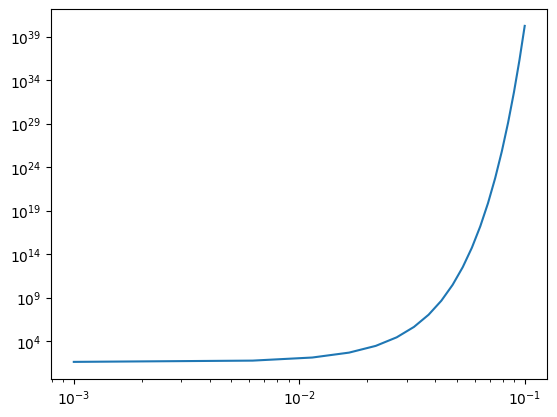

In [2]:
''' Think about f_factor = self.S_area / self.FOV(lambda_obs)'''
import numpy as np
from scipy import integrate
from astropy.cosmology import Planck18 as cosmo


class noise(object):
    
    def __init__(self,survey):
        self.survey = survey
        # grabbing total integration time in h and transform to s
        self.t_int = Telescope[self.survey]["Integration_time"]
        # coverage of sky
        self.f_sky = Telescope[self.survey]["Sky_fraction"]
        # physical dish area
        self.D_phys = Telescope[self.survey]["Dish_diameter"]
        # square root of effective dish area
        self.D_eff = np.sqrt(0.7) * self.D_phys # in meters
        # total survey area
        self.S_area = 4.0 * np.pi * self.f_sky # sq. radians
        # effective collecting area per antenna feed
        self.A_e = np.pi * (self.D_eff / 2.)**2
        # number of receivers
        self.N_s = np.sqrt(Telescope[self.survey]["N_dish"])
        self.c_kms = 2.99979e5

    def T_sky(self, nu):
        """
            Returns the sky temperature in Kelvins. The input should be in Megahertz and the output is in mili Kelvins.
        """
        return pow((nu / 400.), -2.75) * 25. + 2.7
        
    def T_sys(self, nu):
        """
            Returns the system temperature for Survey. The input should be in MHz and the output is in mili Kelvins.
        """
        if(self.survey == 'SKA_MID'):

            def T_rx(nu_obs):

                return 15+30*(nu_obs/1000 -0.75)**2
    
            def T_gal(nu_obs):
        
                return 25*(408/nu_obs)**2.75
    
            # Define system temperature
            T_spl = 3
            T_CMB = 2.73
            T_sym = T_rx(nu)+T_spl+T_CMB+T_gal(nu)
            return T_sym*1000 # mili Kalvin

        elif(self.survey =='HIRAX'):
            T_rx = 50
            return (T_rx + self.T_sky(nu)) * 1000.

        elif(self.survey =='PUMA'):
            T_ampl = 50 # in Kelvins
            # ground temperature
            T_ground = 300 # in Kelvins
            # coupling to vacuum
            eta_c = 0.9 
            # coupling to sky
            eta_s = 0.9 
            
            ampl = T_ampl / eta_c / eta_s
            ground = (1. - eta_s) * T_ground / eta_s
            return (ampl + ground + self.T_sky(nu)) * 1000.
        else:
            raise ValueError(f"Survey '{self.survey}' is not included in this study.")
    
    def FOV(self, lambda_obs):
        """
            Returns the effective field of view
        """
        return pow((lambda_obs / self.D_eff), 2.)
        
    def n_b_phys(self, ell):
        """
            Returns  physical number of baselines as a function of physical distance of antennas
        """
        n_0 = (self.N_s / self.D_phys)**2
        L = self.N_s * self.D_phys
        if(self.survey == 'PUMA'):
            ''' For PUMA hex close packing '''
            a = 0.5698 # sq 0.4847
            b = -0.5274 #sq -0.3300
            c = 0.8358 # sq 1.3157
            d = 1.6635 # sq 1.5974
            e = 7.3177 # sq 6.8390
            ''' For PUMA N_s^2 = 2*N_d From paper 2409.19383 ''' 
            n_0 = (np.sqrt(2)*self.N_s / self.D_phys)**2
            L = np.sqrt(2)*self.N_s * self.D_phys

        elif(self.survey == 'HIRAX'):
            ''' For HIRAX square packing''' # taking from https://arxiv.org/pdf/2206.07747
            a = 0.4847 #0.5698 # sq 0.4847
            b = -0.3300 #-0.5274 #sq -0.3300
            c = 1.3157 #0.8358 # sq 1.3157
            d = 1.5974 #1.6635 # sq 1.5974
            e = 6.8390 #7.3177 # sq 6.8390
        
        l_fac = ell / L
        mid_fac = (a + b * l_fac) / (1. + c * pow(l_fac, d))
        return n_0 * mid_fac * np.exp(-1. * pow(l_fac, e))



    
    def number_density(self, u, lambda_obs):
        """
        Returns number density of baselines in the uv plane.
        """
        # If lambda_obs is a scalar, use it directly
        if np.isscalar(lambda_obs):
            lambda_obs_expanded = np.full_like(u, lambda_obs)  # Expand lambda_obs to match u's length
        else:
            lambda_obs_expanded = np.repeat(lambda_obs, u.shape[0] // lambda_obs.shape[0])
            if u.shape[0] % lambda_obs.shape[0] != 0:
                # If u's length isn't a multiple of lambda_obs's length, handle the remainder
                lambda_obs_expanded = np.concatenate([lambda_obs_expanded, lambda_obs[:u.shape[0] % lambda_obs.shape[0]]])

        ell = u * lambda_obs_expanded
        return self.n_b_phys(ell) * lambda_obs_expanded**2



    def normalize(self, lambda_obs):
        """
        Compute the normalization of our number density of baselines
    
        Note that this function is now being called in the power spectrum computation.
    
        Also, note that it no longer uses the defined N_s attribute and instead is defined inside the function.
        """
        u = np.linspace(0, 5000, 1000)
        # n_sq = self.square_uni_density(u, lambda_obs, 256*256)
        n = self.number_density(u, lambda_obs)

        # Define the integrand for integration
        def integrand(u):
            return 2. * np.pi * u * self.number_density(u, lambda_obs)

        # Perform integration using scipy.integrate.quad
        norm, error = integrate.quad(integrand, 0, 5000)
        if(self.survey == 'HIRAX'):
            
            # Proper normalization factor
            proper = 0.5 * (self.N_s)**2 * ((self.N_s)**2 - 1)
        elif(self.survey == 'PUMA'):
            # Proper normalization factor
            proper = 0.5 * (np.sqrt(2)*self.N_s)**2 * ((np.sqrt(2)*self.N_s)**2 - 1)
            
        return proper / norm

    
    # Define theta_b
    def theta_b(self,z):
        Dd = self.D_phys  # In meter units
        return 1.22*(1 + z) * 0.21 / Dd  # 21cm wavelength in meter

    # The transverse effective beam is given as
    def invbeta(self,k,mu,z):
        # First define the k perpendicular 
        k_per = k*np.sqrt(1.0-mu**2)
        return np.exp(k_per**2*(cosmo.comoving_distance(z).value)**2*(self.theta_b(z))**2/16.0/np.log(2))

    def noise_power_Mpc(self, z, k_Mpc, mu):
        """
            Returns the noise power spectrum in mK^2 Mpc^3.
            
            The inputs are redshift, wavenumber in 1/Mpc and the angle between the line of sigth mu
        """
        if(self.survey =='HIRAX' or self.survey =='PUMA'):
            
            lambda_obs = 0.21 * (1. + z) # note that this is in meters
            nu_obs = 1420 / (1. + z) # in MHz, I got lazy so defined both hehe
            # comoving distance in Mpc
            D_c_Mpc = cosmo.comoving_distance(z).value                                                # self.lya_c.comoving_dist(z)
            # hubble parameter in km/s/Mpc
            H_kms_Mpc = cosmo.H(z).value                                                              # self.lya_c.hubble(z)
            # angular resolution factor
            ang_factor = lambda_obs**2 / self.A_e # [sq. m] / [sq. m] = dimensionless
            # FOV factor
            # f_factor = self.S_area / self.FOV(lambda_obs) # dimensionless
            f_factor = self.S_area / self.theta_b(z)**2
            # first get the right k perp
            kt_Mpc = k_Mpc * np.sqrt(1. - mu**2)
            u = kt_Mpc * D_c_Mpc / (2. * np.pi)
            # the number density is
            n_u = self.number_density(u, lambda_obs)
            # and we normalize it to have 32000 array elements
            n_u *= self.normalize(lambda_obs)
            den_factor = 2. * self.t_int * n_u # [s]
            # construct noise, note that I transform a lambda obs to km due to hubble's units
            # and I transform K into mK too
            P_N = (self.T_sys(nu_obs))**2 * D_c_Mpc**2 * (lambda_obs / 1000.) * (1. + z) / H_kms_Mpc * ang_factor**2 / den_factor * f_factor
            return P_N
            
        
        elif (self.survey =='SKA_MID'):
            Exp_overflow_val =10e+108
            lambda_obs = 0.21 * (1. + z) # note that this is in meters
            nu_obs = 1420 / (1. + z) # in MHz,
            # comoving distance in Mpc
            D_c_Mpc = cosmo.comoving_distance(z).value                                                # self.lya_c.comoving_dist(z)
            # hubble parameter in km/s/Mpc
            H_kms_Mpc = cosmo.H(z).value                                                              # self.lya_c.hubble(z)

            invbeta2 = (self.invbeta(k_Mpc,mu,z))**2
            invbeta2 = np.where(invbeta2 < Exp_overflow_val, invbeta2, Exp_overflow_val)
            # and I transform K into mK too T_sys(self,nu_obs)
            P_N = (self.T_sys(nu_obs))**2 * D_c_Mpc**2 * (lambda_obs / 1000.) * (1. + z) / H_kms_Mpc*self.S_area/(1*2*self.N_s**2*self.t_int)*invbeta2
        
            return P_N
        else:
            print("Kindly write correct name of Survey")

z=2
k = 0.25
mu = 1.0/np.sqrt(3)
SKA_MID = "SKA_MID"  # Define the variable
k = np.linspace(0.001,0.10,20)
# Create the noise instance
cal = noise(SKA_MID)
print(cal.noise_power_Mpc(z,k,mu))
import matplotlib.pyplot as plt
plt.loglog(k,cal.noise_power_Mpc(z,k,mu))

# Power spectrum And Fisher matrix

# $x_{init} = -10^{-14}$

In [5]:
import math
import numpy as np
from astropy.cosmology import Planck18 as cosmo
from scipy import interpolate
from scipy import integrate
import matplotlib.pyplot as plt
import pandas as pd
import scipy.linalg
import sys
from math import floor
import camb
from scipy.interpolate import interp1d

# growth index
def gamma_interpolator(k,z):
    data_D = np.loadtxt("data_full_QS_14.dat")
    # k_value  z_plot  Normalized_Delta  Gamma
    points = np.column_stack((data_D[:,0], data_D[:,1]))
    interpole_gama = interpolate.LinearNDInterpolator(points,data_D[:,3])
    return interpole_gama(k,z)

filename="Pk_z0.dat"
data = np.loadtxt(filename)
k_values = data[:,0]
Power_spectra = data[:,1]
P_interp = interp1d(k_values, Power_spectra,kind='cubic',fill_value='extrapolate')

print(f"Power spectrum loaded: k from {k_values[0]:.3e} to {k_values[-1]:.3e} Mpc^-1")
print(f"Points: {len(k_values)}")
    
class Power_HI:
    def __init__(self, k, mu, z,survey):
        self.k = k
        self.mu = mu
        self.z = z
        self.h = 0.6766
        self.Obh2 = 0.02242
        self.Och2 = 0.11933
        self.OMh2 = self.Obh2 + self.Och2
        # self.gamma_value = gamma_interpolator(self.k, self.z)
        self.survey = survey
        # self.pk()

    def OHI(self, z):
        return 4e-4*(1+z)**0.6
    
    def bHI(self, z):
        #return 1.333 + 0.1809*z + 0.05302*z**2 - 0.0008822*z**3
        return 0.754 + 0.0877*z + 0.0607*z**2 - 0.00274*z**3

    def Tb_mean(self):
        '''
        output in units of mK
        '''
        return 188.0*self.OHI(self.z)*self.h*(1+self.z)**2*cosmo.H(0).value/cosmo.H(self.z).value

    def P_matter(self, z=0):
        """
        Calculate matter power spectrum for stored k values and given z (default z=0).
        Returns: P(k,z) in Mpc^3
        """
        return P_interp(self.k)

    def f(self):
        OM = (self.Obh2 + self.Och2) / self.h**2
        return (OM * (1+self.z)**3 / (OM * (1+self.z)**3 + 1 - OM))**gamma_interpolator(self.k,self.z)

    def FoG(self):
        SigmaP = 350
        return np.exp(-self.k**2*self.mu**2*SigmaP**2/cosmo.H(self.z).value**2)

    def growth(self, k, z):
        data_D = np.loadtxt("data_full_QS_14.dat")

        points = np.column_stack((data_D[:,0], data_D[:,1]))
        growth_D = interpolate.LinearNDInterpolator(points,data_D[:,2])
        # k_value  z_plot  Normalized_Delta  Gamma
        return growth_D(k,z)

    def P_HI(self):
        beta_val = self.f()/self.bHI(self.z)
        # print("Print beta ",beta_val)
        ''' MAKE SURE THE SQUARE OF GROWTH......'''
        Powe = self.Tb_mean()**2 * self.FoG() * (1 + self.mu**2*beta_val)**2*self.bHI(self.z)**2*self.growth(self.k, self.z)**2*self.P_matter()
        # print("Power spectrum of 21cm signal", Powe)
        return Powe

    def PN(self):
        Noise = noise(self.survey)
        PN = Noise.noise_power_Mpc(self.z, self.k, self.mu)
        return PN

    def P_tot(self):
        P_fid = self.P_HI() + self.PN()
        power_noi = self.PN()
        # print("Noise power spectrum of HIRAX for 5 years:", power_noi)
        return P_fid

class Fisher:
    def __init__(self, k, z, dz, kmax, kfg, survey):
        self.k = k
        self.z = z
        self.dz = dz
        self.kmax = kmax
        self.h = 0.6766
        self.Obh2 = 0.02242
        self.Och2 = 0.11933
        self.kfg = kfg
        self.OM = (self.Obh2 + self.Och2) / self.h**2
        self.survey = survey
        self.kfg = kfg
    

    def V(self, z):
        f_sky = Telescope[self.survey]["Sky_fraction"]
        A = 4 * np.pi * f_sky
        v = A / 3 * ((cosmo.comoving_distance(z+self.dz/2).value)**3 - (cosmo.comoving_distance(z-self.dz/2).value)**3)
        return v

    def OM_m(self):
        OM = (self.Obh2 + self.Och2) / self.h**2
        return (OM * (1+self.z)**3 / (OM * (1+self.z)**3 + 1 - OM))

    def alpha(self, z):
        Dd = Telescope[self.survey]["Dish_diameter"]
        return np.arctan(cosmo.H(z).value * cosmo.comoving_distance(z).value * np.sin(0.61 * self.theta_b(z)) / (3e+5 * (1 + z)))

    def theta_b(self, z):
        Dd = Telescope[self.survey]["Dish_diameter"]
        return (1 + z) * 0.21 / Dd  # 0.21 meter wavelength

    def dP_dfi(self,k, mu, z, param):
        bias = Power_HI(k, mu, z, self.survey).bHI(z)
        matter_power = Power_HI(k, mu, z, self.survey).P_matter()
        f_kz = self.OM_m()**gamma_interpolator(k,z) # gamma_interpolator(k_test, z_test)
        beta_val = f_kz/bias
        
        ''' Change this'''
        if param == "gamma":
            # beta_val = self.f()/self.bHI(self.z)
            # f_kz = self.OM_m()**gamma_interpolator(k,z) # gamma_interpolator(k_test, z_test)
            # P_m = Power_HI(k, mu, z, self.survey).P_HI()
            # bias = Power_HI(k, mu, z, self.survey).bHI(z)
            # dP_df = 2*P_m*(bias + mu**2*f_kz)*mu**2*f_kz*np.log(self.OM_m())
            dP_df = 2*(1.0 + mu**2*beta_val)*matter_power*bias*mu**2*f_kz*np.log(self.OM_m())
            return dP_df

        elif param == "beta_par":
            dP_df = 2*(1.0 + mu**2*beta_val)*mu**2*bias**2*matter_power
            return dP_df

        else:
            print("Enter correct NAME")
            
    '''factor 2 from mu integration'''
    def inter(self, k, mu, z, param1, param2):
        integ_val = 2*self.V(z)/(8*np.pi**2)*k**2*self.dP_dfi(k, mu, z, param1)*self.dP_dfi(k, mu, z, param2)/(Power_HI(k, mu, z,self.survey).P_tot())**2
        return integ_val

    # Fisher matrix code
    def fisher_quad(self,param1, param2):
        n_bins = 50

        # print("Fundamental k ",2 * np.pi / (self.V(self.z))**(1/3))
        # For Interference
        if self.survey == "HIRAX" or self.survey == "PUMA":
        
            
            mu_min, mu_max = np.sin(self.alpha(self.z)), 1.0
            k_f = 2 * np.pi / (self.V(self.z))**(1/3)
            k_fg = self.kfg * self.h
            # print("Print",k_f)
            # k_min = lambda mu: np.where(k_f > k_fg, k_f / np.abs(mu), k_fg / np.abs(mu))
            k_min = lambda mu: np.maximum(np.array(k_f)/np.abs(mu) , np.array(k_fg)/np.abs(mu))
            
            k_max = self.kmax

        # For Single Dish
        elif self.survey == "SKA_MID":
        
            
            mu_min, mu_max = 0.0 , 1.0
            k_f = 2 * np.pi / (self.V(self.z))**(1/3)
            k_fg = self.kfg * self.h
            # k_min = lambda mu: np.where(k_f > k_fg, k_f / np.abs(mu), k_fg / np.abs(mu))
            # k_min = lambda mu: np.maximum(np.array(k_f)/np.abs(mu) , np.array(k_fg)/np.abs(mu))
            k_min = lambda mu: np.maximum(np.array(k_f) , np.array(k_fg))/np.abs(mu)
            
            k_max = self.kmax
        else:
            print("Enter correct name")

        mu_bins = np.linspace(mu_min, mu_max, n_bins)
        dmu = mu_bins[1] - mu_bins[0]
        mu_midpoints = (mu_bins[:-1] + mu_bins[1:]) * 0.5
        sum_result = 0

        k_low_vals = k_min(mu_midpoints)
        dk_vals = (k_max - k_low_vals) / (n_bins - 1)

        # 2. Evaluate the integrand for all mu_midpoints at once
        integrand_vals = self.inter(self.k, mu_midpoints, self.z, param1, param2)

        # 3. Multiply and sum over the mu axis
        # We sum over the axis corresponding to mu (adjust axis=0 or axis=-1 depending on 
        # the exact shape self.inter returns when given self.k and mu arrays).
        sum_result += np.sum(integrand_vals * dk_vals * dmu, axis=0)
        return sum_result


def Sigma_g2m(k,z, dz, k_max,kfg, survey):
    F_ij_1= Fisher(k,z, dz, k_max, kfg, survey).fisher_quad("gamma","gamma")
    F_ij_2 = Fisher(k,z, dz, k_max, kfg, survey).fisher_quad("beta_par","beta_par")
    return F_ij_1**(-1/2),F_ij_2**(-1/2)

# Define All the form of f(k)
def fun(k,q):
    kg = 0.05
    return (k/kg)**q
# Calling the function....
z = 1
dz = 0.1
k_val = 0.01

h = 0.6766
ns = 0.9665
k_max = 0.1 * (1 + z)**(2. / (2 + ns)) * h
print("k_max possible:", k_max)
kmax = np.linspace(0.10, k_max, 8)

quadrup = []

# fisher = Fisher(0.1*h,z, dz, k_max, 0.01, "HIRAX")
# print("Survey volume", fisher.V(z))
# fish = fisher.fisher_quad()
# quadrup.append(fish)
# print("Fisher matrix for HIRAX with kfg=0.00 :", fish)
print("printing the sigma using above function",Sigma_g2m(k_val,z, dz, k_max, 0, "HIRAX"))

Power spectrum loaded: k from 1.000e-04 to 1.000e+03 Mpc^-1
Points: 5000
k_max possible: 0.1079654913116559
printing the sigma using above function (np.float64(0.0102972949261774), np.float64(0.0024616852140649783))


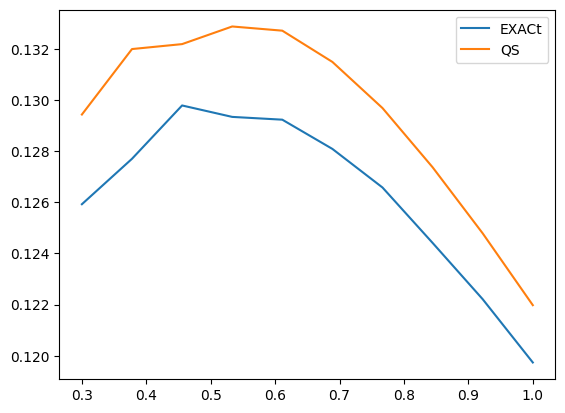

In [25]:
def gamma_interpolator_QS(k,z):
    data_D = np.loadtxt("data_full_QS_14.dat")
    # k_value  z_plot  Normalized_Delta  Gamma
    points = np.column_stack((data_D[:,0], data_D[:,1]))
    interpole_gama = interpolate.LinearNDInterpolator(points,data_D[:,3])
    return interpole_gama(k,z)

def gamma_interpolator_exact(k,z):
    data_D = np.loadtxt("fR_exact_k_range14_filter.dat")
    # k_value  z_plot  Normalized_Delta  Gamma
    points = np.column_stack((data_D[:,0], data_D[:,1]))
    interpole_gama = interpolate.LinearNDInterpolator(points,data_D[:,3])
    return interpole_gama(k,z)

k_testing = 0.05
z_testing = np.linspace(0.3,1,10)
gamma_exact = gamma_interpolator_exact(k_testing,z_testing)
gamma_QS = gamma_interpolator_QS(k_testing,z_testing)

relative_exact = abs(gamma_exact-0.55)/0.55
relative_QS = abs(gamma_QS-0.55)/0.55

plt.plot(z_testing,relative_exact,label = "EXACt")
plt.plot(z_testing,relative_QS,label = "QS")
plt.legend()

In [6]:
k_values = np.logspace(-3,-1,100)
z_val = 1
mu_val = 0
survey = "HIRAX"
pow_21_z_1 = Power_HI(k_values, mu_val, 1, survey).P_HI()
pow_21_z_2 = Power_HI(k_values, mu_val, 0.5, survey).P_HI()
np.savetxt("power_21_modi_z_1.dat",np.column_stack((k_values, pow_21_z_1)))
np.savetxt("power_21_modi_z_0_5.dat",np.column_stack((k_values, pow_21_z_2)))

# as a funtion of redshifts

# cumulative Error QS

# K = 0.01

In [6]:
import numpy as np

import numpy as np
k_vals = 0.01
kfg = 0
def run_cumulative(survey):

    z_min = Telescope[survey]["Redshift_range"][0]
    z_max = 1
    z_val = np.arange(z_min, z_max + dz, dz)

    F_cum = 0.0   # cumulative Fisher
    results = []

    for z_i in z_val:

        k_max = 0.1 * (1 + z_i)**(2. / (2 + ns)) * h

        F_gg = Fisher(k_vals, z_i, dz, k_max, kfg, survey)\
               .fisher_quad("gamma", "gamma")

        F_cum += F_gg

        sigma_gamma = 1.0 / np.sqrt(F_cum)

        gamma_val = gamma_interpolator(k_vals, z_i)

        results.append([z_i, gamma_val, sigma_gamma])

    return np.array(results)

# Run for all surveys
for survey in ["PUMA", "SKA_MID"]:

    results = run_cumulative(survey)

    # results = [z, gamma, sigma_gamma]
    z_vals = results[:,0]
    gamma_vals = results[:,1]
    sigma_vals = results[:,2]

    filename = f"cumulative_{survey}_.01.dat"

    np.savetxt(
        filename,
        np.column_stack((z_vals, gamma_vals, sigma_vals)),
        header="z  gamma  sigma_gamma"
    )

    print(f"Saved: {filename}")

Saved: cumulative_PUMA_.01.dat
Saved: cumulative_SKA_MID_.01.dat


In [7]:
import numpy as np

import numpy as np
k_vals = 0.05
def run_cumulative(survey):

    z_min = Telescope[survey]["Redshift_range"][0]
    z_max = 1
    z_val = np.arange(z_min, z_max + dz, dz)

    F_cum = 0.0   # cumulative Fisher
    results = []

    for z_i in z_val:

        k_max = 0.1 * (1 + z_i)**(2. / (2 + ns)) * h

        F_gg = Fisher(k_vals, z_i, dz, k_max, kfg, survey)\
               .fisher_quad("gamma", "gamma")

        F_cum += F_gg

        sigma_gamma = 1.0 / np.sqrt(F_cum)

        gamma_val = gamma_interpolator(k_vals, z_i)

        results.append([z_i, gamma_val, sigma_gamma])

    return np.array(results)

# Run for all surveys
for survey in ["PUMA", "SKA_MID"]:

    results = run_cumulative(survey)

    # results = [z, gamma, sigma_gamma]
    z_vals = results[:,0]
    gamma_vals = results[:,1]
    sigma_vals = results[:,2]

    filename = f"cumulative_{survey}.dat"

    np.savetxt(
        filename,
        np.column_stack((z_vals, gamma_vals, sigma_vals)),
        header="z  gamma  sigma_gamma"
    )

    print(f"Saved: {filename}")

Saved: cumulative_PUMA.dat
Saved: cumulative_SKA_MID.dat


# k = 0.1

In [8]:
import numpy as np

import numpy as np
k_vals = 0.1
def run_cumulative(survey):

    z_min = Telescope[survey]["Redshift_range"][0]
    z_max = 1
    z_val = np.arange(z_min, z_max + dz, dz)

    F_cum = 0.0   # cumulative Fisher
    results = []

    for z_i in z_val:

        k_max = 0.1 * (1 + z_i)**(2. / (2 + ns)) * h

        F_gg = Fisher(k_vals, z_i, dz, k_max, kfg, survey)\
               .fisher_quad("gamma", "gamma")

        F_cum += F_gg

        sigma_gamma = 1.0 / np.sqrt(F_cum)

        gamma_val = gamma_interpolator(k_vals, z_i)

        results.append([z_i, gamma_val, sigma_gamma])

    return np.array(results)

# Run for all surveys
for survey in ["PUMA", "SKA_MID"]:

    results = run_cumulative(survey)

    # results = [z, gamma, sigma_gamma]
    z_vals = results[:,0]
    gamma_vals = results[:,1]
    sigma_vals = results[:,2]

    filename = f"cumulative_{survey}_0.1.dat"

    np.savetxt(
        filename,
        np.column_stack((z_vals, gamma_vals, sigma_vals)),
        header="z  gamma  sigma_gamma"
    )

    print(f"Saved: {filename}")

Saved: cumulative_PUMA_0.1.dat
Saved: cumulative_SKA_MID_0.1.dat


# For beta

In [37]:
0.1 * (1 + 0.3)**(2. / (2 + 0.965)) * 0.6766

0.08075899685840546

In [9]:
h = 0.6766
ns = 0.9665
Obh2 = 0.02242
Och2 = 0.11933
def OM_m(z):
    OM = (Obh2 + Och2) / h**2
    return (OM * (1+z)**3 / (OM * (1+z)**3 + 1 - OM))

In [10]:
import numpy as np

k_vals = 0.01

def run_cumulative_beta(survey):

    z_min = Telescope[survey]["Redshift_range"][0]
    z_max = 1

    # Robust z grid (no overshoot + includes z=1)
    z_val = np.arange(z_min, z_max, dz)
    z_val = np.append(z_val, z_max)

    F_cum = 0.0
    results = []

    for z_i in z_val:

        k_max = 0.1 * (1 + z_i)**(2. / (2 + ns)) * h

        # Fisher for beta
        F_bb = Fisher(k_vals, z_i, dz, k_max, kfg, survey)\
               .fisher_quad("beta_par", "beta_par")

        F_cum += F_bb

        sigma_beta = 1.0 / np.sqrt(F_cum)

        # Fiducial beta
        gamma_val = gamma_interpolator(k_vals, z_i)
        bias = Power_HI(k_vals, 0, z_i, survey).bHI(z_i)

        f_kz = OM_m(z_i)**gamma_val
        beta_val = f_kz / bias

        results.append([z_i, beta_val, sigma_beta])

    return np.array(results)

for survey in ["PUMA", "SKA_MID"]:

    results = run_cumulative_beta(survey)

    z_vals     = results[:,0]
    beta_vals  = results[:,1]
    sigma_vals = results[:,2]

    filename = f"cumulative_{survey}_beta_0_01.dat"

    np.savetxt(
        filename,
        np.column_stack((z_vals, beta_vals, sigma_vals)),
        header="z  beta  sigma_beta"
    )
    print(f"Saved: {filename}")

Saved: cumulative_PUMA_beta_0_01.dat
Saved: cumulative_SKA_MID_beta_0_01.dat


In [11]:
import numpy as np

k_vals = 0.1

def run_cumulative_beta(survey):

    z_min = Telescope[survey]["Redshift_range"][0]
    z_max = 1

    # Robust z grid (no overshoot + includes z=1)
    z_val = np.arange(z_min, z_max, dz)
    z_val = np.append(z_val, z_max)

    F_cum = 0.0
    results = []

    for z_i in z_val:

        k_max = 0.1 * (1 + z_i)**(2. / (2 + ns)) * h

        # Fisher for beta
        F_bb = Fisher(k_vals, z_i, dz, k_max, kfg, survey)\
               .fisher_quad("beta_par", "beta_par")

        F_cum += F_bb

        sigma_beta = 1.0 / np.sqrt(F_cum)

        # Fiducial beta
        gamma_val = gamma_interpolator(k_vals, z_i)
        bias = Power_HI(k_vals, 0, z_i, survey).bHI(z_i)

        f_kz = OM_m(z_i)**gamma_val
        beta_val = f_kz / bias

        results.append([z_i, beta_val, sigma_beta])

    return np.array(results)

for survey in ["PUMA", "SKA_MID"]:

    results = run_cumulative_beta(survey)

    z_vals     = results[:,0]
    beta_vals  = results[:,1]
    sigma_vals = results[:,2]

    filename = f"cumulative_{survey}_beta_0_1.dat"

    np.savetxt(
        filename,
        np.column_stack((z_vals, beta_vals, sigma_vals)),
        header="z  beta  sigma_beta"
    )
    print(f"Saved: {filename}")

Saved: cumulative_PUMA_beta_0_1.dat
Saved: cumulative_SKA_MID_beta_0_1.dat


In [12]:
import numpy as np

k_vals = 0.05

def run_cumulative_beta(survey):

    z_min = Telescope[survey]["Redshift_range"][0]
    z_max = 1

    # Robust z grid (no overshoot + includes z=1)
    z_val = np.arange(z_min, z_max, dz)
    z_val = np.append(z_val, z_max)

    F_cum = 0.0
    results = []

    for z_i in z_val:

        k_max = 0.1 * (1 + z_i)**(2. / (2 + ns)) * h

        # Fisher for beta
        F_bb = Fisher(k_vals, z_i, dz, k_max, kfg, survey)\
               .fisher_quad("beta_par", "beta_par")

        F_cum += F_bb

        sigma_beta = 1.0 / np.sqrt(F_cum)

        # Fiducial beta
        gamma_val = gamma_interpolator(k_vals, z_i)
        bias = Power_HI(k_vals, 0, z_i, survey).bHI(z_i)

        f_kz = OM_m(z_i)**gamma_val
        beta_val = f_kz / bias

        results.append([z_i, beta_val, sigma_beta])

    return np.array(results)

for survey in ["PUMA", "SKA_MID"]:

    results = run_cumulative_beta(survey)

    z_vals     = results[:,0]
    beta_vals  = results[:,1]
    sigma_vals = results[:,2]

    filename = f"cumulative_{survey}_beta.dat"

    np.savetxt(
        filename,
        np.column_stack((z_vals, beta_vals, sigma_vals)),
        header="z  beta  sigma_beta"
    )
    print(f"Saved: {filename}")

Saved: cumulative_PUMA_beta.dat
Saved: cumulative_SKA_MID_beta.dat


# Exact solutions

In [20]:
import math
import numpy as np
from astropy.cosmology import Planck18 as cosmo
from scipy import interpolate
from scipy import integrate
import matplotlib.pyplot as plt
import pandas as pd
import scipy.linalg
import sys
from math import floor
import camb
from scipy.interpolate import interp1d

# growth index
def gamma_interpolator(k,z):
    data_D = np.loadtxt("fR_exact_k_range14_filter.dat")
    # k_value  z_plot  Normalized_Delta  Gamma
    points = np.column_stack((data_D[:,0], data_D[:,1]))
    interpole_gama = interpolate.LinearNDInterpolator(points,data_D[:,3])
    return interpole_gama(k,z)

filename="Pk_z0.dat"
data = np.loadtxt(filename)
k_values = data[:,0]
Power_spectra = data[:,1]
P_interp = interp1d(k_values, Power_spectra,kind='cubic',fill_value='extrapolate')

print(f"Power spectrum loaded: k from {k_values[0]:.3e} to {k_values[-1]:.3e} Mpc^-1")
print(f"Points: {len(k_values)}")
    
class Power_HI:
    def __init__(self, k, mu, z,survey):
        self.k = k
        self.mu = mu
        self.z = z
        self.h = 0.6766
        self.Obh2 = 0.02242
        self.Och2 = 0.11933
        self.OMh2 = self.Obh2 + self.Och2
        # self.gamma_value = gamma_interpolator(self.k, self.z)
        self.survey = survey
        # self.pk()

    def OHI(self, z):
        return 4e-4*(1+z)**0.6
    
    def bHI(self, z):
        #return 1.333 + 0.1809*z + 0.05302*z**2 - 0.0008822*z**3
        return 0.754 + 0.0877*z + 0.0607*z**2 - 0.00274*z**3

    def Tb_mean(self):
        '''
        output in units of mK
        '''
        return 188.0*self.OHI(self.z)*self.h*(1+self.z)**2*cosmo.H(0).value/cosmo.H(self.z).value

    def P_matter(self, z=0):
        """
        Calculate matter power spectrum for stored k values and given z (default z=0).
        Returns: P(k,z) in Mpc^3
        """
        return P_interp(self.k)

    def f(self):
        OM = (self.Obh2 + self.Och2) / self.h**2
        return (OM * (1+self.z)**3 / (OM * (1+self.z)**3 + 1 - OM))**gamma_interpolator(self.k,self.z)

    def FoG(self):
        SigmaP = 350
        return np.exp(-self.k**2*self.mu**2*SigmaP**2/cosmo.H(self.z).value**2)

    def growth(self, k, z):
        data_D = np.loadtxt("fR_exact_k_range14_filter.dat")

        points = np.column_stack((data_D[:,0], data_D[:,1]))
        growth_D = interpolate.LinearNDInterpolator(points,data_D[:,2])
        # k_value  z_plot  Normalized_Delta  Gamma
        return growth_D(k,z)

    def P_HI(self):
        beta_val = self.f()/self.bHI(self.z)
        # print("Print beta ",beta_val)
        ''' MAKE SURE THE SQUARE OF GROWTH......'''
        Powe = self.Tb_mean()**2 * self.FoG() * (1 + self.mu**2*beta_val)**2*self.bHI(self.z)**2*self.growth(self.k, self.z)**2*self.P_matter()
        # print("Power spectrum of 21cm signal", Powe)
        return Powe

    def PN(self):
        Noise = noise(self.survey)
        PN = Noise.noise_power_Mpc(self.z, self.k, self.mu)
        return PN

    def P_tot(self):
        P_fid = self.P_HI() + self.PN()
        power_noi = self.PN()
        # print("Noise power spectrum of HIRAX for 5 years:", power_noi)
        return P_fid

class Fisher:
    def __init__(self, k, z, dz, kmax, kfg, survey):
        self.k = k
        self.z = z
        self.dz = dz
        self.kmax = kmax
        self.h = 0.6766
        self.Obh2 = 0.02242
        self.Och2 = 0.11933
        self.kfg = kfg
        self.OM = (self.Obh2 + self.Och2) / self.h**2
        self.survey = survey
        self.kfg = kfg
    

    def V(self, z):
        f_sky = Telescope[self.survey]["Sky_fraction"]
        A = 4 * np.pi * f_sky
        v = A / 3 * ((cosmo.comoving_distance(z+self.dz/2).value)**3 - (cosmo.comoving_distance(z-self.dz/2).value)**3)
        return v

    def OM_m(self):
        OM = (self.Obh2 + self.Och2) / self.h**2
        return (OM * (1+self.z)**3 / (OM * (1+self.z)**3 + 1 - OM))

    def alpha(self, z):
        Dd = Telescope[self.survey]["Dish_diameter"]
        return np.arctan(cosmo.H(z).value * cosmo.comoving_distance(z).value * np.sin(0.61 * self.theta_b(z)) / (3e+5 * (1 + z)))

    def theta_b(self, z):
        Dd = Telescope[self.survey]["Dish_diameter"]
        return (1 + z) * 0.21 / Dd  # 0.21 meter wavelength

    def dP_dfi(self,k, mu, z, param):
        bias = Power_HI(k, mu, z, self.survey).bHI(z)
        matter_power = Power_HI(k, mu, z, self.survey).P_matter()
        f_kz = self.OM_m()**gamma_interpolator(k,z) # gamma_interpolator(k_test, z_test)
        beta_val = f_kz/bias
        
        ''' Change this'''
        if param == "gamma":
            # beta_val = self.f()/self.bHI(self.z)
            # f_kz = self.OM_m()**gamma_interpolator(k,z) # gamma_interpolator(k_test, z_test)
            # P_m = Power_HI(k, mu, z, self.survey).P_HI()
            # bias = Power_HI(k, mu, z, self.survey).bHI(z)
            # dP_df = 2*P_m*(bias + mu**2*f_kz)*mu**2*f_kz*np.log(self.OM_m())
            dP_df = 2*(1.0 + mu**2*beta_val)*matter_power*bias*mu**2*f_kz*np.log(self.OM_m())
            return dP_df

        elif param == "beta_par":
            dP_df = 2*(1.0 + mu**2*beta_val)*mu**2*bias**2*matter_power
            return dP_df

        else:
            print("Enter correct NAME")
            
    '''factor 2 from mu integration'''
    def inter(self, k, mu, z, param1, param2):
        integ_val = 2*self.V(z)/(8*np.pi**2)*k**2*self.dP_dfi(k, mu, z, param1)*self.dP_dfi(k, mu, z, param2)/(Power_HI(k, mu, z,self.survey).P_tot())**2
        return integ_val

    # Fisher matrix code
    def fisher_quad(self,param1, param2):
        n_bins = 50

        # print("Fundamental k ",2 * np.pi / (self.V(self.z))**(1/3))
        # For Interference
        if self.survey == "HIRAX" or self.survey == "PUMA":
        
            
            mu_min, mu_max = np.sin(self.alpha(self.z)), 1.0
            k_f = 2 * np.pi / (self.V(self.z))**(1/3)
            k_fg = self.kfg * self.h
            # print("Print",k_f)
            # k_min = lambda mu: np.where(k_f > k_fg, k_f / np.abs(mu), k_fg / np.abs(mu))
            k_min = lambda mu: np.maximum(np.array(k_f)/np.abs(mu) , np.array(k_fg)/np.abs(mu))
            
            k_max = self.kmax

        # For Single Dish
        elif self.survey == "SKA_MID":
        
            
            mu_min, mu_max = 0.0 , 1.0
            k_f = 2 * np.pi / (self.V(self.z))**(1/3)
            k_fg = self.kfg * self.h
            # k_min = lambda mu: np.where(k_f > k_fg, k_f / np.abs(mu), k_fg / np.abs(mu))
            # k_min = lambda mu: np.maximum(np.array(k_f)/np.abs(mu) , np.array(k_fg)/np.abs(mu))
            k_min = lambda mu: np.maximum(np.array(k_f) , np.array(k_fg))/np.abs(mu)
            
            k_max = self.kmax
        else:
            print("Enter correct name")

        mu_bins = np.linspace(mu_min, mu_max, n_bins)
        dmu = mu_bins[1] - mu_bins[0]
        mu_midpoints = (mu_bins[:-1] + mu_bins[1:]) * 0.5
        sum_result = 0

        k_low_vals = k_min(mu_midpoints)
        dk_vals = (k_max - k_low_vals) / (n_bins - 1)

        # 2. Evaluate the integrand for all mu_midpoints at once
        integrand_vals = self.inter(self.k, mu_midpoints, self.z, param1, param2)

        # 3. Multiply and sum over the mu axis
        # We sum over the axis corresponding to mu (adjust axis=0 or axis=-1 depending on 
        # the exact shape self.inter returns when given self.k and mu arrays).
        sum_result += np.sum(integrand_vals * dk_vals * dmu, axis=0)
        return sum_result


def Sigma_g2m(k,z, dz, k_max,kfg, survey):
    F_ij_1= Fisher(k,z, dz, k_max, kfg, survey).fisher_quad("gamma","gamma")
    F_ij_2 = Fisher(k,z, dz, k_max, kfg, survey).fisher_quad("beta_par","beta_par")
    return F_ij_1**(-1/2),F_ij_2**(-1/2)

# Define All the form of f(k)
def fun(k,q):
    kg = 0.05
    return (k/kg)**q
# Calling the function....
z = 1
dz = 0.1
k_val = 0.01

h = 0.6766
ns = 0.9665
k_max = 0.1 * (1 + z)**(2. / (2 + ns)) * h
print("k_max possible:", k_max)
kmax = np.linspace(0.10, k_max, 8)

quadrup = []

print("printing the sigma using above function",Sigma_g2m(k_val,z, dz, k_max, 0, "HIRAX"))

Power spectrum loaded: k from 1.000e-04 to 1.000e+03 Mpc^-1
Points: 5000
k_max possible: 0.1079654913116559
printing the sigma using above function (np.float64(0.010404222471495346), np.float64(0.0024873037742110388))


In [21]:
import numpy as np

import numpy as np
k_vals = 0.05
def run_cumulative(survey):

    z_min = Telescope[survey]["Redshift_range"][0]
    z_max = 1
    z_val = np.arange(z_min, z_max + dz, dz)

    F_cum = 0.0   # cumulative Fisher
    results = []

    for z_i in z_val:

        k_max = 0.1 * (1 + z_i)**(2. / (2 + ns)) * h

        F_gg = Fisher(k_vals, z_i, dz, k_max, kfg, survey)\
               .fisher_quad("gamma", "gamma")

        F_cum += F_gg

        sigma_gamma = 1.0 / np.sqrt(F_cum)

        gamma_val = gamma_interpolator(k_vals, z_i)

        results.append([z_i, gamma_val, sigma_gamma])

    return np.array(results)

# Run for all surveys
for survey in ["PUMA", "SKA_MID"]:

    results = run_cumulative(survey)

    # results = [z, gamma, sigma_gamma]
    z_vals = results[:,0]
    gamma_vals = results[:,1]
    sigma_vals = results[:,2]

    filename = f"cumulative_exact_{survey}.dat"

    np.savetxt(
        filename,
        np.column_stack((z_vals, gamma_vals, sigma_vals)),
        header="z  gamma  sigma_gamma"
    )

    print(f"Saved: {filename}")

Saved: cumulative_exact_PUMA.dat
Saved: cumulative_exact_SKA_MID.dat


In [22]:
import numpy as np

import numpy as np
k_vals = 0.1
def run_cumulative(survey):

    z_min = Telescope[survey]["Redshift_range"][0]
    z_max = 1
    z_val = np.arange(z_min, z_max + dz, dz)

    F_cum = 0.0   # cumulative Fisher
    results = []

    for z_i in z_val:

        k_max = 0.1 * (1 + z_i)**(2. / (2 + ns)) * h

        F_gg = Fisher(k_vals, z_i, dz, k_max, kfg, survey)\
               .fisher_quad("gamma", "gamma")

        F_cum += F_gg

        sigma_gamma = 1.0 / np.sqrt(F_cum)

        gamma_val = gamma_interpolator(k_vals, z_i)

        results.append([z_i, gamma_val, sigma_gamma])

    return np.array(results)

# Run for all surveys
for survey in ["PUMA", "SKA_MID"]:

    results = run_cumulative(survey)

    # results = [z, gamma, sigma_gamma]
    z_vals = results[:,0]
    gamma_vals = results[:,1]
    sigma_vals = results[:,2]

    filename = f"cumulative_exact_{survey}_0_1.dat"

    np.savetxt(
        filename,
        np.column_stack((z_vals, gamma_vals, sigma_vals)),
        header="z  gamma  sigma_gamma"
    )

    print(f"Saved: {filename}")

Saved: cumulative_exact_PUMA_0_1.dat
Saved: cumulative_exact_SKA_MID_0_1.dat


In [16]:
import numpy as np

import numpy as np
k_vals = 0.01
def run_cumulative(survey):

    z_min = Telescope[survey]["Redshift_range"][0]
    z_max = 1
    z_val = np.arange(z_min, z_max + dz, dz)

    F_cum = 0.0   # cumulative Fisher
    results = []

    for z_i in z_val:

        k_max = 0.1 * (1 + z_i)**(2. / (2 + ns)) * h

        F_gg = Fisher(k_vals, z_i, dz, k_max, kfg, survey)\
               .fisher_quad("gamma", "gamma")

        F_cum += F_gg

        sigma_gamma = 1.0 / np.sqrt(F_cum)

        gamma_val = gamma_interpolator(k_vals, z_i)

        results.append([z_i, gamma_val, sigma_gamma])

    return np.array(results)

# Run for all surveys
for survey in ["PUMA", "SKA_MID"]:

    results = run_cumulative(survey)

    # results = [z, gamma, sigma_gamma]
    z_vals = results[:,0]
    gamma_vals = results[:,1]
    sigma_vals = results[:,2]

    filename = f"cumulative_exact_{survey}_0_01.dat"

    np.savetxt(
        filename,
        np.column_stack((z_vals, gamma_vals, sigma_vals)),
        header="z  gamma  sigma_gamma"
    )

    print(f"Saved: {filename}")

Saved: cumulative_exact_PUMA_0_01.dat
Saved: cumulative_exact_SKA_MID_0_01.dat


# $\beta$ plots

In [17]:
import numpy as np

k_vals = 0.05

def run_cumulative_beta(survey):

    z_min = Telescope[survey]["Redshift_range"][0]
    z_max = 1

    # Robust z grid (no overshoot + includes z=1)
    z_val = np.arange(z_min, z_max, dz)
    z_val = np.append(z_val, z_max)

    F_cum = 0.0
    results = []

    for z_i in z_val:

        k_max = 0.1 * (1 + z_i)**(2. / (2 + ns)) * h

        # Fisher for beta
        F_bb = Fisher(k_vals, z_i, dz, k_max, kfg, survey)\
               .fisher_quad("beta_par", "beta_par")

        F_cum += F_bb

        sigma_beta = 1.0 / np.sqrt(F_cum)

        # Fiducial beta
        gamma_val = gamma_interpolator(k_vals, z_i)
        bias = Power_HI(k_vals, 0, z_i, survey).bHI(z_i)

        f_kz = OM_m(z_i)**gamma_val
        beta_val = f_kz / bias

        results.append([z_i, beta_val, sigma_beta])

    return np.array(results)

for survey in ["PUMA", "SKA_MID"]:

    results = run_cumulative_beta(survey)

    z_vals     = results[:,0]
    beta_vals  = results[:,1]
    sigma_vals = results[:,2]

    filename = f"cumulative__exact_{survey}_beta.dat"

    np.savetxt(
        filename,
        np.column_stack((z_vals, beta_vals, sigma_vals)),
        header="z  beta  sigma_beta"
    )
    print(f"Saved: {filename}")

Saved: cumulative__exact_PUMA_beta.dat
Saved: cumulative__exact_SKA_MID_beta.dat


In [18]:
import numpy as np

k_vals = 0.1

def run_cumulative_beta(survey):

    z_min = Telescope[survey]["Redshift_range"][0]
    z_max = 1

    # Robust z grid (no overshoot + includes z=1)
    z_val = np.arange(z_min, z_max, dz)
    z_val = np.append(z_val, z_max)

    F_cum = 0.0
    results = []

    for z_i in z_val:

        k_max = 0.1 * (1 + z_i)**(2. / (2 + ns)) * h

        # Fisher for beta
        F_bb = Fisher(k_vals, z_i, dz, k_max, kfg, survey)\
               .fisher_quad("beta_par", "beta_par")

        F_cum += F_bb

        sigma_beta = 1.0 / np.sqrt(F_cum)

        # Fiducial beta
        gamma_val = gamma_interpolator(k_vals, z_i)
        bias = Power_HI(k_vals, 0, z_i, survey).bHI(z_i)

        f_kz = OM_m(z_i)**gamma_val
        beta_val = f_kz / bias

        results.append([z_i, beta_val, sigma_beta])

    return np.array(results)

for survey in ["PUMA", "SKA_MID"]:

    results = run_cumulative_beta(survey)

    z_vals     = results[:,0]
    beta_vals  = results[:,1]
    sigma_vals = results[:,2]

    filename = f"cumulative__exact_{survey}_beta_0_1.dat"

    np.savetxt(
        filename,
        np.column_stack((z_vals, beta_vals, sigma_vals)),
        header="z  beta  sigma_beta"
    )
    print(f"Saved: {filename}")

Saved: cumulative__exact_PUMA_beta_0_1.dat
Saved: cumulative__exact_SKA_MID_beta_0_1.dat


In [19]:
import numpy as np

k_vals = 0.01

def run_cumulative_beta(survey):

    z_min = Telescope[survey]["Redshift_range"][0]
    z_max = 1

    # Robust z grid (no overshoot + includes z=1)
    z_val = np.arange(z_min, z_max, dz)
    z_val = np.append(z_val, z_max)

    F_cum = 0.0
    results = []

    for z_i in z_val:

        k_max = 0.1 * (1 + z_i)**(2. / (2 + ns)) * h

        # Fisher for beta
        F_bb = Fisher(k_vals, z_i, dz, k_max, kfg, survey)\
               .fisher_quad("beta_par", "beta_par")

        F_cum += F_bb

        sigma_beta = 1.0 / np.sqrt(F_cum)

        # Fiducial beta
        gamma_val = gamma_interpolator(k_vals, z_i)
        bias = Power_HI(k_vals, 0, z_i, survey).bHI(z_i)

        f_kz = OM_m(z_i)**gamma_val
        beta_val = f_kz / bias

        results.append([z_i, beta_val, sigma_beta])

    return np.array(results)

for survey in ["PUMA", "SKA_MID"]:

    results = run_cumulative_beta(survey)

    z_vals     = results[:,0]
    beta_vals  = results[:,1]
    sigma_vals = results[:,2]

    filename = f"cumulative__exact_{survey}_beta_0_01.dat"

    np.savetxt(
        filename,
        np.column_stack((z_vals, beta_vals, sigma_vals)),
        header="z  beta  sigma_beta"
    )
    print(f"Saved: {filename}")

Saved: cumulative__exact_PUMA_beta_0_01.dat
Saved: cumulative__exact_SKA_MID_beta_0_01.dat


In [15]:
# Sigma_g2m(k,z, dz, k_max,kfg, survey)
    
store1 = []
survey = "PUMA"
z_min = Telescope[survey]["Redshift_range"][0]
z_max = 1
z_val = np.arange(z_min, z_max + dz, dz)
store_gamma = []
store_beta = []
for z_i in z_val:
    bias = Power_HI(k_vals, 0, z_i, survey).bHI(z_i)
    gamma_val = gamma_interpolator(k_vals, z_i)
    f_kz = OM_m(z_i)**gamma_interpolator(k_vals, z_i) # gamma_interpolator(k_test, z_test)
    beta_val = f_kz/bias
    store_gamma.append(gamma_val)
    store_beta.append(beta_val)
    
for z_i in z_val:
    k_max = 0.1 * (1 + z_i)**(2. / (2 + ns)) * h
    results = Sigma_g2m(k_vals, z_i, dz, k_max, kfg, survey)
    store1.append([z_i,results])

x_vals = [row[0] for row in store1]
# 2. Extract the Y values from the tuples
y1_vals = [row[1][0] for row in store1] # The first number in the tuple
y2_vals = [row[1][1] for row in store1] # The second number in the tuple
# Pass the header variable into each savetxt function
np.savetxt("data_PUMA_full_QS_1e_14.dat", 
           np.column_stack((x_vals, store_gamma, y1_vals, store_beta, y2_vals)), 
           header=my_header)

survey = "HIRAX"
z_min = Telescope[survey]["Redshift_range"][0]
z_max = 1
z_val = np.arange(z_min, z_max + dz, dz)
store2 = []
store_gamma = []
store_beta = []
for z_i in z_val:
    bias = Power_HI(k_vals, 0, z_i, survey).bHI(z_i)
    gamma_val = gamma_interpolator(k_vals, z_i)
    f_kz = OM_m(z_i)**gamma_interpolator(k_vals, z_i) # gamma_interpolator(k_test, z_test)
    beta_val = f_kz/bias
    store_gamma.append(gamma_val)
    store_beta.append(beta_val)

for z_i in z_val:
    k_max = 0.1 * (1 + z_i)**(2. / (2 + ns)) * h
    results = Sigma_g2m(k_vals, z_i, dz, k_max, kfg, survey)
    store2.append([z_i,results])

x_vals = [row[0] for row in store1]
# 2. Extract the Y values from the tuples
y3_vals = [row[1][0] for row in store2] # The first number in the tuple
y4_vals = [row[1][1] for row in store2] # The second number in the tuple
# Pass the header variable into each savetxt function
np.savetxt("data_PUMA_full_QS_1e_14.dat", 
           np.column_stack((x_vals, store_gamma, y3_vals, store_beta, y4_vals)), 
           header=my_header)

survey = "SKA_MID"
z_min = Telescope[survey]["Redshift_range"][0]
z_max = 1
z_val = np.arange(z_min, z_max + dz, dz)
store_gamma = []
store_beta = []
for z_i in z_val:
    bias = Power_HI(k_vals, 0, z_i, survey).bHI(z_i)
    gamma_val = gamma_interpolator(k_vals, z_i)
    f_kz = OM_m(z_i)**gamma_interpolator(k_vals, z_i) # gamma_interpolator(k_test, z_test)
    beta_val = f_kz/bias
    store_gamma.append(gamma_val)
    store_beta.append(beta_val)
store3 = []
for z_i in z_val:
    k_max = 0.1 * (1 + z_i)**(2. / (2 + ns)) * h
    results = Sigma_g2m(k_vals, z_i, dz, k_max, kfg, survey)
    store3.append([z_i,results])
x_vals = [row[0] for row in store1]
# 2. Extract the Y values from the tuples
y5_vals = [row[1][0] for row in store3] # The first number in the tuple
y6_vals = [row[1][1] for row in store3] # The second number in the tuple
# Pass the header variable into each savetxt function
np.savetxt("data_PUMA_full_QS_1e_14.dat", 
           np.column_stack((x_vals, store_gamma, y5_vals, store_beta, y6_vals)), 
           header=my_header)

Print 0.004090710940559046
Print 0.004090710940559046
Printing the fisher matrix 55023.03740987871 148727.5644962651
Print 0.003508339811045177
Print 0.003508339811045177
Printing the fisher matrix 50475.99853577221 174144.54771078567
Print 0.0031418704657134914
Print 0.0031418704657134914
Printing the fisher matrix 42550.33560109353 189913.62253691314
Print 0.002891932736894488
Print 0.002891932736894488
Printing the fisher matrix 34337.3650122302 200086.82060171608
Print 0.002712425437476137
Print 0.002712425437476137
Printing the fisher matrix 27072.544187168754 207137.61075713823
Print 0.0025788458254761277
Print 0.0025788458254761277
Printing the fisher matrix 21087.227884008273 212492.64854210202
Print 0.002476893038448039
Print 0.002476893038448039
Printing the fisher matrix 16331.724249127179 216955.40419492568
Print 0.0023976301044216115
Print 0.0023976301044216115
Printing the fisher matrix 12625.467714825387 220970.87165760488
Print 0.0029107318506395863
Print 0.002910731850

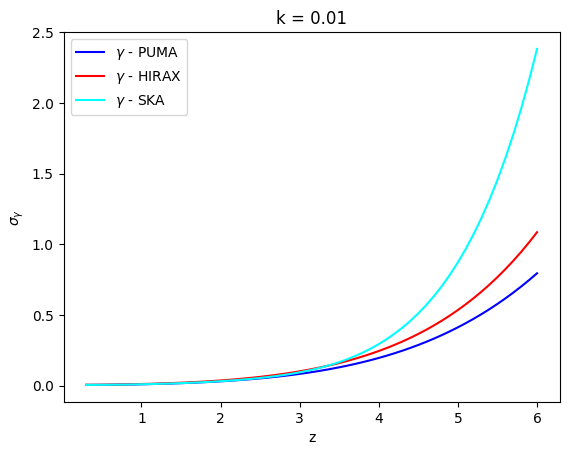

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 58 and the array at index 1 has size 20

In [13]:
import matplotlib.pyplot as plt

# 1. Extract the X values (the first element of each row)
x_vals = [row[0] for row in store1]

# 2. Extract the Y values from the tuples
y1_vals = [row[1][0] for row in store1] # The first number in the tuple
y2_vals = [row[1][1] for row in store1] # The second number in the tuple

# 2. Extract the Y values from the tuples
y3_vals = [row[1][0] for row in store2] # The first number in the tuple
y4_vals = [row[1][1] for row in store2] # The second number in the tuple

# 2. Extract the Y values from the tuples
y5_vals = [row[1][0] for row in store3] # The first number in the tuple
y6_vals = [row[1][1] for row in store3] # The second number in the tuple

# 3. Plot them explicitly so you can label them
plt.plot(x_vals, y1_vals, label=r'$\gamma$ - PUMA', color='blue')
# plt.loglog(x_vals, y2_vals, label=r'$\beta$ - PUMA', color='orange')

plt.plot(x_vals, y3_vals, label=r'$\gamma$ - HIRAX', color='red')
# plt.loglog(x_vals, y4_vals, label=r'$\beta$ - HIRAX', color='green')

plt.plot(x_vals, y5_vals, label=r'$\gamma$ - SKA', color='cyan')
# plt.loglog(x_vals, y6_vals, label=r'$\beta$ - SKA', color='black')

plt.xlabel('z')
plt.ylabel(r'$\sigma_{\gamma}$')
plt.title("k = 0.01")
plt.legend()
plt.savefig("gamma_full_QS_14.pdf")
plt.show()
z_val = np.linspace(0,3,20)
survey = "PUMA"
k_vals = 0.01

h = 0.6766
Obh2 = 0.02242
Och2 = 0.11933

def OM_m(z):
    OM = (Obh2 + Och2) / h**2
    return (OM * (1+z)**3 / (OM * (1+z)**3 + 1 - OM))

store_gamma = []
store_beta = []
for z_i in z_val:
    bias = Power_HI(k_vals, 0, z_i, survey).bHI(z_i)
    gamma_val = gamma_interpolator(k_vals, z_i)
    f_kz = OM_m(z_i)**gamma_interpolator(k_vals, z_i) # gamma_interpolator(k_test, z_test)
    beta_val = f_kz/bias
    store_gamma.append(gamma_val)
    store_beta.append(beta_val)

# np.savetxt("data_PUMA_full_QS.dat",np.column_stack((x_vals, store_gamma ,y1_vals, store_beta, y2_vals)))
# np.savetxt("data_HIRAX_full_QS.dat",np.column_stack((x_vals, store_gamma, y3_vals, store_beta, y4_vals)))
# np.savetxt("data_SKA_full_QS.dat",np.column_stack((x_vals, store_gamma, y5_vals, store_beta, y6_vals)))

# import numpy as np

# Define your header string once to keep things clean and consistent
my_header = "z_val  gamma_fid  gamma_error  beta_fid  beta_error"

# Pass the header variable into each savetxt function
np.savetxt("data_PUMA_full_QS_1e_14.dat", 
           np.column_stack((x_vals, store_gamma, y1_vals, store_beta, y2_vals)), 
           header=my_header)

np.savetxt("data_HIRAX_full_QS_1e_14.dat", 
           np.column_stack((x_vals, store_gamma, y3_vals, store_beta, y4_vals)), 
           header=my_header)

np.savetxt("data_SKA_full_QS_1e_14.dat", 
           np.column_stack((x_vals, store_gamma, y5_vals, store_beta, y6_vals)), 
           header=my_header)

plt.plot(x_vals, y2_vals, label=r'$\beta$ - PUMA', color='orange')
plt.plot(x_vals, y6_vals, label=r'$\beta$ - SKA', color='black')
plt.plot(x_vals, y4_vals, label=r'$\beta$ - HIRAX', color='green')
plt.xlabel('z')
plt.ylabel(r'$\sigma_{\beta}$')
plt.title("k = 0.01")
plt.legend()
plt.savefig("beta_full_QS_1e_14.pdf")
plt.show()

In [33]:
import numpy as np
from joblib import Parallel, delayed

dz = 0.1
survey = "PUMA"

z_min = Telescope[survey]["Redshift_range"][0]
z_max = Telescope[survey]["Redshift_range"][1]

z_val = np.arange(z_min, z_max + dz, dz)

kfg = 0.01
k_vals = 0.01
h = 0.6766
ns = 0.9665

def compute_sigma(z_i):
    k_max = 0.1 * (1 + z_i)**(2. / (2 + ns)) * h
    return Sigma_g2m(k_vals, z_i, dz, k_max, kfg, survey)

# Parallel computation
results_list = Parallel(n_jobs=-1)(
    delayed(compute_sigma)(z_i) for z_i in z_val
)

# Convert to array
results_array = np.array(results_list)

# Cumulative sum
cumu_array = np.cumsum(results_array)   # multiply by dz here if needed

# Store results
store1 = list(zip(z_val, cumu_array))

In [34]:
survey = "SKA_MID"

z_min = Telescope[survey]["Redshift_range"][0]
z_max = Telescope[survey]["Redshift_range"][1]

z_val = np.arange(z_min, z_max + dz, dz)

kfg = 0.01
k_vals = 0.01
h = 0.6766
ns = 0.9665

def compute_sigma(z_i):
    k_max = 0.1 * (1 + z_i)**(2. / (2 + ns)) * h
    return Sigma_g2m(k_vals, z_i, dz, k_max, kfg, survey)

# Parallel computation
results_list = Parallel(n_jobs=-1)(
    delayed(compute_sigma)(z_i) for z_i in z_val
)

# Convert to array
results_array = np.array(results_list)

# Cumulative sum
cumu_array = np.cumsum(results_array)   # multiply by dz here if needed

# Store results
store2 = list(zip(z_val, cumu_array))

survey = "HIRAX"

z_min = Telescope[survey]["Redshift_range"][0]
z_max = Telescope[survey]["Redshift_range"][1]

z_val = np.arange(z_min, z_max + dz, dz)

def compute_sigma(z_i):
    k_max = 0.1 * (1 + z_i)**(2. / (2 + ns)) * h
    return Sigma_g2m(k_vals, z_i, dz, k_max, kfg, survey)

# Parallel computation
results_list = Parallel(n_jobs=-1)(
    delayed(compute_sigma)(z_i) for z_i in z_val
)

# Convert to array
results_array = np.array(results_list)

# Cumulative sum
cumu_array = np.cumsum(results_array)   # multiply by dz here if needed

# Store results
store3 = list(zip(z_val, cumu_array))

Printing the fisher matrix 62.47836055296502 35502.6554870891
Printing the fisher matrix nan nan
Printing the fisher matrix 9995.928139757787 87970.94767151112
Printing the fisher matrix 820.4243463519269 54732.09716842755
Printing the fisher matrix 0.2608483645454825 14020.996718495651
Printing the fisher matrix 2605.3441359624985 68770.74186401643
Printing the fisher matrix 445.00813656886226 49293.69120834965
Printing the fisher matrix 0.6273178997192375 16267.886641836589
Printing the fisher matrix 5244.825919545194 80095.27588815836
Printing the fisher matrix 30335.23290866268 105290.68640668735
Printing the fisher matrix nan nan
Printing the fisher matrix 30.70321456737492 29747.2340722102
Printing the fisher matrix 3194.572754272251 73605.22737867216
Printing the fisher matrix 0.3663375920573242 14810.688128060865
Printing the fisher matrix 501.31704756727186 49000.49013975467
Printing the fisher matrix 29.097380583290654 31273.381151215224
Printing the fisher matrix 3.013043218

KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt

# 1. Extract the X values (the first element of each row)
x_vals = [row[0] for row in store1]

# 2. Extract the Y values from the tuples
y1_vals = [row[1][0] for row in store1] # The first number in the tuple
y2_vals = [row[1][1] for row in store1] # The second number in the tuple

# 2. Extract the Y values from the tuples
y3_vals = [row[1][0] for row in store2] # The first number in the tuple
y4_vals = [row[1][1] for row in store2] # The second number in the tuple

# 2. Extract the Y values from the tuples
y5_vals = [row[1][0] for row in store3] # The first number in the tuple
y6_vals = [row[1][1] for row in store3] # The second number in the tuple

# 3. Plot them explicitly so you can label them
plt.plot(x_vals, y1_vals, label=r'$\gamma$ - PUMA', color='blue')
# plt.loglog(x_vals, y2_vals, label=r'$\beta$ - PUMA', color='orange')

plt.plot(x_vals, y3_vals, label=r'$\gamma$ - HIRAX', color='red')
# plt.loglog(x_vals, y4_vals, label=r'$\beta$ - HIRAX', color='green')

plt.plot(x_vals, y5_vals, label=r'$\gamma$ - SKA', color='cyan')
# plt.loglog(x_vals, y6_vals, label=r'$\beta$ - SKA', color='black')

plt.xlabel('z')
plt.ylabel(r'$\sigma_{\gamma}$')
plt.title("k = 0.01")
plt.legend()
plt.savefig("gamma_full_QS_12_CUM.pdf")
plt.show()

In [ ]:
z_val = np.linspace(0,3,20)
survey = "PUMA"
k_vals = 0.01

h = 0.6766
Obh2 = 0.02242
Och2 = 0.11933

def OM_m(z):
    OM = (Obh2 + Och2) / h**2
    return (OM * (1+z)**3 / (OM * (1+z)**3 + 1 - OM))

store_gamma = []
store_beta = []
for z_i in z_val:
    bias = Power_HI(k_vals, 0, z_i, survey).bHI(z_i)
    gamma_val = gamma_interpolator(k_vals, z_i)
    f_kz = OM_m(z_i)**gamma_interpolator(k_vals, z_i) # gamma_interpolator(k_test, z_test)
    beta_val = f_kz/bias
    store_gamma.append(gamma_val)
    store_beta.append(beta_val)

# np.savetxt("data_PUMA_full_QS.dat",np.column_stack((x_vals, store_gamma ,y1_vals, store_beta, y2_vals)))
# np.savetxt("data_HIRAX_full_QS.dat",np.column_stack((x_vals, store_gamma, y3_vals, store_beta, y4_vals)))
# np.savetxt("data_SKA_full_QS.dat",np.column_stack((x_vals, store_gamma, y5_vals, store_beta, y6_vals)))

# import numpy as np

# Define your header string once to keep things clean and consistent
my_header = "z_val  gamma_fid  gamma_error  beta_fid  beta_error"

# Pass the header variable into each savetxt function
np.savetxt("data_PUMA_full_QS_12_CUM.dat", 
           np.column_stack((x_vals, store_gamma, y1_vals, store_beta, y2_vals)), 
           header=my_header)

np.savetxt("data_HIRAX_full_QS_12_CUM.dat", 
           np.column_stack((x_vals, store_gamma, y3_vals, store_beta, y4_vals)), 
           header=my_header)

np.savetxt("data_SKA_full_QS_12_CUM.dat", 
           np.column_stack((x_vals, store_gamma, y5_vals, store_beta, y6_vals)), 
           header=my_header)

In [ ]:
plt.plot(x_vals, y2_vals, label=r'$\beta$ - PUMA', color='orange')
plt.plot(x_vals, y6_vals, label=r'$\beta$ - SKA', color='black')
plt.plot(x_vals, y4_vals, label=r'$\beta$ - HIRAX', color='green')
plt.xlabel('z')
plt.ylabel(r'$\sigma_{\beta}$')
plt.title("k = 0.01")
plt.legend()
plt.savefig("beta_full_QS_12_CUM.pdf")
plt.show()

In [8]:
# Sigma_g2m(k,z, dz, k_max,kfg, survey)
dz = 0.1
z_val = np.linspace(0,3,20)
survey = "PUMA"
kfg = 0.01
k_vals = 0.01
store1 = []
h = 0.6766
ns = 0.9665

for z_i in z_val:
    k_max = 0.1 * (1 + z_i)**(2. / (2 + ns)) * h
    results = Sigma_g2m(k_vals, z_i, dz, k_max, kfg, survey)
    store1.append([z_i,results])

survey = "HIRAX"
store2 = []
for z_i in z_val:
    k_max = 0.1 * (1 + z_i)**(2. / (2 + ns)) * h
    results = Sigma_g2m(k_vals, z_i, dz, k_max, kfg, survey)
    store2.append([z_i,results])

survey = "SKA_MID"
store3 = []
for z_i in z_val:
    k_max = 0.1 * (1 + z_i)**(2. / (2 + ns)) * h
    results = Sigma_g2m(k_vals, z_i, dz, k_max, kfg, survey)
    store3.append([z_i,results])


Printing the fisher matrix 4484.197023950013 5364.374005608555
Printing the fisher matrix 42558.93305850298 68554.37925362217
Printing the fisher matrix 45611.210619796715 106648.67264933468
Printing the fisher matrix 31600.21116405181 112319.87004715804
Printing the fisher matrix 19202.932157416548 106387.77346120852
Printing the fisher matrix 11163.785999005615 97491.24668515868
Printing the fisher matrix 6424.87749569831 88508.02149957005
Printing the fisher matrix 3721.419667578058 80411.72190017166
Printing the fisher matrix 2178.667528586146 73168.80845251224
Printing the fisher matrix 1296.8054403186536 66910.86216656733
Printing the fisher matrix 783.7190590915967 61360.05164506926
Printing the fisher matrix 481.83936325379926 56514.33244986008
Printing the fisher matrix 300.96240348221147 52212.43526096855
Printing the fisher matrix 190.90672375832202 48383.97361010968
Printing the fisher matrix 122.92884683116587 44972.105583093915
Printing the fisher matrix 80.22915350712556

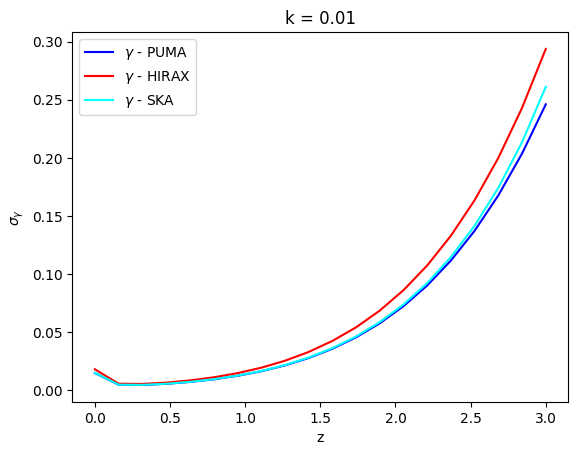

In [9]:
import matplotlib.pyplot as plt

# 1. Extract the X values (the first element of each row)
x_vals = [row[0] for row in store1]

# 2. Extract the Y values from the tuples
y1_vals = [row[1][0] for row in store1] # The first number in the tuple
y2_vals = [row[1][1] for row in store1] # The second number in the tuple

# 2. Extract the Y values from the tuples
y3_vals = [row[1][0] for row in store2] # The first number in the tuple
y4_vals = [row[1][1] for row in store2] # The second number in the tuple

# 2. Extract the Y values from the tuples
y5_vals = [row[1][0] for row in store3] # The first number in the tuple
y6_vals = [row[1][1] for row in store3] # The second number in the tuple

# 3. Plot them explicitly so you can label them
plt.plot(x_vals, y1_vals, label=r'$\gamma$ - PUMA', color='blue')
# plt.loglog(x_vals, y2_vals, label=r'$\beta$ - PUMA', color='orange')

plt.plot(x_vals, y3_vals, label=r'$\gamma$ - HIRAX', color='red')
# plt.loglog(x_vals, y4_vals, label=r'$\beta$ - HIRAX', color='green')

plt.plot(x_vals, y5_vals, label=r'$\gamma$ - SKA', color='cyan')
# plt.loglog(x_vals, y6_vals, label=r'$\beta$ - SKA', color='black')

plt.xlabel('z')
plt.ylabel(r'$\sigma_{\gamma}$')
plt.title("k = 0.01")
plt.legend()
plt.savefig("gamma_full_QS_12.pdf")
plt.show()

In [10]:
z_val = np.linspace(0,3,20)
survey = "PUMA"
k_vals = 0.01

h = 0.6766
Obh2 = 0.02242
Och2 = 0.11933

def OM_m(z):
    OM = (Obh2 + Och2) / h**2
    return (OM * (1+z)**3 / (OM * (1+z)**3 + 1 - OM))

store_gamma = []
store_beta = []
for z_i in z_val:
    bias = Power_HI(k_vals, 0, z_i, survey).bHI(z_i)
    gamma_val = gamma_interpolator(k_vals, z_i)
    f_kz = OM_m(z_i)**gamma_interpolator(k_vals, z_i) # gamma_interpolator(k_test, z_test)
    beta_val = f_kz/bias
    store_gamma.append(gamma_val)
    store_beta.append(beta_val)

# np.savetxt("data_PUMA_full_QS.dat",np.column_stack((x_vals, store_gamma ,y1_vals, store_beta, y2_vals)))
# np.savetxt("data_HIRAX_full_QS.dat",np.column_stack((x_vals, store_gamma, y3_vals, store_beta, y4_vals)))
# np.savetxt("data_SKA_full_QS.dat",np.column_stack((x_vals, store_gamma, y5_vals, store_beta, y6_vals)))

# import numpy as np

# Define your header string once to keep things clean and consistent
my_header = "z_val  gamma_fid  gamma_error  beta_fid  beta_error"

# Pass the header variable into each savetxt function
np.savetxt("data_PUMA_full_QS_12.dat", 
           np.column_stack((x_vals, store_gamma, y1_vals, store_beta, y2_vals)), 
           header=my_header)

np.savetxt("data_HIRAX_full_QS_12.dat", 
           np.column_stack((x_vals, store_gamma, y3_vals, store_beta, y4_vals)), 
           header=my_header)

np.savetxt("data_SKA_full_QS_12.dat", 
           np.column_stack((x_vals, store_gamma, y5_vals, store_beta, y6_vals)), 
           header=my_header)

In [ ]:
# For x_init = 12
data1 = np.loadtxt("data_PUMA_full_QS_12.dat")
data2 = np.loadtxt("data_HIRAX_full_QS_12.dat")
data3 = np.loadtxt("data_SKA_full_QS_12.dat")

plt.plot(data1[:,0], data1[:,2], label = 'PUMA')
plt.plot(data2[:,0], data2[:,2], label = 'HIRAX')
plt.plot(data3[:,0], data3[:,2], label = 'SKA')
plt.legend()

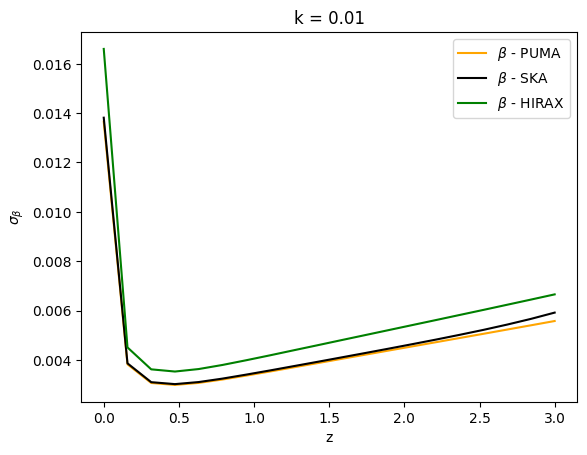

In [11]:
plt.plot(x_vals, y2_vals, label=r'$\beta$ - PUMA', color='orange')
plt.plot(x_vals, y6_vals, label=r'$\beta$ - SKA', color='black')
plt.plot(x_vals, y4_vals, label=r'$\beta$ - HIRAX', color='green')
plt.xlabel('z')
plt.ylabel(r'$\sigma_{\beta}$')
plt.title("k = 0.01")
plt.legend()
plt.savefig("beta_full_QS_12.pdf")
plt.show()

In [12]:
import math
import numpy as np
from astropy.cosmology import Planck18 as cosmo
from scipy import interpolate
from scipy import integrate
import matplotlib.pyplot as plt
import pandas as pd
import scipy.linalg
import sys
from math import floor
import camb

# growth index
def gamma_interpolator(k,z):
    data_D = np.loadtxt("data_full_QS_13.dat")
    # k_value  z_plot  Normalized_Delta  Gamma
    points = np.column_stack((data_D[:,0], data_D[:,1]))
    interpole_gama = interpolate.LinearNDInterpolator(points,data_D[:,3])
    return interpole_gama(k,z)
    
class Power_HI:
    def __init__(self, k, mu, z,survey):
        self.k = k
        self.mu = mu
        self.z = z
        self.h = 0.6766
        self.Obh2 = 0.02242
        self.Och2 = 0.11933
        self.OMh2 = self.Obh2 + self.Och2
        # self.gamma_value = gamma_interpolator(self.k, self.z)
        self.survey = survey
        # self.pk()

    def OHI(self, z):
        return 4e-4*(1+z)**0.6
    
    def bHI(self, z):
        #return 1.333 + 0.1809*z + 0.05302*z**2 - 0.0008822*z**3
        return 0.754 + 0.0877*z + 0.0607*z**2 - 0.00274*z**3

    def Tb_mean(self):
        '''
        output in units of mK
        '''
        return 188.0*self.OHI(self.z)*self.h*(1+self.z)**2*cosmo.H(0).value/cosmo.H(self.z).value

    def P_matter(self, z=0):
        """
        Calculate matter power spectrum for stored k values and given z (default z=0).
        Returns: P(k,z) in Mpc^3
        """
        pars = camb.CAMBparams()
        pars.set_cosmology(
            H0=self.h * 100,
            ombh2=self.Obh2,
            omch2=self.Och2,
            mnu=0.06,
            omk=0,
            tau=0.39
        )
        # pars.InitPower.set_params(As=self.As, ns=self.ns, r=0)
        pars.set_for_lmax(2500, lens_potential_accuracy=0)
        pars.set_accuracy(AccuracyBoost=4)
        pars.set_matter_power(redshifts=[z], kmax=max(np.atleast_1d(self.k)) * 1.1)
        
        results = camb.get_results(pars)
        P_m = results.get_matter_power_interpolator(
            nonlinear=None, hubble_units=False, k_hunit=False
        )
        return P_m.P(z, self.k)

    def f(self):
        OM = (self.Obh2 + self.Och2) / self.h**2
        return (OM * (1+self.z)**3 / (OM * (1+self.z)**3 + 1 - OM))**gamma_interpolator(self.k,self.z)

    def FoG(self):
        SigmaP = 350
        return np.exp(-self.k**2*self.mu**2*SigmaP**2/cosmo.H(self.z).value**2)

    def growth(self, k, z):
        data_D = np.loadtxt("data_full_QS_13.dat")

        points = np.column_stack((data_D[:,0], data_D[:,1]))
        growth_D = interpolate.LinearNDInterpolator(points,data_D[:,2])
        # k_value  z_plot  Normalized_Delta  Gamma
        return growth_D(k,z)

    def P_HI(self):
        beta_val = self.f()/self.bHI(self.z)
        # print("Print beta ",beta_val)
        Powe = self.Tb_mean()**2 * self.FoG() * (1 + self.mu**2*beta_val)**2*self.bHI(self.z)**2*self.growth(self.k, self.z)*self.P_matter()
        # print("Power spectrum of 21cm signal", Powe)
        return Powe

    def PN(self):
        Noise = noise(self.survey)
        PN = Noise.noise_power_Mpc(self.z, self.k, self.mu)
        return PN

    def P_tot(self):
        P_fid = self.P_HI() + self.PN()
        power_noi = self.PN()
        # print("Noise power spectrum of HIRAX for 5 years:", power_noi)
        return P_fid

class Fisher:
    def __init__(self, k, z, dz, kmax, kfg, survey):
        self.k = k
        self.z = z
        self.dz = dz
        self.kmax = kmax
        self.h = 0.6766
        self.Obh2 = 0.02242
        self.Och2 = 0.11933
        self.kfg = kfg
        self.OM = (self.Obh2 + self.Och2) / self.h**2
        self.survey = survey
        self.kfg = kfg
    

    def V(self, z):
        f_sky = Telescope[self.survey]["Sky_fraction"]
        A = 4 * np.pi * f_sky
        v = A / 3 * ((cosmo.comoving_distance(z+self.dz/2).value)**3 - (cosmo.comoving_distance(z-self.dz/2).value)**3)
        return v

    def OM_m(self):
        OM = (self.Obh2 + self.Och2) / self.h**2
        return (OM * (1+self.z)**3 / (OM * (1+self.z)**3 + 1 - OM))

    def alpha(self, z):
        Dd = Telescope[self.survey]["Dish_diameter"]
        return np.arctan(cosmo.H(z).value * cosmo.comoving_distance(z).value * np.sin(0.61 * self.theta_b(z)) / (3e+5 * (1 + z)))

    def theta_b(self, z):
        Dd = Telescope[self.survey]["Dish_diameter"]
        return (1 + z) * 0.21 / Dd  # 0.21 meter wavelength

    def dP_dfi(self,k, mu, z, param):
        bias = Power_HI(k, mu, z, self.survey).bHI(z)
        matter_power = Power_HI(k, mu, z, self.survey).P_matter()
        f_kz = self.OM_m()**gamma_interpolator(k,z) # gamma_interpolator(k_test, z_test)
        beta_val = f_kz/bias
        
        ''' Change this'''
        if param == "gamma":
            # beta_val = self.f()/self.bHI(self.z)
            # f_kz = self.OM_m()**gamma_interpolator(k,z) # gamma_interpolator(k_test, z_test)
            # P_m = Power_HI(k, mu, z, self.survey).P_HI()
            # bias = Power_HI(k, mu, z, self.survey).bHI(z)
            # dP_df = 2*P_m*(bias + mu**2*f_kz)*mu**2*f_kz*np.log(self.OM_m())
            dP_df = 2*(1.0 + mu**2*beta_val)*matter_power*bias*mu**2*f_kz*np.log(self.OM_m())
            return dP_df

        elif param == "beta_par":
            dP_df = 2*(1.0 + mu**2*beta_val)*mu**2*bias**2*matter_power
            return dP_df

        else:
            print("Enter correct NAME")
            
    '''factor 2 from mu integration'''
    def inter(self, k, mu, z, param1, param2):
        integ_val = 2*self.V(z)/(8*np.pi**2)*k**2*self.dP_dfi(k, mu, z, param1)*self.dP_dfi(k, mu, z, param2)/(Power_HI(k, mu, z,self.survey).P_tot())**2
        return integ_val

    # Fisher matrix code
    def fisher_quad(self,param1, param2):
        n_bins = 50

        # print("Fundamental k ",2 * np.pi / (self.V(self.z))**(1/3))
        # For Interference
        if self.survey == "HIRAX" or self.survey == "PUMA":
        
            
            mu_min, mu_max = np.sin(self.alpha(self.z)), 1.0
            k_f = 2 * np.pi / (self.V(self.z))**(1/3)
            k_fg = self.kfg * self.h
            # k_min = lambda mu: np.where(k_f > k_fg, k_f / np.abs(mu), k_fg / np.abs(mu))
            k_min = lambda mu: np.maximum(np.array(k_f)/np.abs(mu) , np.array(k_fg)/np.abs(mu))
            
            k_max = self.kmax

        # For Single Dish
        elif self.survey == "SKA_MID":
        
            
            mu_min, mu_max = 0.0 , 1.0
            k_f = 2 * np.pi / (self.V(self.z))**(1/3)
            k_fg = self.kfg * self.h
            # k_min = lambda mu: np.where(k_f > k_fg, k_f / np.abs(mu), k_fg / np.abs(mu))
            # k_min = lambda mu: np.maximum(np.array(k_f)/np.abs(mu) , np.array(k_fg)/np.abs(mu))
            k_min = lambda mu: np.maximum(np.array(k_f) , np.array(k_fg))/np.abs(mu)
            
            k_max = self.kmax
        else:
            print("Enter correct name")

        mu_bins = np.linspace(mu_min, mu_max, n_bins)
        dmu = mu_bins[1] - mu_bins[0]
        mu_midpoints = (mu_bins[:-1] + mu_bins[1:]) * 0.5
        sum_result = 0

        k_low_vals = k_min(mu_midpoints)
        dk_vals = (k_max - k_low_vals) / (n_bins - 1)

        # 2. Evaluate the integrand for all mu_midpoints at once
        integrand_vals = self.inter(self.k, mu_midpoints, self.z, param1, param2)

        # 3. Multiply and sum over the mu axis
        # We sum over the axis corresponding to mu (adjust axis=0 or axis=-1 depending on 
        # the exact shape self.inter returns when given self.k and mu arrays).
        sum_result += np.sum(integrand_vals * dk_vals * dmu, axis=0)
        return sum_result


def Sigma_g2m(k,z, dz, k_max,kfg, survey):
    # F_ij = np.zeros((2,2))
    # print(F_ij.shape)
    # fisher_quad(self,param1, param2)
    F_ij_1= Fisher(k,z, dz, k_max, kfg, survey).fisher_quad("gamma","gamma")
    # F_ij[0,1] = Fisher(k,z, dz, k_max, kfg, survey).fisher_quad("gamma","beta_par")
    # F_ij[0,0] = Fisher(k,z, dz, k_max, kfg, survey).fisher_quad("gamma","beta_par")
    F_ij_2 = Fisher(k,z, dz, k_max, kfg, survey).fisher_quad("beta_par","beta_par")

    print("Printing the fisher matrix",F_ij_1, F_ij_2)
    # print(F_ij_1, F_ij_2)
    return F_ij_1**(-1/2),F_ij_2**(-1/2)


# Define All the form of f(k)
def fun(k,q):
    kg = 0.05
    return (k/kg)**q
# Calling the function....
z = 1
dz = 0.1
k_val = 0.01

h = 0.6766
ns = 0.9665
k_max = 0.1 * (1 + z)**(2. / (2 + ns)) * h
print("k_max possible:", k_max)
kmax = np.linspace(0.10, k_max, 8)

quadrup = []

# fisher = Fisher(0.1*h,z, dz, k_max, 0.01, "HIRAX")
# print("Survey volume", fisher.V(z))
# fish = fisher.fisher_quad()
# quadrup.append(fish)
# print("Fisher matrix for HIRAX with kfg=0.00 :", fish)
print("printing the sigma using above function",Sigma_g2m(k_val,z, dz, k_max, 0, "HIRAX"))

k_max possible: 0.1079654913116559
Printing the fisher matrix 3598.296887364026 62217.506108945076
printing the sigma using above function (np.float64(0.016670610456399174), np.float64(0.004009070564671004))


In [13]:
# Sigma_g2m(k,z, dz, k_max,kfg, survey)
dz = 0.1
z_val = np.linspace(0,3,20)
survey = "PUMA"
kfg = 0.01
k_vals = 0.01
store1 = []
h = 0.6766
ns = 0.9665

for z_i in z_val:
    k_max = 0.1 * (1 + z_i)**(2. / (2 + ns)) * h
    results = Sigma_g2m(k_vals, z_i, dz, k_max, kfg, survey)
    store1.append([z_i,results])

survey = "HIRAX"
store2 = []
for z_i in z_val:
    k_max = 0.1 * (1 + z_i)**(2. / (2 + ns)) * h
    results = Sigma_g2m(k_vals, z_i, dz, k_max, kfg, survey)
    store2.append([z_i,results])

survey = "SKA_MID"
store3 = []
for z_i in z_val:
    k_max = 0.1 * (1 + z_i)**(2. / (2 + ns)) * h
    results = Sigma_g2m(k_vals, z_i, dz, k_max, kfg, survey)
    store3.append([z_i,results])


Printing the fisher matrix 4071.108462813534 5632.401234679338
Printing the fisher matrix 38243.30541318651 71201.54238235738
Printing the fisher matrix 40754.305261792004 109335.69880202506
Printing the fisher matrix 28160.369445789205 113501.72139294182
Printing the fisher matrix 17102.548424899273 105939.60220992842
Printing the fisher matrix 9958.216077105028 95733.17768332943
Printing the fisher matrix 5745.922631201053 85837.4407500239
Printing the fisher matrix 3337.5290601813717 77154.02151873607
Printing the fisher matrix 1960.1426618475573 69587.09480718905
Printing the fisher matrix 1169.9552585301374 63175.48164094563
Printing the fisher matrix 708.9097136942096 57602.12452529512
Printing the fisher matrix 436.8027781035094 52809.61669301983
Printing the fisher matrix 273.34510489987224 48613.06841687948
Printing the fisher matrix 173.66382456037996 44920.145116039654
Printing the fisher matrix 111.97108173067761 41657.83709720064
Printing the fisher matrix 73.1583766280147

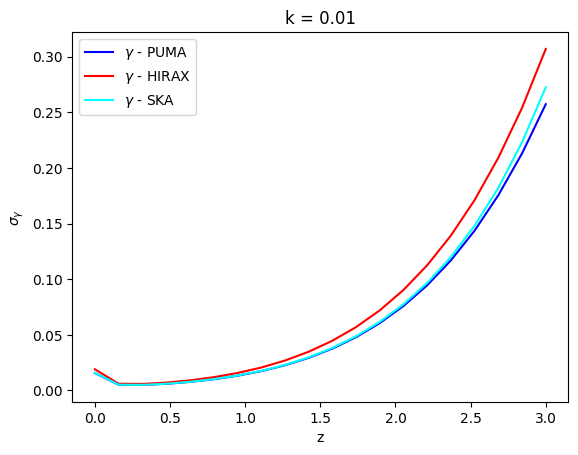

In [14]:
import matplotlib.pyplot as plt

# 1. Extract the X values (the first element of each row)
x_vals = [row[0] for row in store1]

# 2. Extract the Y values from the tuples
y1_vals = [row[1][0] for row in store1] # The first number in the tuple
y2_vals = [row[1][1] for row in store1] # The second number in the tuple

# 2. Extract the Y values from the tuples
y3_vals = [row[1][0] for row in store2] # The first number in the tuple
y4_vals = [row[1][1] for row in store2] # The second number in the tuple

# 2. Extract the Y values from the tuples
y5_vals = [row[1][0] for row in store3] # The first number in the tuple
y6_vals = [row[1][1] for row in store3] # The second number in the tuple

# 3. Plot them explicitly so you can label them
plt.plot(x_vals, y1_vals, label=r'$\gamma$ - PUMA', color='blue')
# plt.loglog(x_vals, y2_vals, label=r'$\beta$ - PUMA', color='orange')

plt.plot(x_vals, y3_vals, label=r'$\gamma$ - HIRAX', color='red')
# plt.loglog(x_vals, y4_vals, label=r'$\beta$ - HIRAX', color='green')

plt.plot(x_vals, y5_vals, label=r'$\gamma$ - SKA', color='cyan')
# plt.loglog(x_vals, y6_vals, label=r'$\beta$ - SKA', color='black')

plt.xlabel('z')
plt.ylabel(r'$\sigma_{\gamma}$')
plt.title("k = 0.01")
plt.legend()
plt.savefig("gamma_full_QS_13.pdf")
plt.show()

In [15]:
import matplotlib.pyplot as plt

# 1. Extract the X values (the first element of each row)
x_vals = [row[0] for row in store1]

# 2. Extract the Y values from the tuples
y1_vals = [row[1][0] for row in store1] # The first number in the tuple
y2_vals = [row[1][1] for row in store1] # The second number in the tuple

# 2. Extract the Y values from the tuples
y3_vals = [row[1][0] for row in store2] # The first number in the tuple
y4_vals = [row[1][1] for row in store2] # The second number in the tuple

# 2. Extract the Y values from the tuples
y5_vals = [row[1][0] for row in store3] # The first number in the tuple
y6_vals = [row[1][1] for row in store3] # The second number in the tuple

# 3. Plot them explicitly so you can label them
plt.plot(x_vals, y1_vals, label=r'$\gamma$ - PUMA', color='blue')
# plt.loglog(x_vals, y2_vals, label=r'$\beta$ - PUMA', color='orange')

plt.plot(x_vals, y3_vals, label=r'$\gamma$ - HIRAX', color='red')
# plt.loglog(x_vals, y4_vals, label=r'$\beta$ - HIRAX', color='green')

plt.plot(x_vals, y5_vals, label=r'$\gamma$ - SKA', color='cyan')
# plt.loglog(x_vals, y6_vals, label=r'$\beta$ - SKA', color='black')

plt.xlabel('z')
plt.ylabel(r'$\sigma_{\gamma}$')
plt.title("k = 0.01")
plt.legend()
plt.savefig("gamma_full_QS_13.pdf")
plt.show()
z_val = np.linspace(0,3,20)
survey = "PUMA"
k_vals = 0.01

h = 0.6766
Obh2 = 0.02242
Och2 = 0.11933

def OM_m(z):
    OM = (Obh2 + Och2) / h**2
    return (OM * (1+z)**3 / (OM * (1+z)**3 + 1 - OM))

store_gamma = []
store_beta = []
for z_i in z_val:
    bias = Power_HI(k_vals, 0, z_i, survey).bHI(z_i)
    gamma_val = gamma_interpolator(k_vals, z_i)
    f_kz = OM_m(z_i)**gamma_interpolator(k_vals, z_i) # gamma_interpolator(k_test, z_test)
    beta_val = f_kz/bias
    store_gamma.append(gamma_val)
    store_beta.append(beta_val)

# np.savetxt("data_PUMA_full_QS.dat",np.column_stack((x_vals, store_gamma ,y1_vals, store_beta, y2_vals)))
# np.savetxt("data_HIRAX_full_QS.dat",np.column_stack((x_vals, store_gamma, y3_vals, store_beta, y4_vals)))
# np.savetxt("data_SKA_full_QS.dat",np.column_stack((x_vals, store_gamma, y5_vals, store_beta, y6_vals)))

# import numpy as np

# Define your header string once to keep things clean and consistent
my_header = "z_val  gamma_fid  gamma_error  beta_fid  beta_error"

# Pass the header variable into each savetxt function
np.savetxt("data_PUMA_full_QS_1e_13.dat", 
           np.column_stack((x_vals, store_gamma, y1_vals, store_beta, y2_vals)), 
           header=my_header)

np.savetxt("data_HIRAX_full_QS_1e_13.dat", 
           np.column_stack((x_vals, store_gamma, y3_vals, store_beta, y4_vals)), 
           header=my_header)

np.savetxt("data_SKA_full_QS_1e_13.dat", 
           np.column_stack((x_vals, store_gamma, y5_vals, store_beta, y6_vals)), 
           header=my_header)

plt.plot(x_vals, y2_vals, label=r'$\beta$ - PUMA', color='orange')
plt.plot(x_vals, y6_vals, label=r'$\beta$ - SKA', color='black')
plt.plot(x_vals, y4_vals, label=r'$\beta$ - HIRAX', color='green')
plt.xlabel('z')
plt.ylabel(r'$\sigma_{\beta}$')
plt.title("k = 0.01")
plt.legend()
plt.savefig("beta_full_QS_1e_13.pdf")
plt.show()

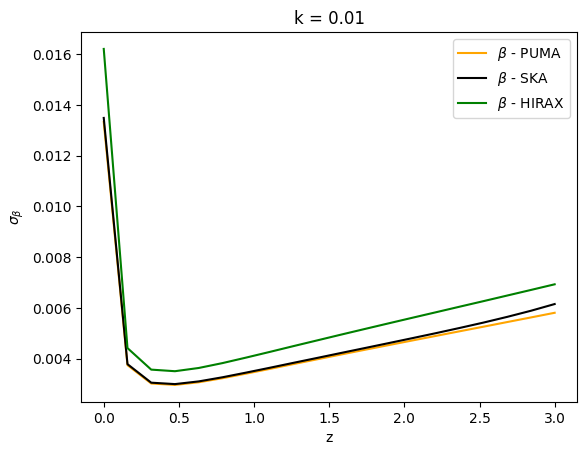

In [16]:
plt.plot(x_vals, y2_vals, label=r'$\beta$ - PUMA', color='orange')
plt.plot(x_vals, y6_vals, label=r'$\beta$ - SKA', color='black')
plt.plot(x_vals, y4_vals, label=r'$\beta$ - HIRAX', color='green')
plt.xlabel('z')
plt.ylabel(r'$\sigma_{\beta}$')
plt.title("k = 0.01")
plt.legend()
plt.savefig("beta_full_QS_1e_13.pdf")
plt.show()

In [18]:
import math
import numpy as np
from astropy.cosmology import Planck18 as cosmo
from scipy import interpolate
from scipy import integrate
import matplotlib.pyplot as plt
import pandas as pd
import scipy.linalg
import sys
from math import floor
import camb

# growth index
def gamma_interpolator(k,z):
    data_D = np.loadtxt("data_full_QS_14.dat")
    # k_value  z_plot  Normalized_Delta  Gamma
    points = np.column_stack((data_D[:,0], data_D[:,1]))
    interpole_gama = interpolate.LinearNDInterpolator(points,data_D[:,3])
    return interpole_gama(k,z)
    
class Power_HI:
    def __init__(self, k, mu, z,survey):
        self.k = k
        self.mu = mu
        self.z = z
        self.h = 0.6766
        self.Obh2 = 0.02242
        self.Och2 = 0.11933
        self.OMh2 = self.Obh2 + self.Och2
        # self.gamma_value = gamma_interpolator(self.k, self.z)
        self.survey = survey
        # self.pk()

    def OHI(self, z):
        return 4e-4*(1+z)**0.6
    
    def bHI(self, z):
        #return 1.333 + 0.1809*z + 0.05302*z**2 - 0.0008822*z**3
        return 0.754 + 0.0877*z + 0.0607*z**2 - 0.00274*z**3

    def Tb_mean(self):
        '''
        output in units of mK
        '''
        return 188.0*self.OHI(self.z)*self.h*(1+self.z)**2*cosmo.H(0).value/cosmo.H(self.z).value

    def P_matter(self, z=0):
        """
        Calculate matter power spectrum for stored k values and given z (default z=0).
        Returns: P(k,z) in Mpc^3
        """
        pars = camb.CAMBparams()
        pars.set_cosmology(
            H0=self.h * 100,
            ombh2=self.Obh2,
            omch2=self.Och2,
            mnu=0.06,
            omk=0,
            tau=0.39
        )
        # pars.InitPower.set_params(As=self.As, ns=self.ns, r=0)
        pars.set_for_lmax(2500, lens_potential_accuracy=0)
        pars.set_accuracy(AccuracyBoost=4)
        pars.set_matter_power(redshifts=[z], kmax=max(np.atleast_1d(self.k)) * 1.1)
        
        results = camb.get_results(pars)
        P_m = results.get_matter_power_interpolator(
            nonlinear=None, hubble_units=False, k_hunit=False
        )
        return P_m.P(z, self.k)

    def f(self):
        OM = (self.Obh2 + self.Och2) / self.h**2
        return (OM * (1+self.z)**3 / (OM * (1+self.z)**3 + 1 - OM))**gamma_interpolator(self.k,self.z)

    def FoG(self):
        SigmaP = 350
        return np.exp(-self.k**2*self.mu**2*SigmaP**2/cosmo.H(self.z).value**2)

    def growth(self, k, z):
        data_D = np.loadtxt("data_full_QS_14.dat")

        points = np.column_stack((data_D[:,0], data_D[:,1]))
        growth_D = interpolate.LinearNDInterpolator(points,data_D[:,2])
        # k_value  z_plot  Normalized_Delta  Gamma
        return growth_D(k,z)

    def P_HI(self):
        beta_val = self.f()/self.bHI(self.z)
        # print("Print beta ",beta_val)
        Powe = self.Tb_mean()**2 * self.FoG() * (1 + self.mu**2*beta_val)**2*self.bHI(self.z)**2*self.growth(self.k, self.z)*self.P_matter()
        # print("Power spectrum of 21cm signal", Powe)
        return Powe

    def PN(self):
        Noise = noise(self.survey)
        PN = Noise.noise_power_Mpc(self.z, self.k, self.mu)
        return PN

    def P_tot(self):
        P_fid = self.P_HI() + self.PN()
        power_noi = self.PN()
        # print("Noise power spectrum of HIRAX for 5 years:", power_noi)
        return P_fid

class Fisher:
    def __init__(self, k, z, dz, kmax, kfg, survey):
        self.k = k
        self.z = z
        self.dz = dz
        self.kmax = kmax
        self.h = 0.6766
        self.Obh2 = 0.02242
        self.Och2 = 0.11933
        self.kfg = kfg
        self.OM = (self.Obh2 + self.Och2) / self.h**2
        self.survey = survey
        self.kfg = kfg
    

    def V(self, z):
        f_sky = Telescope[self.survey]["Sky_fraction"]
        A = 4 * np.pi * f_sky
        v = A / 3 * ((cosmo.comoving_distance(z+self.dz/2).value)**3 - (cosmo.comoving_distance(z-self.dz/2).value)**3)
        return v

    def OM_m(self):
        OM = (self.Obh2 + self.Och2) / self.h**2
        return (OM * (1+self.z)**3 / (OM * (1+self.z)**3 + 1 - OM))

    def alpha(self, z):
        Dd = Telescope[self.survey]["Dish_diameter"]
        return np.arctan(cosmo.H(z).value * cosmo.comoving_distance(z).value * np.sin(0.61 * self.theta_b(z)) / (3e+5 * (1 + z)))

    def theta_b(self, z):
        Dd = Telescope[self.survey]["Dish_diameter"]
        return (1 + z) * 0.21 / Dd  # 0.21 meter wavelength

    def dP_dfi(self,k, mu, z, param):
        bias = Power_HI(k, mu, z, self.survey).bHI(z)
        matter_power = Power_HI(k, mu, z, self.survey).P_matter()
        f_kz = self.OM_m()**gamma_interpolator(k,z) # gamma_interpolator(k_test, z_test)
        beta_val = f_kz/bias
        
        ''' Change this'''
        if param == "gamma":
            # beta_val = self.f()/self.bHI(self.z)
            # f_kz = self.OM_m()**gamma_interpolator(k,z) # gamma_interpolator(k_test, z_test)
            # P_m = Power_HI(k, mu, z, self.survey).P_HI()
            # bias = Power_HI(k, mu, z, self.survey).bHI(z)
            # dP_df = 2*P_m*(bias + mu**2*f_kz)*mu**2*f_kz*np.log(self.OM_m())
            dP_df = 2*(1.0 + mu**2*beta_val)*matter_power*bias*mu**2*f_kz*np.log(self.OM_m())
            return dP_df

        elif param == "beta_par":
            dP_df = 2*(1.0 + mu**2*beta_val)*mu**2*bias**2*matter_power
            return dP_df

        else:
            print("Enter correct NAME")
            
    '''factor 2 from mu integration'''
    def inter(self, k, mu, z, param1, param2):
        integ_val = 2*self.V(z)/(8*np.pi**2)*k**2*self.dP_dfi(k, mu, z, param1)*self.dP_dfi(k, mu, z, param2)/(Power_HI(k, mu, z,self.survey).P_tot())**2
        return integ_val

    # Fisher matrix code
    def fisher_quad(self,param1, param2):
        n_bins = 50

        # print("Fundamental k ",2 * np.pi / (self.V(self.z))**(1/3))
        # For Interference
        if self.survey == "HIRAX" or self.survey == "PUMA":
        
            
            mu_min, mu_max = np.sin(self.alpha(self.z)), 1.0
            k_f = 2 * np.pi / (self.V(self.z))**(1/3)
            k_fg = self.kfg * self.h
            # k_min = lambda mu: np.where(k_f > k_fg, k_f / np.abs(mu), k_fg / np.abs(mu))
            k_min = lambda mu: np.maximum(np.array(k_f)/np.abs(mu) , np.array(k_fg)/np.abs(mu))
            
            k_max = self.kmax

        # For Single Dish
        elif self.survey == "SKA_MID":
        
            
            mu_min, mu_max = 0.0 , 1.0
            k_f = 2 * np.pi / (self.V(self.z))**(1/3)
            k_fg = self.kfg * self.h
            # k_min = lambda mu: np.where(k_f > k_fg, k_f / np.abs(mu), k_fg / np.abs(mu))
            # k_min = lambda mu: np.maximum(np.array(k_f)/np.abs(mu) , np.array(k_fg)/np.abs(mu))
            k_min = lambda mu: np.maximum(np.array(k_f) , np.array(k_fg))/np.abs(mu)
            
            k_max = self.kmax
        else:
            print("Enter correct name")

        mu_bins = np.linspace(mu_min, mu_max, n_bins)
        dmu = mu_bins[1] - mu_bins[0]
        mu_midpoints = (mu_bins[:-1] + mu_bins[1:]) * 0.5
        sum_result = 0

        k_low_vals = k_min(mu_midpoints)
        dk_vals = (k_max - k_low_vals) / (n_bins - 1)

        # 2. Evaluate the integrand for all mu_midpoints at once
        integrand_vals = self.inter(self.k, mu_midpoints, self.z, param1, param2)

        # 3. Multiply and sum over the mu axis
        # We sum over the axis corresponding to mu (adjust axis=0 or axis=-1 depending on 
        # the exact shape self.inter returns when given self.k and mu arrays).
        sum_result += np.sum(integrand_vals * dk_vals * dmu, axis=0)
        return sum_result


def Sigma_g2m(k,z, dz, k_max,kfg, survey):
    # F_ij = np.zeros((2,2))
    # print(F_ij.shape)
    # fisher_quad(self,param1, param2)
    F_ij_1= Fisher(k,z, dz, k_max, kfg, survey).fisher_quad("gamma","gamma")
    # F_ij[0,1] = Fisher(k,z, dz, k_max, kfg, survey).fisher_quad("gamma","beta_par")
    # F_ij[0,0] = Fisher(k,z, dz, k_max, kfg, survey).fisher_quad("gamma","beta_par")
    F_ij_2 = Fisher(k,z, dz, k_max, kfg, survey).fisher_quad("beta_par","beta_par")

    print("Printing the fisher matrix",F_ij_1, F_ij_2)
    # print(F_ij_1, F_ij_2)
    return F_ij_1**(-1/2),F_ij_2**(-1/2)


# Define All the form of f(k)
def fun(k,q):
    kg = 0.05
    return (k/kg)**q
# Calling the function....
z = 1
dz = 0.1
k_val = 0.01

h = 0.6766
ns = 0.9665
k_max = 0.1 * (1 + z)**(2. / (2 + ns)) * h
print("k_max possible:", k_max)
kmax = np.linspace(0.10, k_max, 8)

quadrup = []

# fisher = Fisher(0.1*h,z, dz, k_max, 0.01, "HIRAX")
# print("Survey volume", fisher.V(z))
# fish = fisher.fisher_quad()
# quadrup.append(fish)
# print("Fisher matrix for HIRAX with kfg=0.00 :", fish)
print("printing the sigma using above function",Sigma_g2m(k_val,z, dz, k_max, 0, "HIRAX"))

k_max possible: 0.1079654913116559
Printing the fisher matrix 3504.85775188443 61342.00252719329
printing the sigma using above function (np.float64(0.016891367148994432), np.float64(0.004037578928607324))


In [19]:
# Sigma_g2m(k,z, dz, k_max,kfg, survey)
dz = 0.1
z_val = np.linspace(0,3,20)
survey = "PUMA"
kfg = 0.01
k_vals = 0.01
store1 = []
h = 0.6766
ns = 0.9665

for z_i in z_val:
    k_max = 0.1 * (1 + z_i)**(2. / (2 + ns)) * h
    results = Sigma_g2m(k_vals, z_i, dz, k_max, kfg, survey)
    store1.append([z_i,results])

survey = "HIRAX"
store2 = []
for z_i in z_val:
    k_max = 0.1 * (1 + z_i)**(2. / (2 + ns)) * h
    results = Sigma_g2m(k_vals, z_i, dz, k_max, kfg, survey)
    store2.append([z_i,results])

survey = "SKA_MID"
store3 = []
for z_i in z_val:
    k_max = 0.1 * (1 + z_i)**(2. / (2 + ns)) * h
    results = Sigma_g2m(k_vals, z_i, dz, k_max, kfg, survey)
    store3.append([z_i,results])


Printing the fisher matrix 3860.9158924919693 5777.2581632736255
Printing the fisher matrix 36547.14393370754 72255.58654117322
Printing the fisher matrix 39192.59861526847 109978.46901399641
Printing the fisher matrix 27209.644309333613 113369.29733193194
Printing the fisher matrix 16580.70597632032 105244.84130134553
Printing the fisher matrix 9677.871332272043 94728.81570711684
Printing the fisher matrix 5593.897270387335 84692.32652838634
Printing the fisher matrix 3253.2769906559774 75964.610489153
Printing the fisher matrix 1912.3948716298562 68411.1016702705
Printing the fisher matrix 1142.2268016752485 62039.20123154764
Printing the fisher matrix 692.4461298858512 56520.119065021434
Printing the fisher matrix 426.82325237692686 51786.87225594082
Printing the fisher matrix 267.173189014486 47649.75754909725
Printing the fisher matrix 169.78222043960153 44015.5008727101
Printing the fisher matrix 109.48655310918392 40808.063066200804
Printing the fisher matrix 71.5453001513976 37

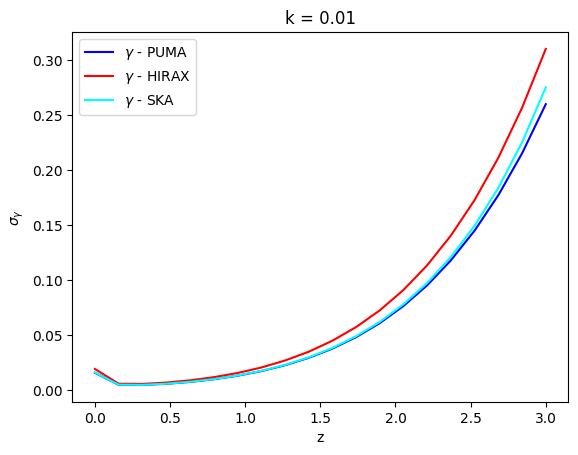

In [20]:
import matplotlib.pyplot as plt

# 1. Extract the X values (the first element of each row)
x_vals = [row[0] for row in store1]

# 2. Extract the Y values from the tuples
y1_vals = [row[1][0] for row in store1] # The first number in the tuple
y2_vals = [row[1][1] for row in store1] # The second number in the tuple

# 2. Extract the Y values from the tuples
y3_vals = [row[1][0] for row in store2] # The first number in the tuple
y4_vals = [row[1][1] for row in store2] # The second number in the tuple

# 2. Extract the Y values from the tuples
y5_vals = [row[1][0] for row in store3] # The first number in the tuple
y6_vals = [row[1][1] for row in store3] # The second number in the tuple

# 3. Plot them explicitly so you can label them
plt.plot(x_vals, y1_vals, label=r'$\gamma$ - PUMA', color='blue')
# plt.loglog(x_vals, y2_vals, label=r'$\beta$ - PUMA', color='orange')

plt.plot(x_vals, y3_vals, label=r'$\gamma$ - HIRAX', color='red')
# plt.loglog(x_vals, y4_vals, label=r'$\beta$ - HIRAX', color='green')

plt.plot(x_vals, y5_vals, label=r'$\gamma$ - SKA', color='cyan')
# plt.loglog(x_vals, y6_vals, label=r'$\beta$ - SKA', color='black')

plt.xlabel('z')
plt.ylabel(r'$\sigma_{\gamma}$')
plt.title("k = 0.01")
plt.legend()
plt.savefig("gamma_full_QS_14.pdf")
plt.show()

In [21]:
z_val = np.linspace(0,3,20)
survey = "PUMA"
k_vals = 0.01

h = 0.6766
Obh2 = 0.02242
Och2 = 0.11933

def OM_m(z):
    OM = (Obh2 + Och2) / h**2
    return (OM * (1+z)**3 / (OM * (1+z)**3 + 1 - OM))

store_gamma = []
store_beta = []
for z_i in z_val:
    bias = Power_HI(k_vals, 0, z_i, survey).bHI(z_i)
    gamma_val = gamma_interpolator(k_vals, z_i)
    f_kz = OM_m(z_i)**gamma_interpolator(k_vals, z_i) # gamma_interpolator(k_test, z_test)
    beta_val = f_kz/bias
    store_gamma.append(gamma_val)
    store_beta.append(beta_val)

# np.savetxt("data_PUMA_full_QS.dat",np.column_stack((x_vals, store_gamma ,y1_vals, store_beta, y2_vals)))
# np.savetxt("data_HIRAX_full_QS.dat",np.column_stack((x_vals, store_gamma, y3_vals, store_beta, y4_vals)))
# np.savetxt("data_SKA_full_QS.dat",np.column_stack((x_vals, store_gamma, y5_vals, store_beta, y6_vals)))

# import numpy as np

# Define your header string once to keep things clean and consistent
my_header = "z_val  gamma_fid  gamma_error  beta_fid  beta_error"

# Pass the header variable into each savetxt function
np.savetxt("data_PUMA_full_QS_1e_14.dat", 
           np.column_stack((x_vals, store_gamma, y1_vals, store_beta, y2_vals)), 
           header=my_header)

np.savetxt("data_HIRAX_full_QS_1e_14.dat", 
           np.column_stack((x_vals, store_gamma, y3_vals, store_beta, y4_vals)), 
           header=my_header)

np.savetxt("data_SKA_full_QS_1e_14.dat", 
           np.column_stack((x_vals, store_gamma, y5_vals, store_beta, y6_vals)), 
           header=my_header)

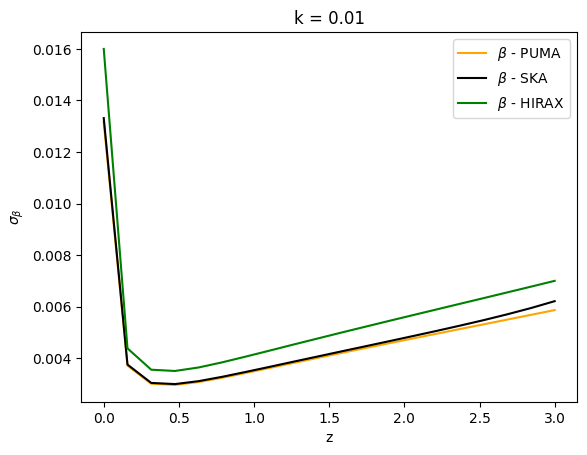

In [22]:
plt.plot(x_vals, y2_vals, label=r'$\beta$ - PUMA', color='orange')
plt.plot(x_vals, y6_vals, label=r'$\beta$ - SKA', color='black')
plt.plot(x_vals, y4_vals, label=r'$\beta$ - HIRAX', color='green')
plt.xlabel('z')
plt.ylabel(r'$\sigma_{\beta}$')
plt.title("k = 0.01")
plt.legend()
plt.savefig("beta_full_QS_1e_14.pdf")
plt.show()

In [23]:
import math
import numpy as np
from astropy.cosmology import Planck18 as cosmo
from scipy import interpolate
from scipy import integrate
import matplotlib.pyplot as plt
import pandas as pd
import scipy.linalg
import sys
from math import floor
import camb

# growth index
def gamma_interpolator(k,z):
    data_D = np.loadtxt("data_full_QS_15.dat")
    # k_value  z_plot  Normalized_Delta  Gamma
    points = np.column_stack((data_D[:,0], data_D[:,1]))
    interpole_gama = interpolate.LinearNDInterpolator(points,data_D[:,3])
    return interpole_gama(k,z)
    
class Power_HI:
    def __init__(self, k, mu, z,survey):
        self.k = k
        self.mu = mu
        self.z = z
        self.h = 0.6766
        self.Obh2 = 0.02242
        self.Och2 = 0.11933
        self.OMh2 = self.Obh2 + self.Och2
        # self.gamma_value = gamma_interpolator(self.k, self.z)
        self.survey = survey
        # self.pk()

    def OHI(self, z):
        return 4e-4*(1+z)**0.6
    
    def bHI(self, z):
        #return 1.333 + 0.1809*z + 0.05302*z**2 - 0.0008822*z**3
        return 0.754 + 0.0877*z + 0.0607*z**2 - 0.00274*z**3

    def Tb_mean(self):
        '''
        output in units of mK
        '''
        return 188.0*self.OHI(self.z)*self.h*(1+self.z)**2*cosmo.H(0).value/cosmo.H(self.z).value

    def P_matter(self, z=0):
        """
        Calculate matter power spectrum for stored k values and given z (default z=0).
        Returns: P(k,z) in Mpc^3
        """
        pars = camb.CAMBparams()
        pars.set_cosmology(
            H0=self.h * 100,
            ombh2=self.Obh2,
            omch2=self.Och2,
            mnu=0.06,
            omk=0,
            tau=0.39
        )
        # pars.InitPower.set_params(As=self.As, ns=self.ns, r=0)
        pars.set_for_lmax(2500, lens_potential_accuracy=0)
        pars.set_accuracy(AccuracyBoost=4)
        pars.set_matter_power(redshifts=[z], kmax=max(np.atleast_1d(self.k)) * 1.1)
        
        results = camb.get_results(pars)
        P_m = results.get_matter_power_interpolator(
            nonlinear=None, hubble_units=False, k_hunit=False
        )
        return P_m.P(z, self.k)

    def f(self):
        OM = (self.Obh2 + self.Och2) / self.h**2
        return (OM * (1+self.z)**3 / (OM * (1+self.z)**3 + 1 - OM))**gamma_interpolator(self.k,self.z)

    def FoG(self):
        SigmaP = 350
        return np.exp(-self.k**2*self.mu**2*SigmaP**2/cosmo.H(self.z).value**2)

    def growth(self, k, z):
        data_D = np.loadtxt("data_full_QS_15.dat")

        points = np.column_stack((data_D[:,0], data_D[:,1]))
        growth_D = interpolate.LinearNDInterpolator(points,data_D[:,2])
        # k_value  z_plot  Normalized_Delta  Gamma
        return growth_D(k,z)

    def P_HI(self):
        beta_val = self.f()/self.bHI(self.z)
        # print("Print beta ",beta_val)
        Powe = self.Tb_mean()**2 * self.FoG() * (1 + self.mu**2*beta_val)**2*self.bHI(self.z)**2*self.growth(self.k, self.z)*self.P_matter()
        # print("Power spectrum of 21cm signal", Powe)
        return Powe

    def PN(self):
        Noise = noise(self.survey)
        PN = Noise.noise_power_Mpc(self.z, self.k, self.mu)
        return PN

    def P_tot(self):
        P_fid = self.P_HI() + self.PN()
        power_noi = self.PN()
        # print("Noise power spectrum of HIRAX for 5 years:", power_noi)
        return P_fid

class Fisher:
    def __init__(self, k, z, dz, kmax, kfg, survey):
        self.k = k
        self.z = z
        self.dz = dz
        self.kmax = kmax
        self.h = 0.6766
        self.Obh2 = 0.02242
        self.Och2 = 0.11933
        self.kfg = kfg
        self.OM = (self.Obh2 + self.Och2) / self.h**2
        self.survey = survey
        self.kfg = kfg
    

    def V(self, z):
        f_sky = Telescope[self.survey]["Sky_fraction"]
        A = 4 * np.pi * f_sky
        v = A / 3 * ((cosmo.comoving_distance(z+self.dz/2).value)**3 - (cosmo.comoving_distance(z-self.dz/2).value)**3)
        return v

    def OM_m(self):
        OM = (self.Obh2 + self.Och2) / self.h**2
        return (OM * (1+self.z)**3 / (OM * (1+self.z)**3 + 1 - OM))

    def alpha(self, z):
        Dd = Telescope[self.survey]["Dish_diameter"]
        return np.arctan(cosmo.H(z).value * cosmo.comoving_distance(z).value * np.sin(0.61 * self.theta_b(z)) / (3e+5 * (1 + z)))

    def theta_b(self, z):
        Dd = Telescope[self.survey]["Dish_diameter"]
        return (1 + z) * 0.21 / Dd  # 0.21 meter wavelength

    def dP_dfi(self,k, mu, z, param):
        bias = Power_HI(k, mu, z, self.survey).bHI(z)
        matter_power = Power_HI(k, mu, z, self.survey).P_matter()
        f_kz = self.OM_m()**gamma_interpolator(k,z) # gamma_interpolator(k_test, z_test)
        beta_val = f_kz/bias
        
        ''' Change this'''
        if param == "gamma":
            # beta_val = self.f()/self.bHI(self.z)
            # f_kz = self.OM_m()**gamma_interpolator(k,z) # gamma_interpolator(k_test, z_test)
            # P_m = Power_HI(k, mu, z, self.survey).P_HI()
            # bias = Power_HI(k, mu, z, self.survey).bHI(z)
            # dP_df = 2*P_m*(bias + mu**2*f_kz)*mu**2*f_kz*np.log(self.OM_m())
            dP_df = 2*(1.0 + mu**2*beta_val)*matter_power*bias*mu**2*f_kz*np.log(self.OM_m())
            return dP_df

        elif param == "beta_par":
            dP_df = 2*(1.0 + mu**2*beta_val)*mu**2*bias**2*matter_power
            return dP_df

        else:
            print("Enter correct NAME")
            
    '''factor 2 from mu integration'''
    def inter(self, k, mu, z, param1, param2):
        integ_val = 2*self.V(z)/(8*np.pi**2)*k**2*self.dP_dfi(k, mu, z, param1)*self.dP_dfi(k, mu, z, param2)/(Power_HI(k, mu, z,self.survey).P_tot())**2
        return integ_val

    # Fisher matrix code
    def fisher_quad(self,param1, param2):
        n_bins = 50

        # print("Fundamental k ",2 * np.pi / (self.V(self.z))**(1/3))
        # For Interference
        if self.survey == "HIRAX" or self.survey == "PUMA":
        
            
            mu_min, mu_max = np.sin(self.alpha(self.z)), 1.0
            k_f = 2 * np.pi / (self.V(self.z))**(1/3)
            k_fg = self.kfg * self.h
            # k_min = lambda mu: np.where(k_f > k_fg, k_f / np.abs(mu), k_fg / np.abs(mu))
            k_min = lambda mu: np.maximum(np.array(k_f)/np.abs(mu) , np.array(k_fg)/np.abs(mu))
            
            k_max = self.kmax

        # For Single Dish
        elif self.survey == "SKA_MID":
        
            
            mu_min, mu_max = 0.0 , 1.0
            k_f = 2 * np.pi / (self.V(self.z))**(1/3)
            k_fg = self.kfg * self.h
            # k_min = lambda mu: np.where(k_f > k_fg, k_f / np.abs(mu), k_fg / np.abs(mu))
            # k_min = lambda mu: np.maximum(np.array(k_f)/np.abs(mu) , np.array(k_fg)/np.abs(mu))
            k_min = lambda mu: np.maximum(np.array(k_f) , np.array(k_fg))/np.abs(mu)
            
            k_max = self.kmax
        else:
            print("Enter correct name")

        mu_bins = np.linspace(mu_min, mu_max, n_bins)
        dmu = mu_bins[1] - mu_bins[0]
        mu_midpoints = (mu_bins[:-1] + mu_bins[1:]) * 0.5
        sum_result = 0

        k_low_vals = k_min(mu_midpoints)
        dk_vals = (k_max - k_low_vals) / (n_bins - 1)

        # 2. Evaluate the integrand for all mu_midpoints at once
        integrand_vals = self.inter(self.k, mu_midpoints, self.z, param1, param2)

        # 3. Multiply and sum over the mu axis
        # We sum over the axis corresponding to mu (adjust axis=0 or axis=-1 depending on 
        # the exact shape self.inter returns when given self.k and mu arrays).
        sum_result += np.sum(integrand_vals * dk_vals * dmu, axis=0)
        return sum_result


def Sigma_g2m(k,z, dz, k_max,kfg, survey):
    # F_ij = np.zeros((2,2))
    # print(F_ij.shape)
    # fisher_quad(self,param1, param2)
    F_ij_1= Fisher(k,z, dz, k_max, kfg, survey).fisher_quad("gamma","gamma")
    # F_ij[0,1] = Fisher(k,z, dz, k_max, kfg, survey).fisher_quad("gamma","beta_par")
    # F_ij[0,0] = Fisher(k,z, dz, k_max, kfg, survey).fisher_quad("gamma","beta_par")
    F_ij_2 = Fisher(k,z, dz, k_max, kfg, survey).fisher_quad("beta_par","beta_par")

    print("Printing the fisher matrix",F_ij_1, F_ij_2)
    # print(F_ij_1, F_ij_2)
    return F_ij_1**(-1/2),F_ij_2**(-1/2)


# Define All the form of f(k)
def fun(k,q):
    kg = 0.05
    return (k/kg)**q
# Calling the function....
z = 1
dz = 0.1
k_val = 0.01

h = 0.6766
ns = 0.9665
k_max = 0.1 * (1 + z)**(2. / (2 + ns)) * h
print("k_max possible:", k_max)
kmax = np.linspace(0.10, k_max, 8)

quadrup = []

# fisher = Fisher(0.1*h,z, dz, k_max, 0.01, "HIRAX")
# print("Survey volume", fisher.V(z))
# fish = fisher.fisher_quad()
# quadrup.append(fish)
# print("Fisher matrix for HIRAX with kfg=0.00 :", fish)
print("printing the sigma using above function",Sigma_g2m(k_val,z, dz, k_max, 0, "HIRAX"))

k_max possible: 0.1079654913116559
Printing the fisher matrix 3491.45179524226 61200.60058213614
printing the sigma using above function (np.float64(0.016923764558126386), np.float64(0.004042240583191103))


In [24]:
# Sigma_g2m(k,z, dz, k_max,kfg, survey)
dz = 0.1
z_val = np.linspace(0,3,20)
survey = "PUMA"
kfg = 0.01
k_vals = 0.01
store1 = []
h = 0.6766
ns = 0.9665

for z_i in z_val:
    k_max = 0.1 * (1 + z_i)**(2. / (2 + ns)) * h
    results = Sigma_g2m(k_vals, z_i, dz, k_max, kfg, survey)
    store1.append([z_i,results])

survey = "HIRAX"
store2 = []
for z_i in z_val:
    k_max = 0.1 * (1 + z_i)**(2. / (2 + ns)) * h
    results = Sigma_g2m(k_vals, z_i, dz, k_max, kfg, survey)
    store2.append([z_i,results])

survey = "SKA_MID"
store3 = []
for z_i in z_val:
    k_max = 0.1 * (1 + z_i)**(2. / (2 + ns)) * h
    results = Sigma_g2m(k_vals, z_i, dz, k_max, kfg, survey)
    store3.append([z_i,results])


Printing the fisher matrix 3821.5146224681057 5805.103368680377
Printing the fisher matrix 36267.28428831973 72427.94194315773
Printing the fisher matrix 38953.68991021931 110056.62850082788
Printing the fisher matrix 27069.907457059933 113318.04575100479
Printing the fisher matrix 16505.476043093822 105111.32633117924
Printing the fisher matrix 9637.66913090374 94555.90295969031
Printing the fisher matrix 5572.085605972066 84505.03285307191
Printing the fisher matrix 3241.157026820396 75775.96232746061
Printing the fisher matrix 1905.4997919448351 68228.15366073913
Printing the fisher matrix 1138.2092330655803 61864.83721976996
Printing the fisher matrix 690.0527998327992 56355.607469545546
Printing the fisher matrix 425.36889150298117 51632.46025914266
Printing the fisher matrix 266.2716608242464 47505.01126480962
Printing the fisher matrix 169.21430245216843 43880.09725084283
Printing the fisher matrix 109.12247731237096 40681.222317273954
Printing the fisher matrix 71.3086656944507

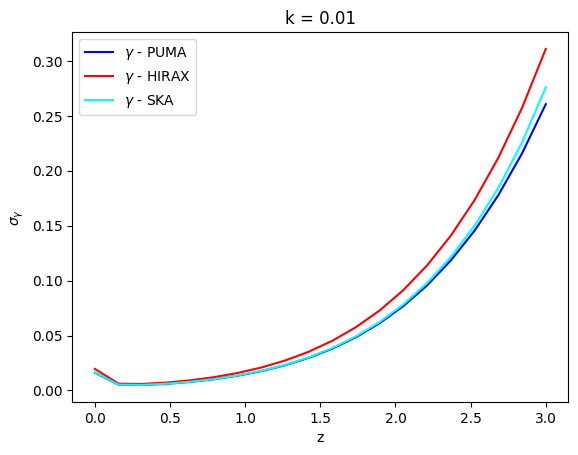

In [25]:
import matplotlib.pyplot as plt

# 1. Extract the X values (the first element of each row)
x_vals = [row[0] for row in store1]

# 2. Extract the Y values from the tuples
y1_vals = [row[1][0] for row in store1] # The first number in the tuple
y2_vals = [row[1][1] for row in store1] # The second number in the tuple

# 2. Extract the Y values from the tuples
y3_vals = [row[1][0] for row in store2] # The first number in the tuple
y4_vals = [row[1][1] for row in store2] # The second number in the tuple

# 2. Extract the Y values from the tuples
y5_vals = [row[1][0] for row in store3] # The first number in the tuple
y6_vals = [row[1][1] for row in store3] # The second number in the tuple

# 3. Plot them explicitly so you can label them
plt.plot(x_vals, y1_vals, label=r'$\gamma$ - PUMA', color='blue')
# plt.loglog(x_vals, y2_vals, label=r'$\beta$ - PUMA', color='orange')

plt.plot(x_vals, y3_vals, label=r'$\gamma$ - HIRAX', color='red')
# plt.loglog(x_vals, y4_vals, label=r'$\beta$ - HIRAX', color='green')

plt.plot(x_vals, y5_vals, label=r'$\gamma$ - SKA', color='cyan')
# plt.loglog(x_vals, y6_vals, label=r'$\beta$ - SKA', color='black')

plt.xlabel('z')
plt.ylabel(r'$\sigma_{\gamma}$')
plt.title("k = 0.01")
plt.legend()
plt.savefig("gamma_full_QS_15.pdf")
plt.show()

In [26]:
z_val = np.linspace(0,3,20)
survey = "PUMA"
k_vals = 0.01

h = 0.6766
Obh2 = 0.02242
Och2 = 0.11933

def OM_m(z):
    OM = (Obh2 + Och2) / h**2
    return (OM * (1+z)**3 / (OM * (1+z)**3 + 1 - OM))

store_gamma = []
store_beta = []
for z_i in z_val:
    bias = Power_HI(k_vals, 0, z_i, survey).bHI(z_i)
    gamma_val = gamma_interpolator(k_vals, z_i)
    f_kz = OM_m(z_i)**gamma_interpolator(k_vals, z_i) # gamma_interpolator(k_test, z_test)
    beta_val = f_kz/bias
    store_gamma.append(gamma_val)
    store_beta.append(beta_val)

# np.savetxt("data_PUMA_full_QS.dat",np.column_stack((x_vals, store_gamma ,y1_vals, store_beta, y2_vals)))
# np.savetxt("data_HIRAX_full_QS.dat",np.column_stack((x_vals, store_gamma, y3_vals, store_beta, y4_vals)))
# np.savetxt("data_SKA_full_QS.dat",np.column_stack((x_vals, store_gamma, y5_vals, store_beta, y6_vals)))

# import numpy as np

# Define your header string once to keep things clean and consistent
my_header = "z_val  gamma_fid  gamma_error  beta_fid  beta_error"

# Pass the header variable into each savetxt function
np.savetxt("data_PUMA_full_QS_1e_15.dat", 
           np.column_stack((x_vals, store_gamma, y1_vals, store_beta, y2_vals)), 
           header=my_header)

np.savetxt("data_HIRAX_full_QS_1e_15.dat", 
           np.column_stack((x_vals, store_gamma, y3_vals, store_beta, y4_vals)), 
           header=my_header)

np.savetxt("data_SKA_full_QS_1e_15.dat", 
           np.column_stack((x_vals, store_gamma, y5_vals, store_beta, y6_vals)), 
           header=my_header)

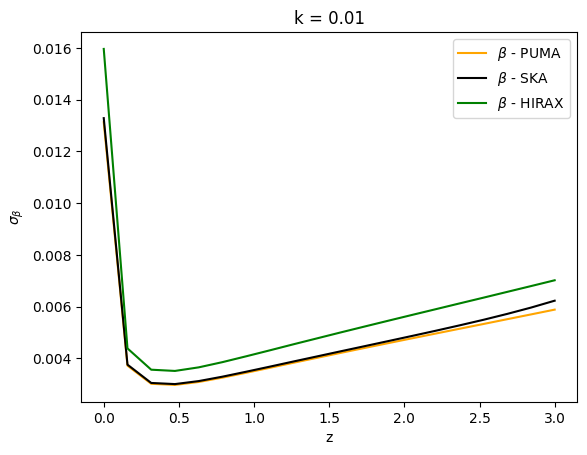

In [27]:
plt.plot(x_vals, y2_vals, label=r'$\beta$ - PUMA', color='orange')
plt.plot(x_vals, y6_vals, label=r'$\beta$ - SKA', color='black')
plt.plot(x_vals, y4_vals, label=r'$\beta$ - HIRAX', color='green')
plt.xlabel('z')
plt.ylabel(r'$\sigma_{\beta}$')
plt.title("k = 0.01")
plt.legend()
plt.savefig("beta_full_QS_1e_15.pdf")
plt.show()

# Exact solution

In [28]:
import numpy as np

# Load file (assuming whitespace separated)
data = np.genfromtxt("fR_exact_k_range1.csv", delimiter=",", skip_header=1)

# Columns
k = data[:, 0]
z = data[:, 1]
delta = data[:, 2]
growth = data[:, 3]

# Filter condition: z < 6
mask = z < 6

filtered_data = data[mask]

# Save new file
np.savetxt("fR_exact_k_range1_filter.dat", filtered_data)

In [29]:
import math
import numpy as np
from astropy.cosmology import Planck18 as cosmo
from scipy import interpolate
from scipy import integrate
import matplotlib.pyplot as plt
import pandas as pd
import scipy.linalg
import sys
from math import floor
import camb

# growth index
def gamma_interpolator(k,z):
    data_D = np.loadtxt("fR_exact_k_range1_filter.dat")
    # k_value  z_plot  Normalized_Delta  Gamma
    points = np.column_stack((data_D[:,0], data_D[:,1]))
    interpole_gama = interpolate.LinearNDInterpolator(points,data_D[:,3])
    return interpole_gama(k,z)
    
class Power_HI:
    def __init__(self, k, mu, z,survey):
        self.k = k
        self.mu = mu
        self.z = z
        self.h = 0.6766
        self.Obh2 = 0.02242
        self.Och2 = 0.11933
        self.OMh2 = self.Obh2 + self.Och2
        # self.gamma_value = gamma_interpolator(self.k, self.z)
        self.survey = survey
        # self.pk()

    def OHI(self, z):
        return 4e-4*(1+z)**0.6
    
    def bHI(self, z):
        #return 1.333 + 0.1809*z + 0.05302*z**2 - 0.0008822*z**3
        return 0.754 + 0.0877*z + 0.0607*z**2 - 0.00274*z**3

    def Tb_mean(self):
        '''
        output in units of mK
        '''
        return 188.0*self.OHI(self.z)*self.h*(1+self.z)**2*cosmo.H(0).value/cosmo.H(self.z).value

    def P_matter(self, z=0):
        """
        Calculate matter power spectrum for stored k values and given z (default z=0).
        Returns: P(k,z) in Mpc^3
        """
        pars = camb.CAMBparams()
        pars.set_cosmology(
            H0=self.h * 100,
            ombh2=self.Obh2,
            omch2=self.Och2,
            mnu=0.06,
            omk=0,
            tau=0.39
        )
        # pars.InitPower.set_params(As=self.As, ns=self.ns, r=0)
        pars.set_for_lmax(2500, lens_potential_accuracy=0)
        pars.set_accuracy(AccuracyBoost=4)
        pars.set_matter_power(redshifts=[z], kmax=max(np.atleast_1d(self.k)) * 1.1)
        
        results = camb.get_results(pars)
        P_m = results.get_matter_power_interpolator(
            nonlinear=None, hubble_units=False, k_hunit=False
        )
        return P_m.P(z, self.k)

    def f(self):
        OM = (self.Obh2 + self.Och2) / self.h**2
        return (OM * (1+self.z)**3 / (OM * (1+self.z)**3 + 1 - OM))**gamma_interpolator(self.k,self.z)

    def FoG(self):
        SigmaP = 350
        return np.exp(-self.k**2*self.mu**2*SigmaP**2/cosmo.H(self.z).value**2)

    def growth(self, k, z):
        data_D = np.loadtxt("fR_exact_k_range1_filter.dat")

        points = np.column_stack((data_D[:,0], data_D[:,1]))
        growth_D = interpolate.LinearNDInterpolator(points,data_D[:,2])
        # k_value  z_plot  Normalized_Delta  Gamma
        return growth_D(k,z)

    def P_HI(self):
        beta_val = self.f()/self.bHI(self.z)
        # print("Print beta ",beta_val)
        Powe = self.Tb_mean()**2 * self.FoG() * (1 + self.mu**2*beta_val)**2*self.bHI(self.z)**2*self.growth(self.k, self.z)*self.P_matter()
        # print("Power spectrum of 21cm signal", Powe)
        return Powe

    def PN(self):
        Noise = noise(self.survey)
        PN = Noise.noise_power_Mpc(self.z, self.k, self.mu)
        return PN

    def P_tot(self):
        P_fid = self.P_HI() + self.PN()
        power_noi = self.PN()
        # print("Noise power spectrum of HIRAX for 5 years:", power_noi)
        return P_fid

class Fisher:
    def __init__(self, k, z, dz, kmax, kfg, survey):
        self.k = k
        self.z = z
        self.dz = dz
        self.kmax = kmax
        self.h = 0.6766
        self.Obh2 = 0.02242
        self.Och2 = 0.11933
        self.kfg = kfg
        self.OM = (self.Obh2 + self.Och2) / self.h**2
        self.survey = survey
        self.kfg = kfg
    

    def V(self, z):
        f_sky = Telescope[self.survey]["Sky_fraction"]
        A = 4 * np.pi * f_sky
        v = A / 3 * ((cosmo.comoving_distance(z+self.dz/2).value)**3 - (cosmo.comoving_distance(z-self.dz/2).value)**3)
        return v

    def OM_m(self):
        OM = (self.Obh2 + self.Och2) / self.h**2
        return (OM * (1+self.z)**3 / (OM * (1+self.z)**3 + 1 - OM))

    def alpha(self, z):
        Dd = Telescope[self.survey]["Dish_diameter"]
        return np.arctan(cosmo.H(z).value * cosmo.comoving_distance(z).value * np.sin(0.61 * self.theta_b(z)) / (3e+5 * (1 + z)))

    def theta_b(self, z):
        Dd = Telescope[self.survey]["Dish_diameter"]
        return (1 + z) * 0.21 / Dd  # 0.21 meter wavelength

    def dP_dfi(self,k, mu, z, param):
        bias = Power_HI(k, mu, z, self.survey).bHI(z)
        matter_power = Power_HI(k, mu, z, self.survey).P_matter()
        f_kz = self.OM_m()**gamma_interpolator(k,z) # gamma_interpolator(k_test, z_test)
        beta_val = f_kz/bias
        
        ''' Change this'''
        if param == "gamma":
            # beta_val = self.f()/self.bHI(self.z)
            # f_kz = self.OM_m()**gamma_interpolator(k,z) # gamma_interpolator(k_test, z_test)
            # P_m = Power_HI(k, mu, z, self.survey).P_HI()
            # bias = Power_HI(k, mu, z, self.survey).bHI(z)
            # dP_df = 2*P_m*(bias + mu**2*f_kz)*mu**2*f_kz*np.log(self.OM_m())
            dP_df = 2*(1.0 + mu**2*beta_val)*matter_power*bias*mu**2*f_kz*np.log(self.OM_m())
            return dP_df

        elif param == "beta_par":
            dP_df = 2*(1.0 + mu**2*beta_val)*mu**2*bias**2*matter_power
            return dP_df

        else:
            print("Enter correct NAME")
            
    '''factor 2 from mu integration'''
    def inter(self, k, mu, z, param1, param2):
        integ_val = 2*self.V(z)/(8*np.pi**2)*k**2*self.dP_dfi(k, mu, z, param1)*self.dP_dfi(k, mu, z, param2)/(Power_HI(k, mu, z,self.survey).P_tot())**2
        return integ_val

    # Fisher matrix code
    def fisher_quad(self,param1, param2):
        n_bins = 50

        # print("Fundamental k ",2 * np.pi / (self.V(self.z))**(1/3))
        # For Interference
        if self.survey == "HIRAX" or self.survey == "PUMA":
        
            
            mu_min, mu_max = np.sin(self.alpha(self.z)), 1.0
            k_f = 2 * np.pi / (self.V(self.z))**(1/3)
            k_fg = self.kfg * self.h
            # k_min = lambda mu: np.where(k_f > k_fg, k_f / np.abs(mu), k_fg / np.abs(mu))
            k_min = lambda mu: np.maximum(np.array(k_f)/np.abs(mu) , np.array(k_fg)/np.abs(mu))
            
            k_max = self.kmax

        # For Single Dish
        elif self.survey == "SKA_MID":
        
            
            mu_min, mu_max = 0.0 , 1.0
            k_f = 2 * np.pi / (self.V(self.z))**(1/3)
            k_fg = self.kfg * self.h
            # k_min = lambda mu: np.where(k_f > k_fg, k_f / np.abs(mu), k_fg / np.abs(mu))
            # k_min = lambda mu: np.maximum(np.array(k_f)/np.abs(mu) , np.array(k_fg)/np.abs(mu))
            k_min = lambda mu: np.maximum(np.array(k_f) , np.array(k_fg))/np.abs(mu)
            
            k_max = self.kmax
        else:
            print("Enter correct name")

        mu_bins = np.linspace(mu_min, mu_max, n_bins)
        dmu = mu_bins[1] - mu_bins[0]
        mu_midpoints = (mu_bins[:-1] + mu_bins[1:]) * 0.5
        sum_result = 0

        k_low_vals = k_min(mu_midpoints)
        dk_vals = (k_max - k_low_vals) / (n_bins - 1)

        # 2. Evaluate the integrand for all mu_midpoints at once
        integrand_vals = self.inter(self.k, mu_midpoints, self.z, param1, param2)

        # 3. Multiply and sum over the mu axis
        # We sum over the axis corresponding to mu (adjust axis=0 or axis=-1 depending on 
        # the exact shape self.inter returns when given self.k and mu arrays).
        sum_result += np.sum(integrand_vals * dk_vals * dmu, axis=0)
        return sum_result


def Sigma_g2m(k,z, dz, k_max,kfg, survey):
    # F_ij = np.zeros((2,2))
    # print(F_ij.shape)
    # fisher_quad(self,param1, param2)
    F_ij_1= Fisher(k,z, dz, k_max, kfg, survey).fisher_quad("gamma","gamma")
    # F_ij[0,1] = Fisher(k,z, dz, k_max, kfg, survey).fisher_quad("gamma","beta_par")
    # F_ij[0,0] = Fisher(k,z, dz, k_max, kfg, survey).fisher_quad("gamma","beta_par")
    F_ij_2 = Fisher(k,z, dz, k_max, kfg, survey).fisher_quad("beta_par","beta_par")

    print("Printing the fisher matrix",F_ij_1, F_ij_2)
    # print(F_ij_1, F_ij_2)
    return F_ij_1**(-1/2),F_ij_2**(-1/2)


# Define All the form of f(k)
def fun(k,q):
    kg = 0.05
    return (k/kg)**q
# Calling the function....
z = 1
dz = 0.1
k_val = 0.01

h = 0.6766
ns = 0.9665
k_max = 0.1 * (1 + z)**(2. / (2 + ns)) * h
print("k_max possible:", k_max)
kmax = np.linspace(0.10, k_max, 8)

quadrup = []

# fisher = Fisher(0.1*h,z, dz, k_max, 0.01, "HIRAX")
# print("Survey volume", fisher.V(z))
# fish = fisher.fisher_quad()
# quadrup.append(fish)
# print("Fisher matrix for HIRAX with kfg=0.00 :", fish)
print("printing the sigma using above function",Sigma_g2m(k_val,z, dz, k_max, 0, "HIRAX"))

k_max possible: 0.1079654913116559
Printing the fisher matrix 3981.115300361493 63789.39752010853
printing the sigma using above function (np.float64(0.015848845148258635), np.float64(0.00395936691586921))


In [ ]:
# k_max possible: 0.1079654913116559
# Printing the fisher matrix 33.6301097484966 588.7030883984695
# printing the sigma using above function (np.float64(0.17243914375553138), np.float64(0.04121467152353904))

In [ ]:
# Sigma_g2m(k,z, dz, k_max,kfg, survey)
dz = 0.1
survey = "PUMA"
z_val = 
kfg = 0.01
k_vals = 0.01
store1 = []
h = 0.6766
ns = 0.9665

for z_i in z_val:
    k_max = 0.1 * (1 + z_i)**(2. / (2 + ns)) * h
    results = Sigma_g2m(k_vals, z_i, dz, k_max, kfg, survey)
    store1.append([z_i,results])

In [30]:
# Sigma_g2m(k,z, dz, k_max,kfg, survey)
dz = 0.1
z_val = np.linspace(0,3,20)
survey = "PUMA"
kfg = 0.01
k_vals = 0.01
store1 = []
h = 0.6766
ns = 0.9665

for z_i in z_val:
    k_max = 0.1 * (1 + z_i)**(2. / (2 + ns)) * h
    results = Sigma_g2m(k_vals, z_i, dz, k_max, kfg, survey)
    store1.append([z_i,results])

survey = "HIRAX"
store2 = []
for z_i in z_val:
    k_max = 0.1 * (1 + z_i)**(2. / (2 + ns)) * h
    results = Sigma_g2m(k_vals, z_i, dz, k_max, kfg, survey)
    store2.append([z_i,results])

survey = "SKA_MID"
store3 = []
for z_i in z_val:
    k_max = 0.1 * (1 + z_i)**(2. / (2 + ns)) * h
    results = Sigma_g2m(k_vals, z_i, dz, k_max, kfg, survey)
    store3.append([z_i,results])


Printing the fisher matrix 4472.438911895975 5371.719878880394
Printing the fisher matrix 42348.96350264045 68460.45785872679
Printing the fisher matrix 45298.001472976735 106232.54287226968
Printing the fisher matrix 31335.84342010405 111688.537124558
Printing the fisher matrix 19017.793730346064 105602.48896605163
Printing the fisher matrix 11058.655211816085 96674.69826225417
Printing the fisher matrix 6359.175005732498 87656.4585590725
Printing the fisher matrix 3682.8872281957256 79587.85349095668
Printing the fisher matrix 2155.742495882782 72382.0021397491
Printing the fisher matrix 1282.5023512324478 66143.34518573867
Printing the fisher matrix 775.3375360339866 60668.08715683762
Printing the fisher matrix 476.4348779884829 55845.38942692062
Printing the fisher matrix 297.6950987307027 51611.502619642
Printing the fisher matrix 188.75523963261548 47808.45567390684
Printing the fisher matrix 121.53820870165141 44435.505438360364
Printing the fisher matrix 79.31297709008328 41381

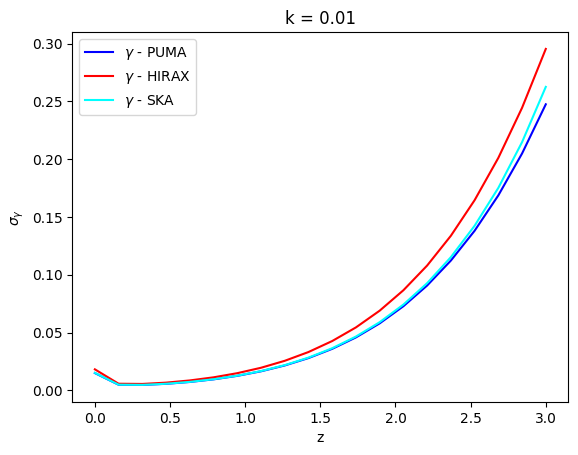

In [31]:
import matplotlib.pyplot as plt

# 1. Extract the X values (the first element of each row)
x_vals = [row[0] for row in store1]

# 2. Extract the Y values from the tuples
y1_vals = [row[1][0] for row in store1] # The first number in the tuple
y2_vals = [row[1][1] for row in store1] # The second number in the tuple

# 2. Extract the Y values from the tuples
y3_vals = [row[1][0] for row in store2] # The first number in the tuple
y4_vals = [row[1][1] for row in store2] # The second number in the tuple

# 2. Extract the Y values from the tuples
y5_vals = [row[1][0] for row in store3] # The first number in the tuple
y6_vals = [row[1][1] for row in store3] # The second number in the tuple

# 3. Plot them explicitly so you can label them
plt.plot(x_vals, y1_vals, label=r'$\gamma$ - PUMA', color='blue')
# plt.loglog(x_vals, y2_vals, label=r'$\beta$ - PUMA', color='orange')

plt.plot(x_vals, y3_vals, label=r'$\gamma$ - HIRAX', color='red')
# plt.loglog(x_vals, y4_vals, label=r'$\beta$ - HIRAX', color='green')

plt.plot(x_vals, y5_vals, label=r'$\gamma$ - SKA', color='cyan')
# plt.loglog(x_vals, y6_vals, label=r'$\beta$ - SKA', color='black')

plt.xlabel('z')
plt.ylabel(r'$\sigma_{\gamma}$')
plt.title("k = 0.01")
plt.legend()
plt.savefig("gamma_Exact_12.pdf")
plt.show()

In [32]:
z_val = np.linspace(0,3,20)
survey = "PUMA"
k_vals = 0.01

h = 0.6766
Obh2 = 0.02242
Och2 = 0.11933

def OM_m(z):
    OM = (Obh2 + Och2) / h**2
    return (OM * (1+z)**3 / (OM * (1+z)**3 + 1 - OM))

store_gamma = []
store_beta = []
for z_i in z_val:
    bias = Power_HI(k_vals, 0, z_i, survey).bHI(z_i)
    gamma_val = gamma_interpolator(k_vals, z_i)
    f_kz = OM_m(z_i)**gamma_interpolator(k_vals, z_i) # gamma_interpolator(k_test, z_test)
    beta_val = f_kz/bias
    store_gamma.append(gamma_val)
    store_beta.append(beta_val)

# np.savetxt("data_PUMA_full_QS.dat",np.column_stack((x_vals, store_gamma ,y1_vals, store_beta, y2_vals)))
# np.savetxt("data_HIRAX_full_QS.dat",np.column_stack((x_vals, store_gamma, y3_vals, store_beta, y4_vals)))
# np.savetxt("data_SKA_full_QS.dat",np.column_stack((x_vals, store_gamma, y5_vals, store_beta, y6_vals)))

# import numpy as np

# Define your header string once to keep things clean and consistent
my_header = "z_val  gamma_fid  gamma_error  beta_fid  beta_error"

# Pass the header variable into each savetxt function
np.savetxt("data_PUMA_Exact_12.dat", 
           np.column_stack((x_vals, store_gamma, y1_vals, store_beta, y2_vals)), 
           header=my_header)

np.savetxt("data_HIRAX_Exact_12.dat", 
           np.column_stack((x_vals, store_gamma, y3_vals, store_beta, y4_vals)), 
           header=my_header)

np.savetxt("data_SKA_Exact_12.dat", 
           np.column_stack((x_vals, store_gamma, y5_vals, store_beta, y6_vals)), 
           header=my_header)

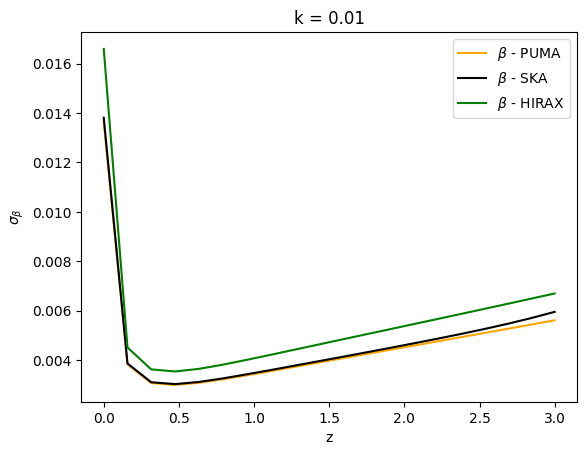

In [33]:
plt.plot(x_vals, y2_vals, label=r'$\beta$ - PUMA', color='orange')
plt.plot(x_vals, y6_vals, label=r'$\beta$ - SKA', color='black')
plt.plot(x_vals, y4_vals, label=r'$\beta$ - HIRAX', color='green')
plt.xlabel('z')
plt.ylabel(r'$\sigma_{\beta}$')
plt.title("k = 0.01")
plt.legend()
plt.savefig("beta_Exact_12.pdf")
plt.show()

In [6]:
import numpy as np

# Load file (assuming whitespace separated)
data = np.genfromtxt("fR_exact_k_range2.csv", delimiter=",", skip_header=1)

# Columns
k = data[:, 0]
z = data[:, 1]
delta = data[:, 2]
growth = data[:, 3]

# Filter condition: z < 6
mask = z < 6

filtered_data = data[mask]

# Save new file
np.savetxt("fR_exact_k_range2_filter.dat", filtered_data)

# Exact with $x_{init} = 10^{-13}$

In [34]:
import math
import numpy as np
from astropy.cosmology import Planck18 as cosmo
from scipy import interpolate
from scipy import integrate
import matplotlib.pyplot as plt
import pandas as pd
import scipy.linalg
import sys
from math import floor
import camb

# growth index
def gamma_interpolator(k,z):
    data_D = np.loadtxt("fR_exact_k_range2_filter.dat")
    # k_value  z_plot  Normalized_Delta  Gamma
    points = np.column_stack((data_D[:,0], data_D[:,1]))
    interpole_gama = interpolate.LinearNDInterpolator(points,data_D[:,3])
    return interpole_gama(k,z)
    
class Power_HI:
    def __init__(self, k, mu, z,survey):
        self.k = k
        self.mu = mu
        self.z = z
        self.h = 0.6766
        self.Obh2 = 0.02242
        self.Och2 = 0.11933
        self.OMh2 = self.Obh2 + self.Och2
        # self.gamma_value = gamma_interpolator(self.k, self.z)
        self.survey = survey
        # self.pk()

    def OHI(self, z):
        return 4e-4*(1+z)**0.6
    
    def bHI(self, z):
        #return 1.333 + 0.1809*z + 0.05302*z**2 - 0.0008822*z**3
        return 0.754 + 0.0877*z + 0.0607*z**2 - 0.00274*z**3

    def Tb_mean(self):
        '''
        output in units of mK
        '''
        return 188.0*self.OHI(self.z)*self.h*(1+self.z)**2*cosmo.H(0).value/cosmo.H(self.z).value

    def P_matter(self, z=0):
        """
        Calculate matter power spectrum for stored k values and given z (default z=0).
        Returns: P(k,z) in Mpc^3
        """
        pars = camb.CAMBparams()
        pars.set_cosmology(
            H0=self.h * 100,
            ombh2=self.Obh2,
            omch2=self.Och2,
            mnu=0.06,
            omk=0,
            tau=0.39
        )
        # pars.InitPower.set_params(As=self.As, ns=self.ns, r=0)
        pars.set_for_lmax(2500, lens_potential_accuracy=0)
        pars.set_accuracy(AccuracyBoost=4)
        pars.set_matter_power(redshifts=[z], kmax=max(np.atleast_1d(self.k)) * 1.1)
        
        results = camb.get_results(pars)
        P_m = results.get_matter_power_interpolator(
            nonlinear=None, hubble_units=False, k_hunit=False
        )
        return P_m.P(z, self.k)

    def f(self):
        OM = (self.Obh2 + self.Och2) / self.h**2
        return (OM * (1+self.z)**3 / (OM * (1+self.z)**3 + 1 - OM))**gamma_interpolator(self.k,self.z)

    def FoG(self):
        SigmaP = 350
        return np.exp(-self.k**2*self.mu**2*SigmaP**2/cosmo.H(self.z).value**2)

    def growth(self, k, z):
        data_D = np.loadtxt("fR_exact_k_range2_filter.dat")

        points = np.column_stack((data_D[:,0], data_D[:,1]))
        growth_D = interpolate.LinearNDInterpolator(points,data_D[:,2])
        # k_value  z_plot  Normalized_Delta  Gamma
        return growth_D(k,z)

    def P_HI(self):
        beta_val = self.f()/self.bHI(self.z)
        # print("Print beta ",beta_val)
        Powe = self.Tb_mean()**2 * self.FoG() * (1 + self.mu**2*beta_val)**2*self.bHI(self.z)**2*self.growth(self.k, self.z)*self.P_matter()
        # print("Power spectrum of 21cm signal", Powe)
        return Powe

    def PN(self):
        Noise = noise(self.survey)
        PN = Noise.noise_power_Mpc(self.z, self.k, self.mu)
        return PN

    def P_tot(self):
        P_fid = self.P_HI() + self.PN()
        power_noi = self.PN()
        # print("Noise power spectrum of HIRAX for 5 years:", power_noi)
        return P_fid

class Fisher:
    def __init__(self, k, z, dz, kmax, kfg, survey):
        self.k = k
        self.z = z
        self.dz = dz
        self.kmax = kmax
        self.h = 0.6766
        self.Obh2 = 0.02242
        self.Och2 = 0.11933
        self.kfg = kfg
        self.OM = (self.Obh2 + self.Och2) / self.h**2
        self.survey = survey
        self.kfg = kfg
    

    def V(self, z):
        f_sky = Telescope[self.survey]["Sky_fraction"]
        A = 4 * np.pi * f_sky
        v = A / 3 * ((cosmo.comoving_distance(z+self.dz/2).value)**3 - (cosmo.comoving_distance(z-self.dz/2).value)**3)
        return v

    def OM_m(self):
        OM = (self.Obh2 + self.Och2) / self.h**2
        return (OM * (1+self.z)**3 / (OM * (1+self.z)**3 + 1 - OM))

    def alpha(self, z):
        Dd = Telescope[self.survey]["Dish_diameter"]
        return np.arctan(cosmo.H(z).value * cosmo.comoving_distance(z).value * np.sin(0.61 * self.theta_b(z)) / (3e+5 * (1 + z)))

    def theta_b(self, z):
        Dd = Telescope[self.survey]["Dish_diameter"]
        return (1 + z) * 0.21 / Dd  # 0.21 meter wavelength

    def dP_dfi(self,k, mu, z, param):
        bias = Power_HI(k, mu, z, self.survey).bHI(z)
        matter_power = Power_HI(k, mu, z, self.survey).P_matter()
        f_kz = self.OM_m()**gamma_interpolator(k,z) # gamma_interpolator(k_test, z_test)
        beta_val = f_kz/bias
        
        ''' Change this'''
        if param == "gamma":
            # beta_val = self.f()/self.bHI(self.z)
            # f_kz = self.OM_m()**gamma_interpolator(k,z) # gamma_interpolator(k_test, z_test)
            # P_m = Power_HI(k, mu, z, self.survey).P_HI()
            # bias = Power_HI(k, mu, z, self.survey).bHI(z)
            # dP_df = 2*P_m*(bias + mu**2*f_kz)*mu**2*f_kz*np.log(self.OM_m())
            dP_df = 2*(1.0 + mu**2*beta_val)*matter_power*bias*mu**2*f_kz*np.log(self.OM_m())
            return dP_df

        elif param == "beta_par":
            dP_df = 2*(1.0 + mu**2*beta_val)*mu**2*bias**2*matter_power
            return dP_df

        else:
            print("Enter correct NAME")
            
    '''factor 2 from mu integration'''
    def inter(self, k, mu, z, param1, param2):
        integ_val = 2*self.V(z)/(8*np.pi**2)*k**2*self.dP_dfi(k, mu, z, param1)*self.dP_dfi(k, mu, z, param2)/(Power_HI(k, mu, z,self.survey).P_tot())**2
        return integ_val

    # Fisher matrix code
    def fisher_quad(self,param1, param2):
        n_bins = 50

        # print("Fundamental k ",2 * np.pi / (self.V(self.z))**(1/3))
        # For Interference
        if self.survey == "HIRAX" or self.survey == "PUMA":
        
            
            mu_min, mu_max = np.sin(self.alpha(self.z)), 1.0
            k_f = 2 * np.pi / (self.V(self.z))**(1/3)
            k_fg = self.kfg * self.h
            # k_min = lambda mu: np.where(k_f > k_fg, k_f / np.abs(mu), k_fg / np.abs(mu))
            k_min = lambda mu: np.maximum(np.array(k_f)/np.abs(mu) , np.array(k_fg)/np.abs(mu))
            
            k_max = self.kmax

        # For Single Dish
        elif self.survey == "SKA_MID":
        
            
            mu_min, mu_max = 0.0 , 1.0
            k_f = 2 * np.pi / (self.V(self.z))**(1/3)
            k_fg = self.kfg * self.h
            # k_min = lambda mu: np.where(k_f > k_fg, k_f / np.abs(mu), k_fg / np.abs(mu))
            # k_min = lambda mu: np.maximum(np.array(k_f)/np.abs(mu) , np.array(k_fg)/np.abs(mu))
            k_min = lambda mu: np.maximum(np.array(k_f) , np.array(k_fg))/np.abs(mu)
            
            k_max = self.kmax
        else:
            print("Enter correct name")

        mu_bins = np.linspace(mu_min, mu_max, n_bins)
        dmu = mu_bins[1] - mu_bins[0]
        mu_midpoints = (mu_bins[:-1] + mu_bins[1:]) * 0.5
        sum_result = 0

        k_low_vals = k_min(mu_midpoints)
        dk_vals = (k_max - k_low_vals) / (n_bins - 1)

        # 2. Evaluate the integrand for all mu_midpoints at once
        integrand_vals = self.inter(self.k, mu_midpoints, self.z, param1, param2)
        # print("Print the integrand values ", integrand_vals)
        # 3. Multiply and sum over the mu axis
        # We sum over the axis corresponding to mu (adjust axis=0 or axis=-1 depending on 
        # the exact shape self.inter returns when given self.k and mu arrays).
        sum_result += np.sum(integrand_vals * dk_vals * dmu, axis=0)
        return sum_result


def Sigma_g2m(k,z, dz, k_max,kfg, survey):
    # F_ij = np.zeros((2,2))
    # print(F_ij.shape)
    # fisher_quad(self,param1, param2)
    F_ij_1= Fisher(k,z, dz, k_max, kfg, survey).fisher_quad("gamma","gamma")
    # F_ij[0,1] = Fisher(k,z, dz, k_max, kfg, survey).fisher_quad("gamma","beta_par")
    # F_ij[0,0] = Fisher(k,z, dz, k_max, kfg, survey).fisher_quad("gamma","beta_par")
    F_ij_2 = Fisher(k,z, dz, k_max, kfg, survey).fisher_quad("beta_par","beta_par")

    print("Printing the fisher matrix",F_ij_1, F_ij_2)
    # print(F_ij_1, F_ij_2)
    return F_ij_1**(-1/2),F_ij_2**(-1/2)


# Define All the form of f(k)
def fun(k,q):
    kg = 0.05
    return (k/kg)**q
# Calling the function....
z = 1
dz = 0.1
k_val = 0.01

h = 0.6766
ns = 0.9665
k_max = 0.1 * (1 + z)**(2. / (2 + ns)) * h
print("k_max possible:", k_max)
kmax = np.linspace(0.10, k_max, 8)

quadrup = []

# fisher = Fisher(0.1*h,z, dz, k_max, 0.01, "HIRAX")
# print("Survey volume", fisher.V(z))
# fish = fisher.fisher_quad()
# quadrup.append(fish)
# print("Fisher matrix for HIRAX with kfg=0.00 :", fish)
print("printing the sigma using above function",Sigma_g2m(k_val,z, dz, k_max, 0, "PUMA"))

k_max possible: 0.1079654913116559
Printing the fisher matrix 5077.055076608108 87240.26273771511
printing the sigma using above function (np.float64(0.014034406859676794), np.float64(0.0033856457727817436))


In [35]:
# Sigma_g2m(k,z, dz, k_max,kfg, survey)
dz = 0.1
z_val = np.linspace(0,3,20)
survey = "PUMA"
kfg = 0.01
k_vals = 0.01
store1 = []
h = 0.6766
ns = 0.9665

for z_i in z_val:
    k_max = 0.1 * (1 + z_i)**(2. / (2 + ns)) * h
    results = Sigma_g2m(k_vals, z_i, dz, k_max, kfg, survey)
    store1.append([z_i,results])

survey = "HIRAX"
store2 = []
for z_i in z_val:
    k_max = 0.1 * (1 + z_i)**(2. / (2 + ns)) * h
    results = Sigma_g2m(k_vals, z_i, dz, k_max, kfg, survey)
    store2.append([z_i,results])

survey = "SKA_MID"
store3 = []
for z_i in z_val:
    k_max = 0.1 * (1 + z_i)**(2. / (2 + ns)) * h
    results = Sigma_g2m(k_vals, z_i, dz, k_max, kfg, survey)
    store3.append([z_i,results])


Printing the fisher matrix 4119.328230793365 5600.012793041995
Printing the fisher matrix 38673.248348361725 70742.94994049998
Printing the fisher matrix 41057.28222491342 108529.37572276714
Printing the fisher matrix 28314.789052283108 112693.92682000391
Printing the fisher matrix 17161.676156782414 105198.58319437451
Printing the fisher matrix 9980.087299686 95145.24923555568
Printing the fisher matrix 5749.666371661149 85308.83905790953
Printing the fisher matrix 3335.6502173133695 76708.10659447874
Printing the fisher matrix 1957.5387096203358 69202.55743123642
Printing the fisher matrix 1166.9440182348253 62809.24129734591
Printing the fisher matrix 706.9653702686505 57295.80533739421
Printing the fisher matrix 435.22704431671536 52513.126018089526
Printing the fisher matrix 272.41879969762863 48366.74080555398
Printing the fisher matrix 172.98648704691723 44683.42254299257
Printing the fisher matrix 111.50436509941976 41436.71233077293
Printing the fisher matrix 72.8440058954397 

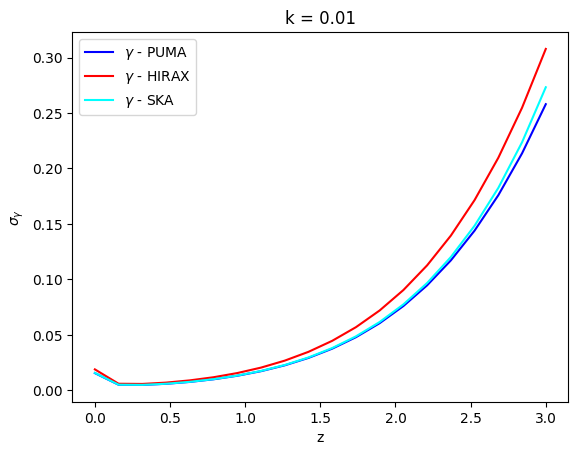

In [36]:
import matplotlib.pyplot as plt

# 1. Extract the X values (the first element of each row)
x_vals = [row[0] for row in store1]

# 2. Extract the Y values from the tuples
y1_vals = [row[1][0] for row in store1] # The first number in the tuple
y2_vals = [row[1][1] for row in store1] # The second number in the tuple

# 2. Extract the Y values from the tuples
y3_vals = [row[1][0] for row in store2] # The first number in the tuple
y4_vals = [row[1][1] for row in store2] # The second number in the tuple

# 2. Extract the Y values from the tuples
y5_vals = [row[1][0] for row in store3] # The first number in the tuple
y6_vals = [row[1][1] for row in store3] # The second number in the tuple

# 3. Plot them explicitly so you can label them
plt.plot(x_vals, y1_vals, label=r'$\gamma$ - PUMA', color='blue')
# plt.loglog(x_vals, y2_vals, label=r'$\beta$ - PUMA', color='orange')

plt.plot(x_vals, y3_vals, label=r'$\gamma$ - HIRAX', color='red')
# plt.loglog(x_vals, y4_vals, label=r'$\beta$ - HIRAX', color='green')

plt.plot(x_vals, y5_vals, label=r'$\gamma$ - SKA', color='cyan')
# plt.loglog(x_vals, y6_vals, label=r'$\beta$ - SKA', color='black')

plt.xlabel('z')
plt.ylabel(r'$\sigma_{\gamma}$')
plt.title("k = 0.01")
plt.legend()
plt.savefig("gamma_Exact_1e_13.pdf")
plt.show()

In [37]:
z_val = np.linspace(0,3,20)
survey = "PUMA"
k_vals = 0.01

h = 0.6766
Obh2 = 0.02242
Och2 = 0.11933

def OM_m(z):
    OM = (Obh2 + Och2) / h**2
    return (OM * (1+z)**3 / (OM * (1+z)**3 + 1 - OM))

store_gamma = []
store_beta = []
for z_i in z_val:
    bias = Power_HI(k_vals, 0, z_i, survey).bHI(z_i)
    gamma_val = gamma_interpolator(k_vals, z_i)
    f_kz = OM_m(z_i)**gamma_interpolator(k_vals, z_i) # gamma_interpolator(k_test, z_test)
    beta_val = f_kz/bias
    store_gamma.append(gamma_val)
    store_beta.append(beta_val)

# np.savetxt("data_PUMA_full_QS.dat",np.column_stack((x_vals, store_gamma ,y1_vals, store_beta, y2_vals)))
# np.savetxt("data_HIRAX_full_QS.dat",np.column_stack((x_vals, store_gamma, y3_vals, store_beta, y4_vals)))
# np.savetxt("data_SKA_full_QS.dat",np.column_stack((x_vals, store_gamma, y5_vals, store_beta, y6_vals)))

# import numpy as np

# Define your header string once to keep things clean and consistent
my_header = "z_val  gamma_fid  gamma_error  beta_fid  beta_error"

# Pass the header variable into each savetxt function
np.savetxt("data_PUMA_Exact_1e_13.dat", 
           np.column_stack((x_vals, store_gamma, y1_vals, store_beta, y2_vals)), 
           header=my_header)

np.savetxt("data_HIRAX_Exact_1e_13.dat", 
           np.column_stack((x_vals, store_gamma, y3_vals, store_beta, y4_vals)), 
           header=my_header)

np.savetxt("data_SKA_Exact_1e_13.dat", 
           np.column_stack((x_vals, store_gamma, y5_vals, store_beta, y6_vals)), 
           header=my_header)

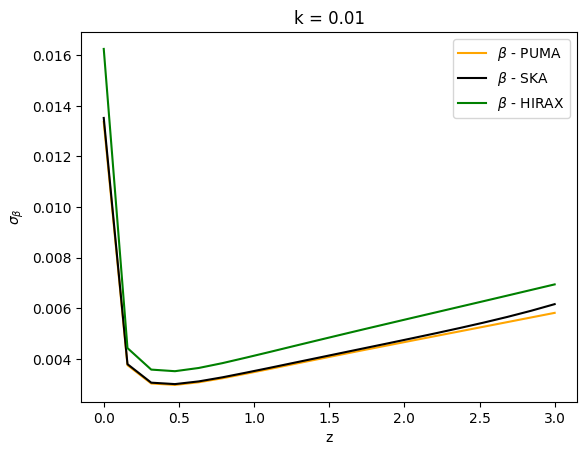

In [38]:
plt.plot(x_vals, y2_vals, label=r'$\beta$ - PUMA', color='orange')
plt.plot(x_vals, y6_vals, label=r'$\beta$ - SKA', color='black')
plt.plot(x_vals, y4_vals, label=r'$\beta$ - HIRAX', color='green')
plt.xlabel('z')
plt.ylabel(r'$\sigma_{\beta}$')
plt.title("k = 0.01")
plt.legend()
plt.savefig("beta_Exact_1e_13.pdf")
plt.show()

In [4]:
import numpy as np

# Load file (assuming whitespace separated)
data = np.genfromtxt("fR_exact_k_range14.csv", delimiter=",", skip_header=1)

# Columns
k = data[:, 0]
z = data[:, 1]
delta = data[:, 2]
growth = data[:, 3]

# Filter condition: z < 6
mask = z < 6

filtered_data = data[mask]

# Save new file
np.savetxt("fR_exact_k_range14_filter.dat", filtered_data)

In [5]:
import math
import numpy as np
from astropy.cosmology import Planck18 as cosmo
from scipy import interpolate
from scipy import integrate
import matplotlib.pyplot as plt
import pandas as pd
import scipy.linalg
import sys
from math import floor
import camb

# growth index
def gamma_interpolator(k,z):
    data_D = np.loadtxt("fR_exact_k_range14_filter.dat")
    # k_value  z_plot  Normalized_Delta  Gamma
    points = np.column_stack((data_D[:,0], data_D[:,1]))
    interpole_gama = interpolate.LinearNDInterpolator(points,data_D[:,3])
    return interpole_gama(k,z)
    
class Power_HI:
    def __init__(self, k, mu, z,survey):
        self.k = k
        self.mu = mu
        self.z = z
        self.h = 0.6766
        self.Obh2 = 0.02242
        self.Och2 = 0.11933
        self.OMh2 = self.Obh2 + self.Och2
        # self.gamma_value = gamma_interpolator(self.k, self.z)
        self.survey = survey
        # self.pk()

    def OHI(self, z):
        return 4e-4*(1+z)**0.6
    
    def bHI(self, z):
        #return 1.333 + 0.1809*z + 0.05302*z**2 - 0.0008822*z**3
        return 0.754 + 0.0877*z + 0.0607*z**2 - 0.00274*z**3

    def Tb_mean(self):
        '''
        output in units of mK
        '''
        return 188.0*self.OHI(self.z)*self.h*(1+self.z)**2*cosmo.H(0).value/cosmo.H(self.z).value

    def P_matter(self, z=0):
        """
        Calculate matter power spectrum for stored k values and given z (default z=0).
        Returns: P(k,z) in Mpc^3
        """
        pars = camb.CAMBparams()
        pars.set_cosmology(
            H0=self.h * 100,
            ombh2=self.Obh2,
            omch2=self.Och2,
            mnu=0.06,
            omk=0,
            tau=0.39
        )
        # pars.InitPower.set_params(As=self.As, ns=self.ns, r=0)
        pars.set_for_lmax(2500, lens_potential_accuracy=0)
        pars.set_accuracy(AccuracyBoost=4)
        pars.set_matter_power(redshifts=[z], kmax=max(np.atleast_1d(self.k)) * 1.1)
        
        results = camb.get_results(pars)
        P_m = results.get_matter_power_interpolator(
            nonlinear=None, hubble_units=False, k_hunit=False
        )
        return P_m.P(z, self.k)

    def f(self):
        OM = (self.Obh2 + self.Och2) / self.h**2
        return (OM * (1+self.z)**3 / (OM * (1+self.z)**3 + 1 - OM))**gamma_interpolator(self.k,self.z)

    def FoG(self):
        SigmaP = 350
        return np.exp(-self.k**2*self.mu**2*SigmaP**2/cosmo.H(self.z).value**2)

    def growth(self, k, z):
        data_D = np.loadtxt("fR_exact_k_range14_filter.dat")

        points = np.column_stack((data_D[:,0], data_D[:,1]))
        growth_D = interpolate.LinearNDInterpolator(points,data_D[:,2])
        # k_value  z_plot  Normalized_Delta  Gamma
        return growth_D(k,z)

    def P_HI(self):
        beta_val = self.f()/self.bHI(self.z)
        # print("Print beta ",beta_val)
        Powe = self.Tb_mean()**2 * self.FoG() * (1 + self.mu**2*beta_val)**2*self.bHI(self.z)**2*self.growth(self.k, self.z)*self.P_matter()
        # print("Power spectrum of 21cm signal", Powe)
        return Powe

    def PN(self):
        Noise = noise(self.survey)
        PN = Noise.noise_power_Mpc(self.z, self.k, self.mu)
        return PN

    def P_tot(self):
        P_fid = self.P_HI() + self.PN()
        power_noi = self.PN()
        # print("Noise power spectrum of HIRAX for 5 years:", power_noi)
        return P_fid

class Fisher:
    def __init__(self, k, z, dz, kmax, kfg, survey):
        self.k = k
        self.z = z
        self.dz = dz
        self.kmax = kmax
        self.h = 0.6766
        self.Obh2 = 0.02242
        self.Och2 = 0.11933
        self.kfg = kfg
        self.OM = (self.Obh2 + self.Och2) / self.h**2
        self.survey = survey
        self.kfg = kfg
    

    def V(self, z):
        f_sky = Telescope[self.survey]["Sky_fraction"]
        A = 4 * np.pi * f_sky
        v = A / 3 * ((cosmo.comoving_distance(z+self.dz/2).value)**3 - (cosmo.comoving_distance(z-self.dz/2).value)**3)
        return v

    def OM_m(self):
        OM = (self.Obh2 + self.Och2) / self.h**2
        return (OM * (1+self.z)**3 / (OM * (1+self.z)**3 + 1 - OM))

    def alpha(self, z):
        Dd = Telescope[self.survey]["Dish_diameter"]
        return np.arctan(cosmo.H(z).value * cosmo.comoving_distance(z).value * np.sin(0.61 * self.theta_b(z)) / (3e+5 * (1 + z)))

    def theta_b(self, z):
        Dd = Telescope[self.survey]["Dish_diameter"]
        return (1 + z) * 0.21 / Dd  # 0.21 meter wavelength

    def dP_dfi(self,k, mu, z, param):
        bias = Power_HI(k, mu, z, self.survey).bHI(z)
        matter_power = Power_HI(k, mu, z, self.survey).P_matter()
        f_kz = self.OM_m()**gamma_interpolator(k,z) # gamma_interpolator(k_test, z_test)
        beta_val = f_kz/bias
        
        ''' Change this'''
        if param == "gamma":
            # beta_val = self.f()/self.bHI(self.z)
            # f_kz = self.OM_m()**gamma_interpolator(k,z) # gamma_interpolator(k_test, z_test)
            # P_m = Power_HI(k, mu, z, self.survey).P_HI()
            # bias = Power_HI(k, mu, z, self.survey).bHI(z)
            # dP_df = 2*P_m*(bias + mu**2*f_kz)*mu**2*f_kz*np.log(self.OM_m())
            dP_df = 2*(1.0 + mu**2*beta_val)*matter_power*bias*mu**2*f_kz*np.log(self.OM_m())
            return dP_df

        elif param == "beta_par":
            dP_df = 2*(1.0 + mu**2*beta_val)*mu**2*bias**2*matter_power
            return dP_df

        else:
            print("Enter correct NAME")
            
    '''factor 2 from mu integration'''
    def inter(self, k, mu, z, param1, param2):
        integ_val = 2*self.V(z)/(8*np.pi**2)*k**2*self.dP_dfi(k, mu, z, param1)*self.dP_dfi(k, mu, z, param2)/(Power_HI(k, mu, z,self.survey).P_tot())**2
        return integ_val

    # Fisher matrix code
    def fisher_quad(self,param1, param2):
        n_bins = 50

        # print("Fundamental k ",2 * np.pi / (self.V(self.z))**(1/3))
        # For Interference
        if self.survey == "HIRAX" or self.survey == "PUMA":
        
            
            mu_min, mu_max = np.sin(self.alpha(self.z)), 1.0
            k_f = 2 * np.pi / (self.V(self.z))**(1/3)
            k_fg = self.kfg * self.h
            # k_min = lambda mu: np.where(k_f > k_fg, k_f / np.abs(mu), k_fg / np.abs(mu))
            k_min = lambda mu: np.maximum(np.array(k_f)/np.abs(mu) , np.array(k_fg)/np.abs(mu))
            
            k_max = self.kmax

        # For Single Dish
        elif self.survey == "SKA_MID":
        
            
            mu_min, mu_max = 0.0 , 1.0
            k_f = 2 * np.pi / (self.V(self.z))**(1/3)
            k_fg = self.kfg * self.h
            # k_min = lambda mu: np.where(k_f > k_fg, k_f / np.abs(mu), k_fg / np.abs(mu))
            # k_min = lambda mu: np.maximum(np.array(k_f)/np.abs(mu) , np.array(k_fg)/np.abs(mu))
            k_min = lambda mu: np.maximum(np.array(k_f) , np.array(k_fg))/np.abs(mu)
            
            k_max = self.kmax
        else:
            print("Enter correct name")

        mu_bins = np.linspace(mu_min, mu_max, n_bins)
        dmu = mu_bins[1] - mu_bins[0]
        mu_midpoints = (mu_bins[:-1] + mu_bins[1:]) * 0.5
        sum_result = 0

        k_low_vals = k_min(mu_midpoints)
        dk_vals = (k_max - k_low_vals) / (n_bins - 1)

        # 2. Evaluate the integrand for all mu_midpoints at once
        integrand_vals = self.inter(self.k, mu_midpoints, self.z, param1, param2)
        # print("Print the integrand values ", integrand_vals)
        # 3. Multiply and sum over the mu axis
        # We sum over the axis corresponding to mu (adjust axis=0 or axis=-1 depending on 
        # the exact shape self.inter returns when given self.k and mu arrays).
        sum_result += np.sum(integrand_vals * dk_vals * dmu, axis=0)
        return sum_result


def Sigma_g2m(k,z, dz, k_max,kfg, survey):
    # F_ij = np.zeros((2,2))
    # print(F_ij.shape)
    # fisher_quad(self,param1, param2)
    F_ij_1= Fisher(k,z, dz, k_max, kfg, survey).fisher_quad("gamma","gamma")
    # F_ij[0,1] = Fisher(k,z, dz, k_max, kfg, survey).fisher_quad("gamma","beta_par")
    # F_ij[0,0] = Fisher(k,z, dz, k_max, kfg, survey).fisher_quad("gamma","beta_par")
    F_ij_2 = Fisher(k,z, dz, k_max, kfg, survey).fisher_quad("beta_par","beta_par")

    print("Printing the fisher matrix",F_ij_1, F_ij_2)
    # print(F_ij_1, F_ij_2)
    return F_ij_1**(-1/2),F_ij_2**(-1/2)


# Define All the form of f(k)
def fun(k,q):
    kg = 0.05
    return (k/kg)**q
# Calling the function....
z = 1
dz = 0.1
k_val = 0.01

h = 0.6766
ns = 0.9665
k_max = 0.1 * (1 + z)**(2. / (2 + ns)) * h
print("k_max possible:", k_max)
kmax = np.linspace(0.10, k_max, 8)

quadrup = []

# fisher = Fisher(0.1*h,z, dz, k_max, 0.01, "HIRAX")
# print("Survey volume", fisher.V(z))
# fish = fisher.fisher_quad()
# quadrup.append(fish)
# print("Fisher matrix for HIRAX with kfg=0.00 :", fish)
print("printing the sigma using above function",Sigma_g2m(k_val,z, dz, k_max, 0, "PUMA"))

k_max possible: 0.1079654913116559
Printing the fisher matrix 4893.927503452711 85628.6572779561
printing the sigma using above function (np.float64(0.014294574557650168), np.float64(0.0034173576493000753))


In [6]:
# Sigma_g2m(k,z, dz, k_max,kfg, survey)
dz = 0.1
z_val = np.linspace(0,3,20)
survey = "PUMA"
kfg = 0.01
k_vals = 0.01
store1 = []
h = 0.6766
ns = 0.9665

for z_i in z_val:
    k_max = 0.1 * (1 + z_i)**(2. / (2 + ns)) * h
    results = Sigma_g2m(k_vals, z_i, dz, k_max, kfg, survey)
    store1.append([z_i,results])

survey = "HIRAX"
store2 = []
for z_i in z_val:
    k_max = 0.1 * (1 + z_i)**(2. / (2 + ns)) * h
    results = Sigma_g2m(k_vals, z_i, dz, k_max, kfg, survey)
    store2.append([z_i,results])

survey = "SKA_MID"
store3 = []
for z_i in z_val:
    k_max = 0.1 * (1 + z_i)**(2. / (2 + ns)) * h
    results = Sigma_g2m(k_vals, z_i, dz, k_max, kfg, survey)
    store3.append([z_i,results])


Printing the fisher matrix 3864.33293721018 5774.853875312602
Printing the fisher matrix 36479.14695512654 72044.36537589291
Printing the fisher matrix 39024.05677839323 109415.26537135422
Printing the fisher matrix 27043.47533334876 112628.18943649647
Printing the fisher matrix 16451.599872606756 104384.85705529388
Printing the fisher matrix 9593.476374759557 93878.9669763916
Printing the fisher matrix 5538.70982401573 83835.12399636958
Printing the fisher matrix 3218.872772521964 75148.89723400328
Printing the fisher matrix 1891.0822665072458 67639.61136360782
Printing the fisher matrix 1128.5935440527783 61292.75803627615
Printing the fisher matrix 684.2167977956834 55842.96192419386
Printing the fisher matrix 421.4703269888912 51135.78337386181
Printing the fisher matrix 263.881848099982 47060.10753436753
Printing the fisher matrix 167.59877868796167 43448.39014397144
Printing the fisher matrix 108.07176555866523 40278.37465808413
Printing the fisher matrix 70.60989767531592 37433.

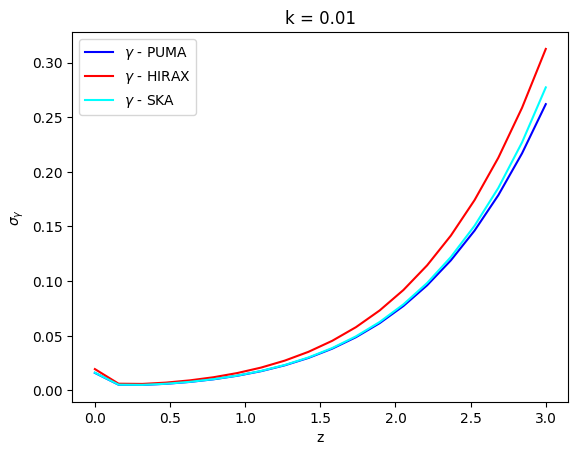

In [7]:
import matplotlib.pyplot as plt

# 1. Extract the X values (the first element of each row)
x_vals = [row[0] for row in store1]

# 2. Extract the Y values from the tuples
y1_vals = [row[1][0] for row in store1] # The first number in the tuple
y2_vals = [row[1][1] for row in store1] # The second number in the tuple

# 2. Extract the Y values from the tuples
y3_vals = [row[1][0] for row in store2] # The first number in the tuple
y4_vals = [row[1][1] for row in store2] # The second number in the tuple

# 2. Extract the Y values from the tuples
y5_vals = [row[1][0] for row in store3] # The first number in the tuple
y6_vals = [row[1][1] for row in store3] # The second number in the tuple

# 3. Plot them explicitly so you can label them
plt.plot(x_vals, y1_vals, label=r'$\gamma$ - PUMA', color='blue')
# plt.loglog(x_vals, y2_vals, label=r'$\beta$ - PUMA', color='orange')

plt.plot(x_vals, y3_vals, label=r'$\gamma$ - HIRAX', color='red')
# plt.loglog(x_vals, y4_vals, label=r'$\beta$ - HIRAX', color='green')

plt.plot(x_vals, y5_vals, label=r'$\gamma$ - SKA', color='cyan')
# plt.loglog(x_vals, y6_vals, label=r'$\beta$ - SKA', color='black')

plt.xlabel('z')
plt.ylabel(r'$\sigma_{\gamma}$')
plt.title("k = 0.01")
plt.legend()
plt.savefig("gamma_Exact_1e_14.pdf")
plt.show()

In [8]:
z_val = np.linspace(0,3,20)
survey = "PUMA"
k_vals = 0.01

h = 0.6766
Obh2 = 0.02242
Och2 = 0.11933

def OM_m(z):
    OM = (Obh2 + Och2) / h**2
    return (OM * (1+z)**3 / (OM * (1+z)**3 + 1 - OM))

store_gamma = []
store_beta = []
for z_i in z_val:
    bias = Power_HI(k_vals, 0, z_i, survey).bHI(z_i)
    gamma_val = gamma_interpolator(k_vals, z_i)
    f_kz = OM_m(z_i)**gamma_interpolator(k_vals, z_i) # gamma_interpolator(k_test, z_test)
    beta_val = f_kz/bias
    store_gamma.append(gamma_val)
    store_beta.append(beta_val)

# np.savetxt("data_PUMA_full_QS.dat",np.column_stack((x_vals, store_gamma ,y1_vals, store_beta, y2_vals)))
# np.savetxt("data_HIRAX_full_QS.dat",np.column_stack((x_vals, store_gamma, y3_vals, store_beta, y4_vals)))
# np.savetxt("data_SKA_full_QS.dat",np.column_stack((x_vals, store_gamma, y5_vals, store_beta, y6_vals)))

# import numpy as np

# Define your header string once to keep things clean and consistent
my_header = "z_val  gamma_fid  gamma_error  beta_fid  beta_error"

# Pass the header variable into each savetxt function
np.savetxt("data_PUMA_Exact_1e_14.dat", 
           np.column_stack((x_vals, store_gamma, y1_vals, store_beta, y2_vals)), 
           header=my_header)

np.savetxt("data_HIRAX_Exact_1e_14.dat", 
           np.column_stack((x_vals, store_gamma, y3_vals, store_beta, y4_vals)), 
           header=my_header)

np.savetxt("data_SKA_Exact_1e_14.dat", 
           np.column_stack((x_vals, store_gamma, y5_vals, store_beta, y6_vals)), 
           header=my_header)

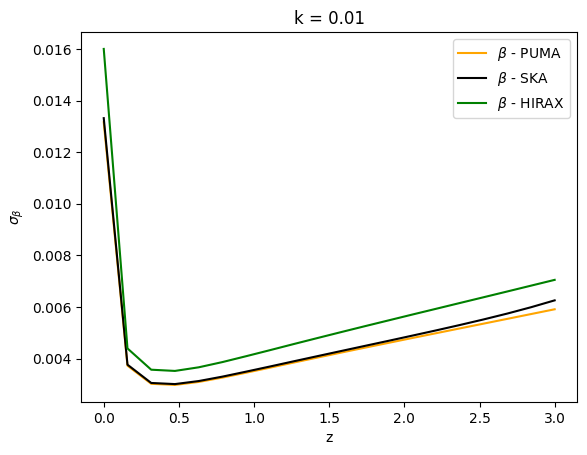

In [9]:
plt.plot(x_vals, y2_vals, label=r'$\beta$ - PUMA', color='orange')
plt.plot(x_vals, y6_vals, label=r'$\beta$ - SKA', color='black')
plt.plot(x_vals, y4_vals, label=r'$\beta$ - HIRAX', color='green')
plt.xlabel('z')
plt.ylabel(r'$\sigma_{\beta}$')
plt.title("k = 0.01")
plt.legend()
plt.savefig("beta_Exact_1e_14.pdf")
plt.show()

In [10]:
import numpy as np

# Load file (assuming whitespace separated)
data = np.genfromtxt("fR_exact_k_range15.csv", delimiter=",", skip_header=1)

# Columns
k = data[:, 0]
z = data[:, 1]
delta = data[:, 2]
growth = data[:, 3]

# Filter condition: z < 6
mask = z < 6

filtered_data = data[mask]

# Save new file
np.savetxt("fR_exact_k_range15_filter.dat", filtered_data)

In [11]:
import math
import numpy as np
from astropy.cosmology import Planck18 as cosmo
from scipy import interpolate
from scipy import integrate
import matplotlib.pyplot as plt
import pandas as pd
import scipy.linalg
import sys
from math import floor
import camb

# growth index
def gamma_interpolator(k,z):
    data_D = np.loadtxt("fR_exact_k_range15_filter.dat")
    # k_value  z_plot  Normalized_Delta  Gamma
    points = np.column_stack((data_D[:,0], data_D[:,1]))
    interpole_gama = interpolate.LinearNDInterpolator(points,data_D[:,3])
    return interpole_gama(k,z)
    
class Power_HI:
    def __init__(self, k, mu, z,survey):
        self.k = k
        self.mu = mu
        self.z = z
        self.h = 0.6766
        self.Obh2 = 0.02242
        self.Och2 = 0.11933
        self.OMh2 = self.Obh2 + self.Och2
        # self.gamma_value = gamma_interpolator(self.k, self.z)
        self.survey = survey
        # self.pk()

    def OHI(self, z):
        return 4e-4*(1+z)**0.6
    
    def bHI(self, z):
        #return 1.333 + 0.1809*z + 0.05302*z**2 - 0.0008822*z**3
        return 0.754 + 0.0877*z + 0.0607*z**2 - 0.00274*z**3

    def Tb_mean(self):
        '''
        output in units of mK
        '''
        return 188.0*self.OHI(self.z)*self.h*(1+self.z)**2*cosmo.H(0).value/cosmo.H(self.z).value

    def P_matter(self, z=0):
        """
        Calculate matter power spectrum for stored k values and given z (default z=0).
        Returns: P(k,z) in Mpc^3
        """
        pars = camb.CAMBparams()
        pars.set_cosmology(
            H0=self.h * 100,
            ombh2=self.Obh2,
            omch2=self.Och2,
            mnu=0.06,
            omk=0,
            tau=0.39
        )
        # pars.InitPower.set_params(As=self.As, ns=self.ns, r=0)
        pars.set_for_lmax(2500, lens_potential_accuracy=0)
        pars.set_accuracy(AccuracyBoost=4)
        pars.set_matter_power(redshifts=[z], kmax=max(np.atleast_1d(self.k)) * 1.1)
        
        results = camb.get_results(pars)
        P_m = results.get_matter_power_interpolator(
            nonlinear=None, hubble_units=False, k_hunit=False
        )
        return P_m.P(z, self.k)

    def f(self):
        OM = (self.Obh2 + self.Och2) / self.h**2
        return (OM * (1+self.z)**3 / (OM * (1+self.z)**3 + 1 - OM))**gamma_interpolator(self.k,self.z)

    def FoG(self):
        SigmaP = 350
        return np.exp(-self.k**2*self.mu**2*SigmaP**2/cosmo.H(self.z).value**2)

    def growth(self, k, z):
        data_D = np.loadtxt("fR_exact_k_range15_filter.dat")

        points = np.column_stack((data_D[:,0], data_D[:,1]))
        growth_D = interpolate.LinearNDInterpolator(points,data_D[:,2])
        # k_value  z_plot  Normalized_Delta  Gamma
        return growth_D(k,z)

    def P_HI(self):
        beta_val = self.f()/self.bHI(self.z)
        # print("Print beta ",beta_val)
        Powe = self.Tb_mean()**2 * self.FoG() * (1 + self.mu**2*beta_val)**2*self.bHI(self.z)**2*self.growth(self.k, self.z)*self.P_matter()
        # print("Power spectrum of 21cm signal", Powe)
        return Powe

    def PN(self):
        Noise = noise(self.survey)
        PN = Noise.noise_power_Mpc(self.z, self.k, self.mu)
        return PN

    def P_tot(self):
        P_fid = self.P_HI() + self.PN()
        power_noi = self.PN()
        # print("Noise power spectrum of HIRAX for 5 years:", power_noi)
        return P_fid

class Fisher:
    def __init__(self, k, z, dz, kmax, kfg, survey):
        self.k = k
        self.z = z
        self.dz = dz
        self.kmax = kmax
        self.h = 0.6766
        self.Obh2 = 0.02242
        self.Och2 = 0.11933
        self.kfg = kfg
        self.OM = (self.Obh2 + self.Och2) / self.h**2
        self.survey = survey
        self.kfg = kfg
    

    def V(self, z):
        f_sky = Telescope[self.survey]["Sky_fraction"]
        A = 4 * np.pi * f_sky
        v = A / 3 * ((cosmo.comoving_distance(z+self.dz/2).value)**3 - (cosmo.comoving_distance(z-self.dz/2).value)**3)
        return v

    def OM_m(self):
        OM = (self.Obh2 + self.Och2) / self.h**2
        return (OM * (1+self.z)**3 / (OM * (1+self.z)**3 + 1 - OM))

    def alpha(self, z):
        Dd = Telescope[self.survey]["Dish_diameter"]
        return np.arctan(cosmo.H(z).value * cosmo.comoving_distance(z).value * np.sin(0.61 * self.theta_b(z)) / (3e+5 * (1 + z)))

    def theta_b(self, z):
        Dd = Telescope[self.survey]["Dish_diameter"]
        return (1 + z) * 0.21 / Dd  # 0.21 meter wavelength

    def dP_dfi(self,k, mu, z, param):
        bias = Power_HI(k, mu, z, self.survey).bHI(z)
        matter_power = Power_HI(k, mu, z, self.survey).P_matter()
        f_kz = self.OM_m()**gamma_interpolator(k,z) # gamma_interpolator(k_test, z_test)
        beta_val = f_kz/bias
        
        ''' Change this'''
        if param == "gamma":
            # beta_val = self.f()/self.bHI(self.z)
            # f_kz = self.OM_m()**gamma_interpolator(k,z) # gamma_interpolator(k_test, z_test)
            # P_m = Power_HI(k, mu, z, self.survey).P_HI()
            # bias = Power_HI(k, mu, z, self.survey).bHI(z)
            # dP_df = 2*P_m*(bias + mu**2*f_kz)*mu**2*f_kz*np.log(self.OM_m())
            dP_df = 2*(1.0 + mu**2*beta_val)*matter_power*bias*mu**2*f_kz*np.log(self.OM_m())
            return dP_df

        elif param == "beta_par":
            dP_df = 2*(1.0 + mu**2*beta_val)*mu**2*bias**2*matter_power
            return dP_df

        else:
            print("Enter correct NAME")
            
    '''factor 2 from mu integration'''
    def inter(self, k, mu, z, param1, param2):
        integ_val = 2*self.V(z)/(8*np.pi**2)*k**2*self.dP_dfi(k, mu, z, param1)*self.dP_dfi(k, mu, z, param2)/(Power_HI(k, mu, z,self.survey).P_tot())**2
        return integ_val

    # Fisher matrix code
    def fisher_quad(self,param1, param2):
        n_bins = 50

        # print("Fundamental k ",2 * np.pi / (self.V(self.z))**(1/3))
        # For Interference
        if self.survey == "HIRAX" or self.survey == "PUMA":
        
            
            mu_min, mu_max = np.sin(self.alpha(self.z)), 1.0
            k_f = 2 * np.pi / (self.V(self.z))**(1/3)
            k_fg = self.kfg * self.h
            # k_min = lambda mu: np.where(k_f > k_fg, k_f / np.abs(mu), k_fg / np.abs(mu))
            k_min = lambda mu: np.maximum(np.array(k_f)/np.abs(mu) , np.array(k_fg)/np.abs(mu))
            
            k_max = self.kmax

        # For Single Dish
        elif self.survey == "SKA_MID":
        
            
            mu_min, mu_max = 0.0 , 1.0
            k_f = 2 * np.pi / (self.V(self.z))**(1/3)
            k_fg = self.kfg * self.h
            # k_min = lambda mu: np.where(k_f > k_fg, k_f / np.abs(mu), k_fg / np.abs(mu))
            # k_min = lambda mu: np.maximum(np.array(k_f)/np.abs(mu) , np.array(k_fg)/np.abs(mu))
            k_min = lambda mu: np.maximum(np.array(k_f) , np.array(k_fg))/np.abs(mu)
            
            k_max = self.kmax
        else:
            print("Enter correct name")

        mu_bins = np.linspace(mu_min, mu_max, n_bins)
        dmu = mu_bins[1] - mu_bins[0]
        mu_midpoints = (mu_bins[:-1] + mu_bins[1:]) * 0.5
        sum_result = 0

        k_low_vals = k_min(mu_midpoints)
        dk_vals = (k_max - k_low_vals) / (n_bins - 1)

        # 2. Evaluate the integrand for all mu_midpoints at once
        integrand_vals = self.inter(self.k, mu_midpoints, self.z, param1, param2)
        # print("Print the integrand values ", integrand_vals)
        # 3. Multiply and sum over the mu axis
        # We sum over the axis corresponding to mu (adjust axis=0 or axis=-1 depending on 
        # the exact shape self.inter returns when given self.k and mu arrays).
        sum_result += np.sum(integrand_vals * dk_vals * dmu, axis=0)
        return sum_result


def Sigma_g2m(k,z, dz, k_max,kfg, survey):
    # F_ij = np.zeros((2,2))
    # print(F_ij.shape)
    # fisher_quad(self,param1, param2)
    F_ij_1= Fisher(k,z, dz, k_max, kfg, survey).fisher_quad("gamma","gamma")
    # F_ij[0,1] = Fisher(k,z, dz, k_max, kfg, survey).fisher_quad("gamma","beta_par")
    # F_ij[0,0] = Fisher(k,z, dz, k_max, kfg, survey).fisher_quad("gamma","beta_par")
    F_ij_2 = Fisher(k,z, dz, k_max, kfg, survey).fisher_quad("beta_par","beta_par")

    print("Printing the fisher matrix",F_ij_1, F_ij_2)
    # print(F_ij_1, F_ij_2)
    return F_ij_1**(-1/2),F_ij_2**(-1/2)


# Define All the form of f(k)
def fun(k,q):
    kg = 0.05
    return (k/kg)**q
# Calling the function....
z = 1
dz = 0.1
k_val = 0.01

h = 0.6766
ns = 0.9665
k_max = 0.1 * (1 + z)**(2. / (2 + ns)) * h
print("k_max possible:", k_max)
kmax = np.linspace(0.10, k_max, 8)

quadrup = []

# fisher = Fisher(0.1*h,z, dz, k_max, 0.01, "HIRAX")
# print("Survey volume", fisher.V(z))
# fish = fisher.fisher_quad()
# quadrup.append(fish)
# print("Fisher matrix for HIRAX with kfg=0.00 :", fish)
print("printing the sigma using above function",Sigma_g2m(k_val,z, dz, k_max, 0, "PUMA"))

k_max possible: 0.1079654913116559
Printing the fisher matrix 4874.421590576834 85409.85742472425
printing the sigma using above function (np.float64(0.014323147213001092), np.float64(0.0034217320805324967))


In [12]:
# Sigma_g2m(k,z, dz, k_max,kfg, survey)
dz = 0.1
z_val = np.linspace(0,3,20)
survey = "PUMA"
kfg = 0.01
k_vals = 0.01
store1 = []
h = 0.6766
ns = 0.9665

for z_i in z_val:
    k_max = 0.1 * (1 + z_i)**(2. / (2 + ns)) * h
    results = Sigma_g2m(k_vals, z_i, dz, k_max, kfg, survey)
    store1.append([z_i,results])

survey = "HIRAX"
store2 = []
for z_i in z_val:
    k_max = 0.1 * (1 + z_i)**(2. / (2 + ns)) * h
    results = Sigma_g2m(k_vals, z_i, dz, k_max, kfg, survey)
    store2.append([z_i,results])

survey = "SKA_MID"
store3 = []
for z_i in z_val:
    k_max = 0.1 * (1 + z_i)**(2. / (2 + ns)) * h
    results = Sigma_g2m(k_vals, z_i, dz, k_max, kfg, survey)
    store3.append([z_i,results])


Printing the fisher matrix 3829.151217735104 5799.68892334901
Printing the fisher matrix 34887.995060052854 69650.84607342412
Printing the fisher matrix 36297.54992186857 102596.10644287076
Printing the fisher matrix 24787.984753262517 103802.42674075397
Printing the fisher matrix 15097.36276580872 96157.52564195027
Printing the fisher matrix 8981.295827330796 88108.79904082115
Printing the fisher matrix 5413.601850201628 82075.86350030746
Printing the fisher matrix 3134.4816792051997 73264.06224520283
Printing the fisher matrix 1796.5385192604408 64319.159893482225
Printing the fisher matrix 1057.8761606897042 57495.89224384561
Printing the fisher matrix 640.861005024714 52336.987493399516
Printing the fisher matrix 399.6035751120588 48504.133095794925
Printing the fisher matrix 256.51401000432224 45763.34755143878
Printing the fisher matrix 165.94423589991067 43031.273050013915
Printing the fisher matrix 105.10674102832303 39183.47204277359
Printing the fisher matrix 67.9962603858499

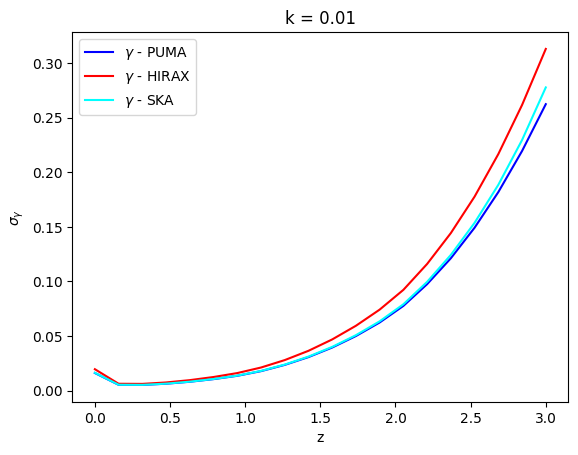

In [13]:
import matplotlib.pyplot as plt

# 1. Extract the X values (the first element of each row)
x_vals = [row[0] for row in store1]

# 2. Extract the Y values from the tuples
y1_vals = [row[1][0] for row in store1] # The first number in the tuple
y2_vals = [row[1][1] for row in store1] # The second number in the tuple

# 2. Extract the Y values from the tuples
y3_vals = [row[1][0] for row in store2] # The first number in the tuple
y4_vals = [row[1][1] for row in store2] # The second number in the tuple

# 2. Extract the Y values from the tuples
y5_vals = [row[1][0] for row in store3] # The first number in the tuple
y6_vals = [row[1][1] for row in store3] # The second number in the tuple

# 3. Plot them explicitly so you can label them
plt.plot(x_vals, y1_vals, label=r'$\gamma$ - PUMA', color='blue')
# plt.loglog(x_vals, y2_vals, label=r'$\beta$ - PUMA', color='orange')

plt.plot(x_vals, y3_vals, label=r'$\gamma$ - HIRAX', color='red')
# plt.loglog(x_vals, y4_vals, label=r'$\beta$ - HIRAX', color='green')

plt.plot(x_vals, y5_vals, label=r'$\gamma$ - SKA', color='cyan')
# plt.loglog(x_vals, y6_vals, label=r'$\beta$ - SKA', color='black')

plt.xlabel('z')
plt.ylabel(r'$\sigma_{\gamma}$')
plt.title("k = 0.01")
plt.legend()
plt.savefig("gamma_Exact_1e_15.pdf")
plt.show()

In [14]:
z_val = np.linspace(0,3,20)
survey = "PUMA"
k_vals = 0.01

h = 0.6766
Obh2 = 0.02242
Och2 = 0.11933

def OM_m(z):
    OM = (Obh2 + Och2) / h**2
    return (OM * (1+z)**3 / (OM * (1+z)**3 + 1 - OM))

store_gamma = []
store_beta = []
for z_i in z_val:
    bias = Power_HI(k_vals, 0, z_i, survey).bHI(z_i)
    gamma_val = gamma_interpolator(k_vals, z_i)
    f_kz = OM_m(z_i)**gamma_interpolator(k_vals, z_i) # gamma_interpolator(k_test, z_test)
    beta_val = f_kz/bias
    store_gamma.append(gamma_val)
    store_beta.append(beta_val)

# np.savetxt("data_PUMA_full_QS.dat",np.column_stack((x_vals, store_gamma ,y1_vals, store_beta, y2_vals)))
# np.savetxt("data_HIRAX_full_QS.dat",np.column_stack((x_vals, store_gamma, y3_vals, store_beta, y4_vals)))
# np.savetxt("data_SKA_full_QS.dat",np.column_stack((x_vals, store_gamma, y5_vals, store_beta, y6_vals)))

# import numpy as np

# Define your header string once to keep things clean and consistent
my_header = "z_val  gamma_fid  gamma_error  beta_fid  beta_error"

# Pass the header variable into each savetxt function
np.savetxt("data_PUMA_Exact_1e_15.dat", 
           np.column_stack((x_vals, store_gamma, y1_vals, store_beta, y2_vals)), 
           header=my_header)

np.savetxt("data_HIRAX_Exact_1e_15.dat", 
           np.column_stack((x_vals, store_gamma, y3_vals, store_beta, y4_vals)), 
           header=my_header)

np.savetxt("data_SKA_Exact_1e_15.dat", 
           np.column_stack((x_vals, store_gamma, y5_vals, store_beta, y6_vals)), 
           header=my_header)

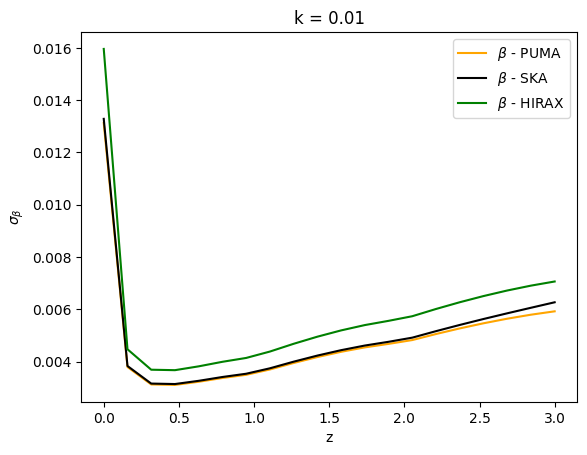

In [15]:
plt.plot(x_vals, y2_vals, label=r'$\beta$ - PUMA', color='orange')
plt.plot(x_vals, y6_vals, label=r'$\beta$ - SKA', color='black')
plt.plot(x_vals, y4_vals, label=r'$\beta$ - HIRAX', color='green')
plt.xlabel('z')
plt.ylabel(r'$\sigma_{\beta}$')
plt.title("k = 0.01")
plt.legend()
plt.savefig("beta_Exact_1e_15.pdf")
plt.show()

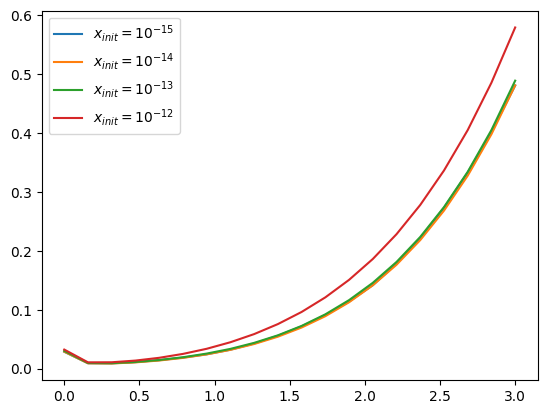

In [27]:
# For full
data_1 = np.loadtxt("data_PUMA_Exact_1e_15.dat")
data_2 = np.loadtxt("data_PUMA_Exact_1e_14.dat")
data_3 = np.loadtxt("data_PUMA_Exact_1e_13.dat")
data_4 = np.loadtxt("data_PUMA_Exact_12.dat")

plt.plot(data_1[:,0],data_1[:,2]/data_1[:,1], label = "$x_{init} = 10^{-15}$")
plt.plot(data_2[:,0],data_2[:,2]/data_2[:,1], label = "$x_{init} = 10^{-14}$")
plt.plot(data_3[:,0],data_3[:,2]/data_3[:,1], label = "$x_{init} = 10^{-13}$")
plt.plot(data_4[:,0],data_4[:,2]/data_4[:,1], label = "$x_{init} = 10^{-12}$")
# plt.plot(data_1[:,0],data_1[:,2], label = "$x_{init} = 10^{-15}$")
# plt.plot(data_2[:,0],data_2[:,2], label = "$x_{init} = 10^{-14}$")
# plt.plot(data_3[:,0],data_3[:,2], label = "$x_{init} = 10^{-13}$")
# plt.plot(data_4[:,0],data_4[:,2], label = "$x_{init} = 10^{-12}$")
plt.legend()

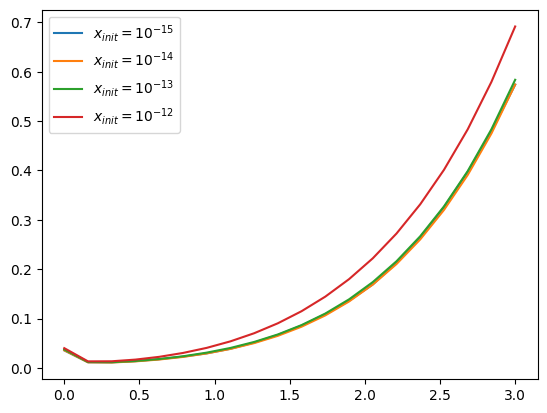

In [20]:
# For full
data_1 = np.loadtxt("data_HIRAX_Exact_1e_15.dat")
data_2 = np.loadtxt("data_HIRAX_Exact_1e_14.dat")
data_3 = np.loadtxt("data_HIRAX_Exact_1e_13.dat")
data_4 = np.loadtxt("data_HIRAX_Exact_12.dat")

plt.plot(data_1[:,0],data_1[:,2]/data_1[:,1], label = "$x_{init} = 10^{-15}$")
plt.plot(data_2[:,0],data_2[:,2]/data_2[:,1], label = "$x_{init} = 10^{-14}$")
plt.plot(data_3[:,0],data_3[:,2]/data_3[:,1], label = "$x_{init} = 10^{-13}$")
plt.plot(data_4[:,0],data_4[:,2]/data_4[:,1], label = "$x_{init} = 10^{-12}$")
plt.legend()

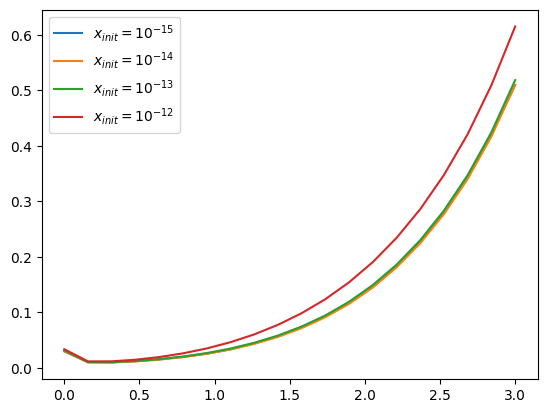

In [29]:
# For full
data_1 = np.loadtxt("data_SKA_Exact_1e_15.dat")
data_2 = np.loadtxt("data_SKA_Exact_1e_14.dat")
data_3 = np.loadtxt("data_SKA_Exact_1e_13.dat")
data_4 = np.loadtxt("data_SKA_Exact_12.dat")

plt.plot(data_1[:,0],data_1[:,2]/data_1[:,1], label = "$x_{init} = 10^{-15}$")
plt.plot(data_2[:,0],data_2[:,2]/data_2[:,1], label = "$x_{init} = 10^{-14}$")
plt.plot(data_3[:,0],data_3[:,2]/data_3[:,1], label = "$x_{init} = 10^{-13}$")
plt.plot(data_4[:,0],data_4[:,2]/data_4[:,1], label = "$x_{init} = 10^{-12}$")
plt.legend()

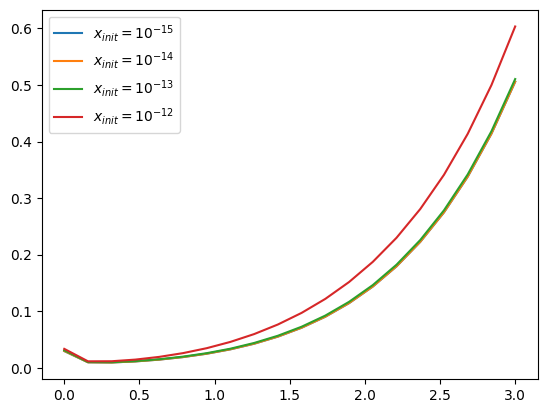

In [30]:
# For full
data_1 = np.loadtxt("data_SKA_full_QS_1e_15.dat")
data_2 = np.loadtxt("data_SKA_full_QS_1e_14.dat")
data_3 = np.loadtxt("data_SKA_full_QS_1e_13.dat")
data_4 = np.loadtxt("data_SKA_full_QS_12.dat")

plt.plot(data_1[:,0],data_1[:,2]/data_1[:,1], label = "$x_{init} = 10^{-15}$")
plt.plot(data_2[:,0],data_2[:,2]/data_2[:,1], label = "$x_{init} = 10^{-14}$")
plt.plot(data_3[:,0],data_3[:,2]/data_3[:,1], label = "$x_{init} = 10^{-13}$")
plt.plot(data_4[:,0],data_4[:,2]/data_4[:,1], label = "$x_{init} = 10^{-12}$")
plt.legend()

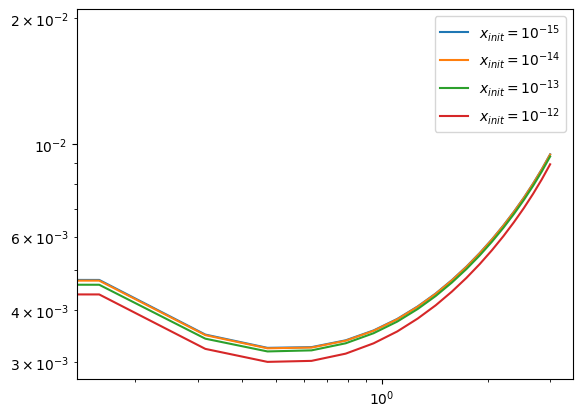

In [32]:
# For full
data_1 = np.loadtxt("data_SKA_full_QS_1e_15.dat")
data_2 = np.loadtxt("data_SKA_full_QS_1e_14.dat")
data_3 = np.loadtxt("data_SKA_full_QS_1e_13.dat")
data_4 = np.loadtxt("data_SKA_full_QS_12.dat")

plt.loglog(data_1[:,0],data_1[:,4]/data_1[:,3], label = "$x_{init} = 10^{-15}$")
plt.loglog(data_2[:,0],data_2[:,4]/data_2[:,3], label = "$x_{init} = 10^{-14}$")
plt.loglog(data_3[:,0],data_3[:,4]/data_3[:,3], label = "$x_{init} = 10^{-13}$")
plt.loglog(data_4[:,0],data_4[:,4]/data_4[:,3], label = "$x_{init} = 10^{-12}$")
plt.legend()

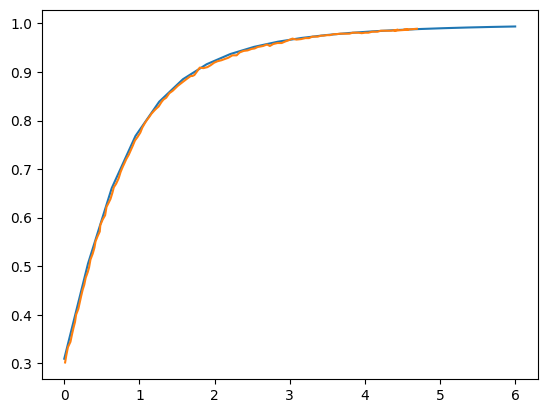

In [4]:
def OM_m(z):
    h = 0.6766
    Obh2 = 0.02242
    Och2 = 0.11933
    
    OM = (Obh2 + Och2) / h**2
    return (OM * (1+z)**3 / (OM * (1+z)**3 + 1 - OM))

import numpy as np
z_val = np.linspace(0,6,20)
stored_val = OM_m(z_val)
import matplotlib.pyplot as plt
plt.plot(z_val,stored_val)
data = np.genfromtxt("om_gr.csv", delimiter=",", skip_header=1)
plt.plot(data[:,0],data[:,1])

In [8]:
z = np.linspace(0,6,6)
k_max_z = lambda z: 0.1 * (1 + z)**(2. / (2 + ns)) * h
print(z,k_max_z(z))
print(k_max_z(2.55))

[0.  1.2 2.4 3.6 4.8 6. ] [0.06766    0.11513085 0.15440186 0.18930415 0.22132551 0.25124245]
0.15896199210951775


In [59]:
k_max = np.linspace(0.1*h,0.3*h,10)
print("Print k_max :",k_max)
output_values = Sigma_g2m(0.1*h,z, dz, k_max, 0.01, "SKA_MID")


Print k_max : [0.06766    0.08269556 0.09773111 0.11276667 0.12780222 0.14283778
 0.15787333 0.17290889 0.18794444 0.20298   ]
Printing the fisher matrix
[161.19348721 201.33265919 241.47183116 281.61100314 321.75017512
 361.8893471  402.02851907 442.16769105 482.30686303 522.44603501]


In [ ]:
k = 

In [7]:
h = 0.6766
Obh2 = 0.02242
Och2 = 0.11933
OMh2 = Obh2 + Och2
def OM_m(z):
    OM = (Obh2 + Och2) / h**2
    return (OM * (1+z)**3 / (OM * (1+z)**3 + 1 - OM))

def Gro_GR(z):
    return OM_m(z)**0.545

def Gro_FR(k,z):
    return OM_m(z)**gamma_interpolator(k,z)

z_val = np.linspace(0,6,10)
k_val = 0.01
growth_GR = Gro_GR(z_val)[]
growth_fR = Gro_FR(k_val,z_val)
plt.plot(z_val,growth_fR,label = "f(R)")
plt.plot(z_val,growth_GR, label ="GR")
plt.legend()

ValueError: could not broadcast input array from shape (10,) into shape (1,)

In [95]:
k_max = np.linspace(0.1*h,0.3*h,10)
dz = 0.1
col = 5
output = np.zeros((len(k_max),col+1))
# header should be like this k_max  True gamma  error_at_z_{0} error_at_z_{1} error_at_z_{2} error_at_z_{3}
for i in range(col-1):
    print("Print i :",i)
    output[:,0] = k_max
    output[:,1] = gamma_interpolator(0.1*h,i)
    output[:,i+2] = Sigma_g2m(0.1*h,i, dz, k_max, 0.01, "PUMA")

np.savetxt("fisher_value.dat",output)

Print i : 0
Printing the fisher matrix
[ 3.1872796   4.21411216  5.24094472  6.26777728  7.29460984  8.3214424
  9.34827496 10.37510752 11.40194008 12.42877264]
Print i : 1
Printing the fisher matrix
[278.6163305  348.85454237 419.09275425 489.33096613 559.56917801
 629.80738988 700.04560176 770.28381364 840.52202552 910.7602374 ]
Print i : 2
Printing the fisher matrix
[ 62.81308326  78.65940318  94.5057231  110.35204303 126.19836295
 142.04468288 157.8910028  173.73732272 189.58364265 205.42996257]
Print i : 3
Printing the fisher matrix
[16.39867687 20.53930011 24.67992334 28.82054658 32.96116982 37.10179306
 41.2424163  45.38303954 49.52366277 53.66428601]


# Ploting data as a function of $k$

In [23]:
TESTING = 1
k_at_val = np.linspace(0.05, 0.10, 10)
k_max = 0.1
dz = 0.1
survey = "SKA_MID"
# Redshifts bins
col = 2
z_min = 0.775
z_max = 1.169
z_vals = np.linspace(z_min,z_max,col)
output = np.zeros((len(k_at_val), col+2))

# Construct header dynamically
header = "k_max  True_gamma"
for i in z_vals:
    header += f"  error_at_z_{{{i}}}"

# Fill the output array
for i,z in enumerate(z_vals):
    print("Print index :", i)
    print("Print the redshifts :",z)
    output[:, 0] = k_max
    output[:, 1] = gamma_interpolator(k_at_val, z)
    # Sigma_g2m(0.1*h,z, dz, k_max, 0.01, "HIRAX"))       (k, z, dz, kmax, kfg, survey)
    output[:, i + 2] = Sigma_g2m(k_at_val, z, dz, k_max, 0.01, survey)

# Save to file with header
np.savetxt(f"fisher_value_{survey}_k_max_{TESTING}.dat",output, header=header, fmt="%.6e")


Print index : 0
Print the redshifts : 0.775
Printing the fisher matrix
[279.22483501 339.29572724 399.71332833 457.50225272 512.88523515
 562.84211933 610.07363114 650.62766993 681.61465851 705.62461638]
Print index : 1
Print the redshifts : 1.169
Printing the fisher matrix
[140.32048805 154.46151163 163.9329696  170.56307462 174.5896588
 178.69332925 182.12883947 183.77756256 183.54143316 180.84163325]


In [24]:
k_at_val = np.linspace(0.05, 0.10, 10)
k_max = 0.1
dz = 0.1
survey = "HIRAX"
# Redshifts bins
col = 2
z_min = 0.775
z_max = 1.169
z_vals = np.linspace(z_min,z_max,col)
output = np.zeros((len(k_at_val), col+2))

# Construct header dynamically
header = "k_max  True_gamma"
for i in z_vals:
    header += f"  error_at_z_{{{i}}}"

# Fill the output array
for i,z in enumerate(z_vals):
    print("Print index :", i)
    print("Print the redshifts :",z)
    output[:, 0] = k_max
    output[:, 1] = gamma_interpolator(k_at_val, z)
    # Sigma_g2m(0.1*h,z, dz, k_max, 0.01, "HIRAX"))       (k, z, dz, kmax, kfg, survey)
    output[:, i + 2] = Sigma_g2m(k_at_val, z, dz, k_max, 0.01, survey)

# Save to file with header
np.savetxt(f"fisher_value_{survey}_k_max_{TESTING}.dat",output, header=header, fmt="%.6e")


Print index : 0
Print the redshifts : 0.775
Printing the fisher matrix
[204.60661592 251.20575694 301.69299277 356.16845879 415.75995392
 479.62293527 549.14695451 622.76096966 699.08156962 778.73337599]
Print index : 1
Print the redshifts : 1.169
Printing the fisher matrix
[126.46428879 154.96503523 185.60771992 218.69359841 253.9083458
 292.53306737 334.13686612 377.6241067  422.32376894 466.66448613]


In [25]:
k_at_val = np.linspace(0.05, 0.10, 10)
k_max = 0.1
dz = 0.1
survey = "PUMA"
# Redshifts bins
col = 2
z_min = 0.775
z_max = 1.169
z_vals = np.linspace(z_min,z_max,col)
output = np.zeros((len(k_at_val), col+2))

# Construct header dynamically
header = "k_max  True_gamma"
for i in z_vals:
    header += f"  error_at_z_{{{i}}}"

# Fill the output array
for i,z in enumerate(z_vals):
    print("Print index :", i)
    print("Print the redshifts :",z)
    output[:, 0] = k_max
    output[:, 1] = gamma_interpolator(k_at_val, z)
    # Sigma_g2m(0.1*h,z, dz, k_max, 0.01, "HIRAX"))       (k, z, dz, kmax, kfg, survey)
    output[:, i + 2] = Sigma_g2m(k_at_val, z, dz, k_max, 0.01, survey)

# Save to file with header
np.savetxt(f"fisher_value_{survey}_k_max_{TESTING}.dat",output, header=header, fmt="%.6e")


Print index : 0
Print the redshifts : 0.775
Printing the fisher matrix
[ 292.06884176  360.09964578  435.23100607  517.56024484  607.30881957
  704.5083611   809.48754707  922.23811582 1042.80308001 1171.39084645]
Print index : 1
Print the redshifts : 1.169
Printing the fisher matrix
[184.44438319 227.85230241 275.88186629 328.60421565 386.05520441
 448.39261709 515.66830725 587.84229734 664.93858789 746.85916564]


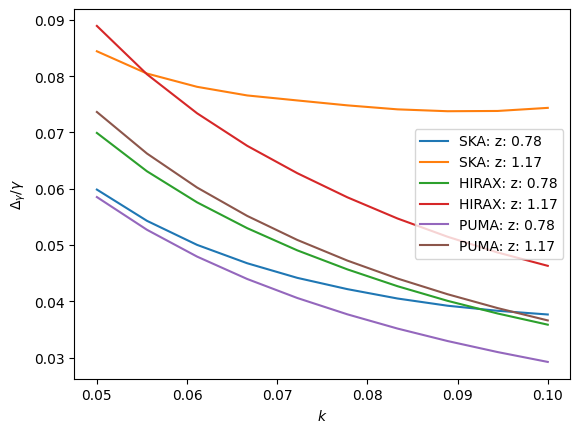

In [26]:
k_max = 0.1
first = 1
data_SKA = np.loadtxt(f"fisher_value_SKA_MID_k_max_{TESTING}.dat")
data_HIRAX = np.loadtxt(f"fisher_value_HIRAX_k_max_{TESTING}.dat")
data_PUMA = np.loadtxt(f"fisher_value_PUMA_k_max_{TESTING}.dat")
k_max_data = data_SKA[:,0]
plt.plot(k_at_val, data_SKA[:,2],label = "SKA: z: 0.78")
plt.plot(k_at_val, data_SKA[:,3],label = "SKA: z: 1.17")
plt.plot(k_at_val, data_HIRAX[:,2],label = "HIRAX: z: 0.78")
plt.plot(k_at_val, data_HIRAX[:,3],label = "HIRAX: z: 1.17")
plt.plot(k_at_val, data_PUMA[:,2],label = "PUMA: z: 0.78")
plt.plot(k_at_val, data_PUMA[:,3],label = "PUMA: z: 1.17")

k_max_data = data[:,0]
# print("Ratio ",showing_out)
# plt.plot(k_max,output_values,label ="$\sigma_{\gamma}$")
# plt.plot(k_max,showing_out, label ="$\sigma_{\gamma}/ \gamma$")
plt.legend()
plt.xlabel("$k$")
plt.ylabel(r"$\Delta_{\gamma}/{\gamma}$")
plt.savefig(f"Relative_error_k_max_{k_max}.pdf")

# Ploting as a function of $k_{max}$

In [35]:
k_at_val = 0.05
k_max = np.linspace(0.05, 0.15, 10)
dz = 0.1
survey = "SKA_MID"
# Redshifts bins
col = 2
z_min = 0.775
z_max = 1.169
z_vals = np.linspace(z_min,z_max,col)
output = np.zeros((len(k_max), col+2))

# Construct header dynamically
header = "k_max  True_gamma"
for i in z_vals:
    header += f"  error_at_z_{{{i}}}"

# Fill the output array
for i,z in enumerate(z_vals):
    print("Print index :", i)
    print("Print the redshifts :",z)
    output[:, 0] = k_max
    output[:, 1] = gamma_interpolator(k_at_val, z)
    output[:, i + 2] = Sigma_g2m(k_at_val, z, dz, k_max, 0.01, survey)

# Save to file with header
np.savetxt(f"fisher_value_{survey}_k_{k_at_val}.dat",output, header=header, fmt="%.6e")


Print index : 0
Print the redshifts : 0.775
Printing the fisher matrix
[127.53881183 161.24663192 194.95445202 228.66227211 262.3700922
 296.07791229 329.78573238 363.49355247 397.20137257 430.90919266]
Print index : 1
Print the redshifts : 1.169
Printing the fisher matrix
[ 64.48276434  81.33573507  98.1887058  115.04167653 131.89464726
 148.74761799 165.60058872 182.45355945 199.30653019 216.15950092]


In [36]:
k_max = np.linspace(0.05, 0.15, 10)
dz = 0.1
survey = "HIRAX"
# Redshifts bins
col = 2
z_min = 0.775
z_max = 1.169
z_vals = np.linspace(z_min,z_max,col)
output = np.zeros((len(k_max), col+2))

# Construct header dynamically
header = "k_max  True_gamma"
for i in z_vals:
    header += f"  error_at_z_{{{i}}}"

# Fill the output array
for i,z in enumerate(z_vals):
    print("Print index :", i)
    print("Print the redshifts :",z)
    output[:, 0] = k_max
    output[:, 1] = gamma_interpolator(k_at_val, z)
    output[:, i + 2] = Sigma_g2m(k_at_val, z, dz, k_max, 0.01, survey)

# Save to file with header
np.savetxt(f"fisher_value_{survey}_k_{k_at_val}.dat", output, header=header, fmt="%.6e")


Print index : 0
Print the redshifts : 0.775
Printing the fisher matrix
[ 93.40232001 118.11425004 142.82618007 167.5381101  192.25004013
 216.96197016 241.67390019 266.38583022 291.09776025 315.80969028]
Print index : 1
Print the redshifts : 1.169
Printing the fisher matrix
[ 57.73120752  73.00534987  88.27949222 103.55363457 118.82777692
 134.10191927 149.37606162 164.65020396 179.92434631 195.19848866]


In [37]:
k_max = np.linspace(0.05, 0.15, 10)
dz = 0.1
survey = "PUMA"
# Redshifts bins
col = 2
z_min = 0.775
z_max = 1.169
z_vals = np.linspace(z_min,z_max,col)
output = np.zeros((len(k_max), col+2))

# Construct header dynamically
header = "k_max  True_gamma"
for i in z_vals:
    header += f"  error_at_z_{{{i}}}"

# Fill the output array
for i,z in enumerate(z_vals):
    print("Print index :", i)
    print("Print the redshifts :",z)
    output[:, 0] = k_max
    output[:, 1] = gamma_interpolator(k_at_val, z)
    output[:, i + 2] = Sigma_g2m(k_at_val, z, dz, k_max, 0.01, survey)

# Save to file with header
np.savetxt(f"fisher_value_{survey}_k_{k_at_val}.dat", output, header=header, fmt="%.6e")


Print index : 0
Print the redshifts : 0.775
Printing the fisher matrix
[133.30785921 168.58788541 203.86791162 239.14793782 274.42796402
 309.70799023 344.98801643 380.26804263 415.54806883 450.82809504]
Print index : 1
Print the redshifts : 1.169
Printing the fisher matrix
[ 84.17592972 106.45798694 128.74004416 151.02210137 173.30415859
 195.5862158  217.86827302 240.15033023 262.43238745 284.71444467]


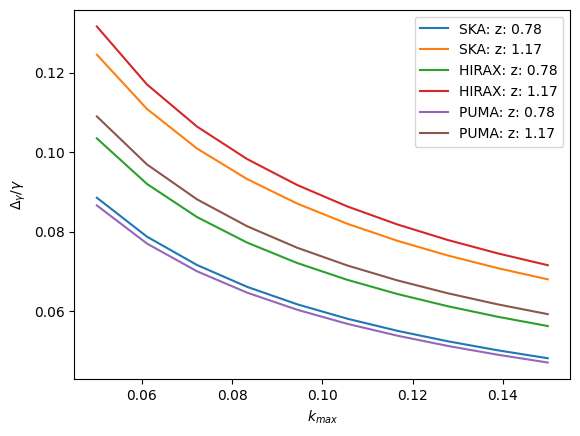

In [38]:
data_SKA = np.loadtxt(f"fisher_value_SKA_MID_k_{k_at_val}.dat")
data_HIRAX = np.loadtxt(f"fisher_value_HIRAX_k_{k_at_val}.dat")
data_PUMA = np.loadtxt(f"fisher_value_PUMA_k_{k_at_val}.dat")
k_max_data = data_SKA[:,0]
plt.plot(k_max_data, data_SKA[:,2],label = "SKA: z: 0.78")
plt.plot(k_max_data, data_SKA[:,3],label = "SKA: z: 1.17")
plt.plot(k_max_data, data_HIRAX[:,2],label = "HIRAX: z: 0.78")
plt.plot(k_max_data, data_HIRAX[:,3],label = "HIRAX: z: 1.17")
plt.plot(k_max_data, data_PUMA[:,2],label = "PUMA: z: 0.78")
plt.plot(k_max_data, data_PUMA[:,3],label = "PUMA: z: 1.17")

k_max_data = data[:,0]
# print("Ratio ",showing_out)
# plt.plot(k_max,output_values,label ="$\sigma_{\gamma}$")
# plt.plot(k_max,showing_out, label ="$\sigma_{\gamma}/ \gamma$")
plt.legend()
plt.xlabel("$k_{max}$")
plt.ylabel(r"$\Delta_{\gamma}/{\gamma}$")
plt.savefig(f"Relative_error_k_{k_at_val}.pdf")

In [94]:
print(data[:,2]/0.545)

[0.13415794 0.11990013 0.10939601 0.10124317 0.09467778 0.08924363
 0.08464919 0.08069834 0.0772536  0.07421541]


In [77]:
print(data[:,2]/gamma_interpolator(0.1*h,2))

[0.63221737 0.56502763 0.51552716 0.477107   0.44616769 0.42055931
 0.3989081  0.38028976 0.3640565  0.34973905]


<>:10: SyntaxWarning: invalid escape sequence '\L'
<>:10: SyntaxWarning: invalid escape sequence '\L'
/tmp/ipykernel_48294/2546772503.py:10: SyntaxWarning: invalid escape sequence '\L'
  plt.loglog(k,power_HI_ONLY,label = "$ \Lambda CDM$")


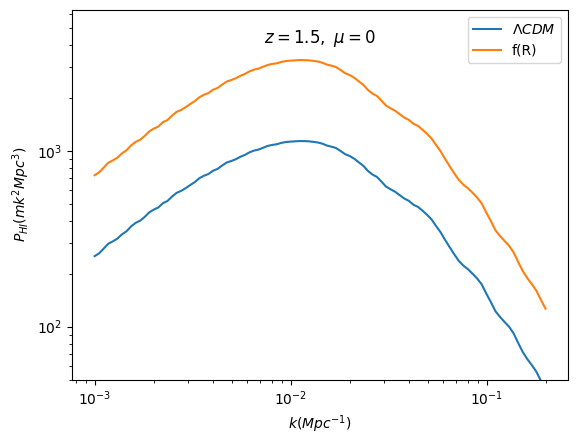

In [6]:
# Define the mu

z= 1.5
mu_values = 0
k = np.logspace(np.log10(10**(-3)),np.log10(0.2),100)
data = np.loadtxt("Power_spectrum_data_LCDM_mu_0.dat")
Power_class  = Power_HI(k ,mu_values,z,"HIRAX")
power_HI_ONLY = Power_class.P_HI()
power_noise = Power_class.PN()
plt.loglog(k,power_HI_ONLY,label = "$ \Lambda CDM$")
plt.loglog(data[:,0],data[:,1],label= "f(R)")
# Add annotation inside the plot
plt.text(0.5, 0.95, r"$z = 1.5,\ \mu = 0$", fontsize=12,
         ha='center', va='top', transform=plt.gca().transAxes,
         color='black')

plt.xlabel("$k(Mpc^{-1})$")
plt.ylabel("$P_{HI}(mk^2Mpc^3)$")
plt.ylim(50,10**3.8)
plt.legend()
plt.savefig("21cm_power_spectrum_mu_0.pdf")

<>:10: SyntaxWarning: invalid escape sequence '\L'
<>:10: SyntaxWarning: invalid escape sequence '\L'
/tmp/ipykernel_4264/741806303.py:10: SyntaxWarning: invalid escape sequence '\L'
  plt.loglog(k,power_HI_ONLY,label = "$ \Lambda CDM$")


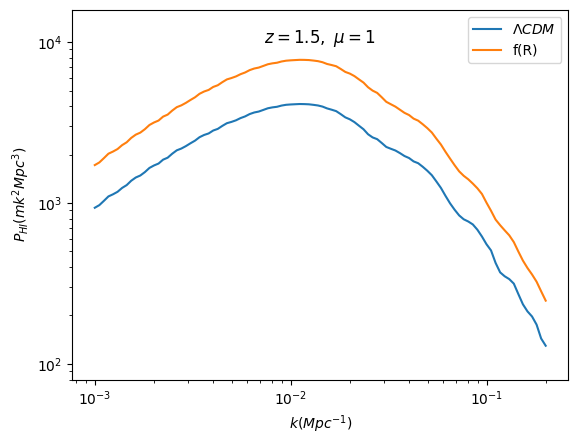

In [29]:
# Define the mu

z= 1.5
mu_values = 1
k = np.logspace(np.log10(10**(-3)),np.log10(0.2),100)
data = np.loadtxt("Power_spectrum_data_LCDM_mu_1.dat")
Power_class  = Power_HI(k ,mu_values,z,"HIRAX")
power_HI_ONLY = Power_class.P_HI()
power_noise = Power_class.PN()
plt.loglog(k,power_HI_ONLY,label = "$ \Lambda CDM$")
plt.loglog(data[:,0],data[:,1],label= "f(R)")
# Add annotation inside the plot
plt.text(0.5, 0.95, r"$z = 1.5,\ \mu = 1$", fontsize=12,
         ha='center', va='top', transform=plt.gca().transAxes,
         color='black')

plt.xlabel("$k(Mpc^{-1})$")
plt.ylabel("$P_{HI}(mk^2Mpc^3)$")
plt.ylim(80,10**4.2)
plt.legend()
plt.savefig("21cm_power_spectrum_mu_1.pdf")

In [38]:
import numpy as np

def stable_inverse(matrix, reg=1e-6):
    """
    Compute stable inverse using regularization
    matrix: Input matrix (numpy array)
    reg: Regularization strength (relative to mean diagonal)
    """
    diag_mean = np.mean(np.diag(matrix))
    epsilon = reg * diag_mean
    n = matrix.shape[0]
    # Add regularization to diagonal
    regularized_matrix = matrix + epsilon * np.eye(n)
    return np.linalg.inv(regularized_matrix)

# Your Fisher matrix (10x10)
F = np.array([
    [580.73616216, 552.8658801, 516.8782167, 476.57711079, 434.88987311, 394.00318188, 355.48420046, 320.38793645, 289.35190868, 262.67913728],
    [552.8658801, 544.505171, 522.40767595, 491.48648368, 455.61527992, 417.78237311, 380.2283603, 344.56863841, 311.90191026, 282.90578025],
    [516.8782167, 522.40767595, 512.06374564, 490.80699902, 462.6128102, 430.6115568, 397.21435726, 364.22538496, 332.94175429, 304.24192704],
    [476.57711079, 491.48648368, 490.80699902, 478.85778655, 459.16131791, 434.55075147, 407.26666811, 379.04393603, 351.18941016, 324.65113992],
    [434.88987311, 455.61527992, 462.6128102, 459.16131791, 448.00242711, 431.40573005, 411.22812701, 388.96768133, 365.81234769, 342.68391677],
    [394.00318188, 417.78237311, 430.6115568, 434.55075147, 431.40573005, 422.74895852, 409.93954381, 394.14219717, 376.34522091, 357.37752882],
    [355.48420046, 380.2283603, 397.21435726, 407.26666811, 411.22812701, 409.93954381, 404.22277622, 394.86693166, 382.61739299, 368.16737841],
    [320.38793645, 344.56863841, 364.22538496, 379.04393603, 388.96768133, 394.14219717, 394.86693166, 391.55342738, 384.68952058, 374.80898475],
    [289.35190868, 311.90191026, 332.94175429, 351.18941016, 365.81234769, 376.34522091, 382.61739299, 384.68952058, 382.79845418, 377.30974816],
    [262.67913728, 282.90578025, 304.24192704, 324.65113992, 342.68391677, 357.37752882, 368.16737841, 374.80898475, 377.30974816, 375.86968513]
])

# Compute stable inverse
F_inv_stable = stable_inverse(F, reg=1e-6)

print("Stable inverse:")
print(F_inv_stable)

Eigenvalues: [-2.24544292e-09  4.60809653e-07  1.62279789e-02  3.49843006e+01
  2.27298949e+03]
Condition number: -1012267763885.4224
Original eigenvalues: [-2.24544026e-09  4.60809671e-07  1.62279789e-02  3.49843006e+01
  2.27298949e+03]

Covariance matrix:
[[ 15.80038447  -9.37503427 -16.61167791  -7.21785269  17.53147429]
 [ -9.37503427   5.57474912   9.86787735   4.28157493 -10.42673956]
 [-16.61167791   9.86787735  17.47548404   7.58752135 -18.45470544]
 [ -7.21785269   4.28157493   7.58752135   3.29754977  -8.00600414]
 [ 17.53147429 -10.42673956 -18.45470544  -8.00600414  19.50282494]]

F @ cov ≈ I?
[[ 0.89423737  0.24617236 -0.08990904 -0.13619218  0.08569784]
 [ 0.24617236  0.38076801  0.35161358  0.17090555 -0.14947268]
 [-0.08990904  0.35161358  0.48542044  0.33392108 -0.08104567]
 [-0.13619218  0.17090555  0.33392108  0.36306973  0.26830914]
 [ 0.08569784 -0.14947268 -0.08104567  0.26830914  0.87650446]]


In [39]:
import numpy as np

# Define the Fisher matrix
F = np.array([
    [580.73616216, 552.8658801, 516.8782167, 476.57711079, 434.88987311, 394.00318188, 355.48420046, 320.38793645, 289.35190868, 262.67913728],
    [552.8658801, 544.505171, 522.40767595, 491.48648368, 455.61527992, 417.78237311, 380.2283603, 344.56863841, 311.90191026, 282.90578025],
    [516.8782167, 522.40767595, 512.06374564, 490.80699902, 462.6128102, 430.6115568, 397.21435726, 364.22538496, 332.94175429, 304.24192704],
    [476.57711079, 491.48648368, 490.80699902, 478.85778655, 459.16131791, 434.55075147, 407.26666811, 379.04393603, 351.18941016, 324.65113992],
    [434.88987311, 455.61527992, 462.6128102, 459.16131791, 448.00242711, 431.40573005, 411.22812701, 388.96768133, 365.81234769, 342.68391677],
    [394.00318188, 417.78237311, 430.6115568, 434.55075147, 431.40573005, 422.74895852, 409.93954381, 394.14219717, 376.34522091, 357.37752882],
    [355.48420046, 380.2283603, 397.21435726, 407.26666811, 411.22812701, 409.93954381, 404.22277622, 394.86693166, 382.61739299, 368.16737841],
    [320.38793645, 344.56863841, 364.22538496, 379.04393603, 388.96768133, 394.14219717, 394.86693166, 391.55342738, 384.68952058, 374.80898475],
    [289.35190868, 311.90191026, 332.94175429, 351.18941016, 365.81234769, 376.34522091, 382.61739299, 384.68952058, 382.79845418, 377.30974816],
    [262.67913728, 282.90578025, 304.24192704, 324.65113992, 342.68391677, 357.37752882, 368.16737841, 374.80898475, 377.30974816, 375.86968513]
])

# Function to compute correlation matrix from Fisher matrix
def compute_correlation_matrix(F):
    """
    Compute the correlation matrix from a Fisher matrix.
    
    Parameters:
        F (np.ndarray): Fisher matrix (symmetric, positive semi-definite).
    
    Returns:
        np.ndarray: Correlation matrix with elements r_ij = F_ij / sqrt(F_ii * F_jj).
    """
    diag_F = np.diag(F)
    denominator = np.sqrt(np.outer(diag_F, diag_F))
    R = F / denominator
    return R

# Compute the correlation matrix
R = compute_correlation_matrix(F)

# Print the correlation matrix
print("Correlation Matrix:")
print(np.round(R, 3))  # Round to 3 decimal places for readability

# Print correlations between adjacent parameters
print("\nCorrelations between adjacent parameters:")
for i in range(9):
    corr = R[i, i+1]
    print(f"Parameters {i+1} and {i+2}: {corr:.3f}")

Correlation Matrix:
[[1.    0.983 0.948 0.904 0.853 0.795 0.734 0.672 0.614 0.562]
 [0.983 1.    0.989 0.963 0.922 0.871 0.81  0.746 0.683 0.625]
 [0.948 0.989 1.    0.991 0.966 0.926 0.873 0.813 0.752 0.693]
 [0.904 0.963 0.991 1.    0.991 0.966 0.926 0.875 0.82  0.765]
 [0.853 0.922 0.966 0.991 1.    0.991 0.966 0.929 0.883 0.835]
 [0.795 0.871 0.926 0.966 0.991 1.    0.992 0.969 0.936 0.897]
 [0.734 0.81  0.873 0.926 0.966 0.992 1.    0.993 0.973 0.945]
 [0.672 0.746 0.813 0.875 0.929 0.969 0.993 1.    0.994 0.977]
 [0.614 0.683 0.752 0.82  0.883 0.936 0.973 0.994 1.    0.995]
 [0.562 0.625 0.693 0.765 0.835 0.897 0.945 0.977 0.995 1.   ]]

Correlations between adjacent parameters:
Parameters 1 and 2: 0.983
Parameters 2 and 3: 0.989
Parameters 3 and 4: 0.991
Parameters 4 and 5: 0.991
Parameters 5 and 6: 0.991
Parameters 6 and 7: 0.992
Parameters 7 and 8: 0.993
Parameters 8 and 9: 0.994
Parameters 9 and 10: 0.995


# Fisher matrix for 10 elements

In [9]:
import numpy as np
from scipy.interpolate import CubicSpline
from scipy.special import legendre
import re

# Function to convert fractions to floats
def parse_fraction(s):
    try:
        return float(s)
    except ValueError:
        match = re.match(r'(\d+)/(\d+)', s)
        if match:
            numerator, denominator = map(int, match.groups())
            return numerator / denominator
        raise ValueError(f"Cannot convert '{s}' to float")

# Function to parse real numbers
def parse_real(s):
    try:
        return float(s)
    except ValueError:
        raise ValueError(f"Cannot parse '{s}' as real number")

# Step 1: Load the data
file_path = 'growthindex_data.txt'  # Replace with your file path
try:
    data = []
    with open(file_path, 'r') as f:
        for line in f:
            if line.strip() and not line.startswith('#'):
                parts = line.strip().split('\t')
                if len(parts) == 3:
                    try:
                        k_val = float(parts[0])
                        z_val = parse_fraction(parts[1])
                        gamma_val = parse_real(parts[2])
                        data.append([k_val, z_val, gamma_val])
                    except ValueError:
                        continue
                else:
                    continue
    if not data:
        raise ValueError("No valid data loaded from file.")
    data = np.array(data, dtype=object)
    k = np.array([d[0] for d in data], dtype=float)
    z = np.array([d[1] for d in data], dtype=float)
    gamma = np.array([d[2] for d in data], dtype=float)
except Exception as e:
    raise ValueError(f"Error loading file: {e}")

# Step 2: Check for sufficient z values
z_unique = np.sort(np.unique(z))
if len(z_unique) < 2:
    raise ValueError(f"Only {len(z_unique)} unique z value(s) found. Need at least 2 for interpolation.")

# Step 3: Define Legendre basis functions
'''Change this'''
N_basis = 5
def basis_functions(k, N, k_min, k_max):
    k = np.array(k)
    k = np.maximum(k, k_min * 1e-6)  # Avoid issues with small k
    x = 2 * (k - k_min) / (k_max - k_min) - 1  # Map k to [-1, 1]
    return np.array([legendre(i)(x) for i in range(N)]).T  # Shape: (len(k), N)

# Step 4: Fit f_i(z) for each unique redshift
k_min = min(k)
k_max = max(k)
f_i_z = np.zeros((N_basis, len(z_unique)), dtype=float)
for j, z_val in enumerate(z_unique):
    mask = np.isclose(z, z_val, atol=1e-6)
    k_vals = k[mask]
    gamma_vals = gamma[mask]
    if len(k_vals) >= N_basis:
        G = basis_functions(k_vals, N_basis, k_min, k_max)
        try:
            f_i_z[:, j], _, _, _ = np.linalg.lstsq(G, gamma_vals, rcond=None)
        except np.linalg.LinAlgError:
            raise ValueError(f"Singular matrix at z={z_val}. Check k values or basis functions.")
    else:
        raise ValueError(f"Insufficient data points ({len(k_vals)}) for z={z_val}. Need at least {N_basis}.")

# Step 5: Interpolate f_i(z) to get continuous functions
f_i_splines = [CubicSpline(z_unique, f_i_z[i, :]) for i in range(N_basis)]

# Step 6: Define f(i, z) function for interpolated coefficients
def f_coef(i, z):
    """
    Returns the interpolated value of f_i(z) for index i (1-based) at redshift z.
    Parameters:
        i (int): Index of coefficient function (1 to N_basis).
        z (float or array): Redshift value(s).
    Returns:
        float or array: Interpolated f_i(z).
    """
    if not 1 <= i <= N_basis:
        raise ValueError(f"Index i must be between 1 and {N_basis}, got {i}")
    idx = i - 1
    return f_i_splines[idx](z)

# Step 7: Reconstruct gamma(k, z) and compute relative error
gamma_reconstructed = np.zeros(len(gamma), dtype=float)
for i in range(len(k)):
    z_val = z[i]
    k_val = k[i]
    z_idx = np.where(np.isclose(z_unique, z_val, atol=1e-6))[0]
    if len(z_idx) == 1:
        G = basis_functions(np.array([k_val]), N_basis, k_min, k_max)
        fi_at_z = np.array([f_coef(i+1, z_val) for i in range(N_basis)])
        gamma_reconstructed[i] = (G @ fi_at_z)[0]

error = np.mean((gamma_reconstructed - gamma)**2)
relative_error = np.sqrt(error) / 0.3 * 100
print(f"Relative error: {relative_error:.2f}%")
print("k_min",k_min)
print("k_max",k_max)

Relative error: 0.57%
k_min 0.0001
k_max 0.271858824


In [10]:
import math
import numpy as np
from astropy.cosmology import Planck18 as cosmo
from scipy import interpolate
from scipy import integrate
import matplotlib.pyplot as plt
import pandas as pd
import scipy.linalg
import sys
from math import floor

class Power_HI:
    def __init__(self, k, mu, z,survey):
        self.k = k
        self.mu = mu
        self.z = z
        self.h = 0.6766
        self.Obh2 = 0.02242
        self.Och2 = 0.11933
        self.OMh2 = self.Obh2 + self.Och2
        # self.gamma_value = gamma_interpolator(self.k, self.z)
        self.survey = survey
        self.pk()

    def OHI(self, z):
        return 4e-4*(1+z)**0.6
    
    def bHI(self, z):
        #return 1.333 + 0.1809*z + 0.05302*z**2 - 0.0008822*z**3
        return 0.754 + 0.0877*z + 0.0607*z**2 - 0.00274*z**3

    def Tb_mean(self):
        '''
        output in units of mK
        '''
        return 188.0*self.OHI(self.z)*self.h*(1+self.z)**2*cosmo.H(0).value/cosmo.H(self.z).value

    def pk(self):
        '''
        output is a function P(k), k in units of Mpc^{-1}, P(k) is in units of Mpc^3
        need to determine file names
        '''
        pk = []
        zs = np.linspace(0,6,7)
        for z in range(7):
            data = np.loadtxt('./power_data/Power_spectrum_z%d.dat' % (z))
            pk.append(data[:,1])
        k = data[:,0]
        pk = np.array(pk) / self.h**3
        coords = []
        for i in zs:
            for j in k:
                coords.append((i,j * self.h))
        
        self.pk_fun = interpolate.LinearNDInterpolator(coords, pk.flatten())

    def f(self):
        OM = (self.Obh2 + self.Och2) / self.h**2
        return (OM * (1+self.z)**3 / (OM * (1+self.z)**3 + 1 - OM))**gamma_interpolator(self.k,self.z)

    def FoG(self):
        SigmaP = 350
        return np.exp(-self.k**2*self.mu**2*SigmaP**2/cosmo.H(self.z).value**2)

    def P_HI(self):
        Powe = self.Tb_mean()**2 * self.FoG() * (self.bHI(self.z) + self.mu**2 * self.f())**2 * self.pk_fun(self.z, self.k)
        # print("Power spectrum of 21cm signal", Powe)
        return Powe

    def PN(self):
        Noise = noise(self.survey)
        PN = Noise.noise_power_Mpc(self.z, self.k, self.mu)
        return PN

    def P_tot(self):
        P_fid = self.P_HI() + self.PN()
        power_noi = self.PN()
        # print("Noise power spectrum of HIRAX for 5 years:", power_noi)
        return P_fid

class Fisher:
    def __init__(self, z, dz, kmax, kfg, survey,i_th,j_th):
        self.z = z
        self.dz = dz
        self.kmax = kmax
        self.h = 0.6766
        self.Obh2 = 0.02242
        self.Och2 = 0.11933
        self.kfg = kfg
        self.OM = (self.Obh2 + self.Och2) / self.h**2
        self.survey = survey
        self.kfg = kfg
        self.i_th = i_th
        self.j_th = j_th
        # self.k_value_now = k_value_now
        # self.gamma_value = gamma_interpolator
        # self.basis_functions = basis_functions

    def V(self, z):
        f_sky = Telescope[self.survey]["Sky_fraction"]
        A = 4 * np.pi * f_sky
        v = A / 3 * ((cosmo.comoving_distance(z+self.dz/2).value)**3 - (cosmo.comoving_distance(z-self.dz/2).value)**3)
        return v

    def OM_m(self):
        OM = (self.Obh2 + self.Och2) / self.h**2
        return (OM * (1+self.z)**3 / (OM * (1+self.z)**3 + 1 - OM))

    def alpha(self, z):
        Dd = Telescope[self.survey]["Dish_diameter"]
        return np.arctan(cosmo.H(z).value * cosmo.comoving_distance(z).value * np.sin(0.61 * self.theta_b(z)) / (3e+5 * (1 + z)))

    def theta_b(self, z):
        Dd = Telescope[self.survey]["Dish_diameter"]
        return (1 + z) * 0.21 / Dd  # 0.21 meter wavelength

    # def deltaP(self, k, mu, z):
    #     # gamma_interpolator(k_test, z_test)
    #     return 4 * np.pi**2 * (Power_HI(k, mu, z,self.gamma_value ,self.survey).P_tot())**2 / (self.V(z))

     # Partial derivative of P_s with respect to f_i(z)
    def dP_dfi(self,k, mu, z,give):
        ''' Change this'''
        N_basis = 5
        k_min_data = 0.0001
        k_max_data = 0.271858824
        '''Test this'''
        G = basis_functions(np.array([k]), N_basis, k_min_data, k_max_data)
        g_i = G[0, give-1]  # g_i(k) for the i-th basis
        # gamma_kz = sum(f(j, z) * basis_functions(np.array([k]), N_basis, k_min, k_max)[0, j-1] for j in range(1, N_basis + 1))
        f_kz = self.OM_m()**gamma_interpolator(k,z) # gamma_interpolator(k_test, z_test)
        P_m = Power_HI(k, mu, z, self.survey).P_HI()
        bias = Power_HI(k, mu, z, self.survey).bHI(z)
        dP_df = 2*P_m*(bias + mu**2*f_kz)*mu**2*f_kz*np.log(self.OM_m())*g_i
        return dP_df

    '''factor 2 from mu integration'''
    def inter(self, k, mu, z):
        return self.V(z)/(8*np.pi**2)*k**2*self.dP_dfi(k, mu, z, self.i_th)*self.dP_dfi(k, mu, z, self.j_th)/(Power_HI(k, mu, z,self.survey).P_tot())**2
    def fisher_quad(self):
        n_bins = 50
        
        # For Interference
        if self.survey == "HIRAX" or self.survey == "PUMA":
        
            
            mu_min, mu_max = np.sin(self.alpha(self.z)), 1.0
            k_f = 2 * np.pi / (self.V(self.z))**(1/3)
            k_fg = self.kfg * self.h
            # k_min = lambda mu: np.where(k_f > k_fg, k_f / np.abs(mu), k_fg / np.abs(mu))
            k_min = lambda mu: np.maximum(np.array(k_f)/np.abs(mu) , np.array(k_fg)/np.abs(mu))
            
            k_max = self.kmax

        # For Single Dish
        elif self.survey == "SKA_MID":
        
            
            mu_min, mu_max = 0.0 , 1.0
            k_f = 2 * np.pi / (self.V(self.z))**(1/3)
            k_fg = self.kfg * self.h
            # k_min = lambda mu: np.where(k_f > k_fg, k_f / np.abs(mu), k_fg / np.abs(mu))
            # k_min = lambda mu: np.maximum(np.array(k_f)/np.abs(mu) , np.array(k_fg)/np.abs(mu))
            k_min = lambda mu: np.maximum(np.array(k_f) , np.array(k_fg))/np.abs(mu)
            
            k_max = self.kmax
        else:
            print("Enter correct name")

        mu_bins = np.linspace(mu_min, mu_max, n_bins)
        dmu = mu_bins[1] - mu_bins[0]
        mu_midpoints = (mu_bins[:-1] + mu_bins[1:]) * 0.5

        sum_result = 0

        for mu in mu_midpoints:
            k_low = k_min(mu)
            k_high = k_max
            k_bins = np.linspace(k_low, k_high, n_bins)
            dk = k_bins[1] - k_bins[0]
            k_midpoints = (k_bins[:-1] + k_bins[1:]) * 0.5
            valid_k_midpoints = k_midpoints[k_midpoints < k_max]
            f_values = self.inter(valid_k_midpoints[:, np.newaxis], mu, self.z)
            # integrand_val = self.inter(self.k,mu,self.z)
            sum_result += np.sum(f_values) * dk * dmu
        return sum_result


def Sigma_g2m(z, dz, k_max,kfg, survey):
    # (self, z, dz, kmax, kfg, survey,i_th,j_th,gamma_value,basis_functions)
    F_ij = np.zeros((5,5))
    for i in range(5):
        for j in range(5):
            F_ij[i,j] = Fisher(z, dz, k_max, kfg, survey,i+1,j+1).fisher_quad()

    print("Printing the fisher matrix")
    print(F_ij)
    try:
        F_ij_inv = np.linalg.inv(F_ij)
        # print("Inverse of F_ij:")
        # print(F_ij_inv)
    except np.linalg.LinAlgError:
        print("Matrix is singular and cannot be inverted.")
    print("Printing the inverse")
    print(F_ij_inv)
    return 1


# Define All the form of f(k)
def fun(k,q):
    kg = 0.05
    return (k/kg)**q
# Calling the function....
z = 2
dz = 0.1

h = 0.6766
ns = 0.9665
k_max = 0.1 * (1 + z)**(2. / (2 + ns)) * h
print("k_max possible:", k_max)
kmax = np.linspace(0.10, k_max, 8)

quadrup = []

fisher = Fisher(z, dz, k_max, 0.01, "HIRAX",1,1)
print("Survey volume", fisher.V(z))
fish = fisher.fisher_quad()
quadrup.append(fish)
print("fisher matrix for HIRAX with kfg=0.00 :", fish)
print("printing the sigma using above function",Sigma_g2m(z, dz, k_max, 0.01, "HIRAX"))


k_max possible: 0.14190733476656264
Survey volume 18726585935.950073
quadrupole fisher matrix for HIRAX with kfg=0.00 : 7607.891793699977
Printing the fisher matrix
[[7607.8917937  7155.3802092  6729.21774983 6328.40638875 5951.96613849]
 [7155.3802092  6781.70876832 6427.9204047  6093.307795   5777.17583009]
 [6729.21774983 6427.9204047  6140.64877571 5866.95669719 5606.40501431]
 [6328.40638875 6093.307795   5866.95669719 5649.14004607 5439.647189  ]
 [5951.96613849 5777.17583009 5606.40501431 5439.647189   5276.89419147]]
Printing the inverse
[[ 1.03346158e+09 -4.17955472e+09  6.33939450e+09 -4.27400217e+09
   1.08070103e+09]
 [-4.17955425e+09  1.69031293e+10 -2.56381325e+10  1.72852197e+10
  -4.37066310e+09]
 [ 6.33939305e+09 -2.56381296e+10  3.88872441e+10 -2.62178626e+10
   6.62935629e+09]
 [-4.27400068e+09  1.72852156e+10 -2.62178595e+10  1.76762037e+10
  -4.46956001e+09]
 [ 1.08070052e+09 -4.37066153e+09  6.62935468e+09 -4.46955946e+09
   1.13016602e+09]]
printing the sigma usi